In [5]:
#@title Packages required

# Import the packages that you need for analysis
# This section will be updated to include more import statements as we go
!pip install tsplib95
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import math
import tsplib95
import time


In [4]:
#@title TSP problems loading

# Save the TSP instances in the Google Drive and save them in the shared folder

# Get the TSP problems and load them into the program

from google.colab import drive
drive.mount('/content/drive')

TSP_FOLDER = "/content/drive/MyDrive/TSP Problems"

import os, glob

files = glob.glob(TSP_FOLDER + "/*")
files


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['/content/drive/MyDrive/TSP Problems/Kaggle MEXWELL.csv',
 '/content/drive/MyDrive/TSP Problems/Kaggle ZIYA.csv',
 '/content/drive/MyDrive/TSP Problems/att48.tsp',
 '/content/drive/MyDrive/TSP Problems/dantzig42.tsp',
 '/content/drive/MyDrive/TSP Problems/five_d.txt',
 '/content/drive/MyDrive/TSP Problems/fri26.tsp',
 '/content/drive/MyDrive/TSP Problems/gr17.tsp',
 '/content/drive/MyDrive/TSP Problems/p01_coordinates_image.png',
 '/content/drive/MyDrive/TSP Problems/p01_image.png',
 '/content/drive/MyDrive/TSP Problems/p01.tsp',
 '/content/drive/MyDrive/TSP Problems/Mastqe Github Problems',
 '/content/drive/MyDrive/TSP Problems/d657.tsp',
 '/content/drive/MyDrive/TSP Problems/d657.par',
 '/content/drive/MyDrive/TSP Problems/UWaterloo',
 '/content/drive/MyDrive/TSP Problems/Generated_Problems']

In [ ]:
def load_tsplib_instance(path):
    """
    Primary loader: use tsplib95 for TSPLIB-formatted .tsp files.
    Works for:
      - coord-based instances (att48)
      - explicit matrix instances (gr17, fri26, dantzig42, etc.)
    """
    problem = tsplib95.load(path)
    nodes = list(problem.get_nodes())
    n = len(nodes)

    # coordinates: NODE_COORD_SECTION or DISPLAY_DATA_SECTION
    coords = None
    if getattr(problem, "node_coords", None):
        coords = dict(problem.node_coords.items())
    elif getattr(problem, "display_data", None):
        coords = dict(problem.display_data.items())

    # full distance matrix via get_weight
    dist = [[problem.get_weight(i, j) for j in nodes] for i in nodes]

    return {
        "name": problem.name,
        "nodes": nodes,
        "dimension": n,
        "edge_weight_type": problem.edge_weight_type,
        "coords": coords,      # dict {node: (x, y)} or None
        "dist": dist,          # n×n list of lists
        "problem": problem,
    }


def load_tsplib_matrix_fallback(path):
    """
    Fallback for 'broken' TSPLIB matrix files (like your p01.tsp)
    where tsplib95 fails. We:
      - read DIMENSION from header
      - find EDGE_WEIGHT_SECTION
      - collect numeric tokens until EOF
      - interpret as FULL_MATRIX (dimension x dimension)
    No coordinates; this is matrix-only.
    """
    with open(path, "r") as f:
        lines = f.readlines()

    dim = None
    in_edge = False
    vals = []

    for line in lines:
        s = line.strip()
        if not s:
            continue
        u = s.upper()

        # dimension line: "DIMENSION : 48" or "DIMENSION 48"
        if u.startswith("DIMENSION"):
            if ":" in s:
                dim = int(s.split(":", 1)[1])
            else:
                dim = int(s.split()[1])

        elif u.startswith("EDGE_WEIGHT_SECTION"):
            in_edge = True
            continue

        elif u.startswith("EOF"):
            break

        elif in_edge:
            # collect only numeric tokens
            for tok in s.split():
                try:
                    vals.append(float(tok))
                except ValueError:
                    # ignore stray tokens
                    pass

    if dim is None:
        raise ValueError(f"Could not find DIMENSION in {path}")

    n = dim
    needed = n * n
    if len(vals) < needed:
        raise ValueError(f"Not enough numbers in EDGE_WEIGHT_SECTION of {path}: "
                         f"got {len(vals)}, need {needed}")

    vals = vals[:needed]
    dist = [[0.0] * n for _ in range(n)]
    idx = 0
    for i in range(n):
        for j in range(n):
            dist[i][j] = vals[idx]
            idx += 1

    nodes = list(range(1, n + 1))

    return {
        "name": os.path.basename(path),
        "nodes": nodes,
        "dimension": n,
        "edge_weight_type": "EXPLICIT",
        "coords": None,
        "dist": dist,
        "problem": None,
    }


def load_plain_matrix(path):
    """
    For five_d.txt: plain whitespace-separated square distance matrix.
    """
    mat = np.loadtxt(path)
    if mat.shape[0] != mat.shape[1]:
        raise ValueError(f"{path} is not a square matrix")

    n = mat.shape[0]
    nodes = list(range(1, n + 1))

    return {
        "name": os.path.basename(path),
        "nodes": nodes,
        "dimension": n,
        "edge_weight_type": "EXPLICIT",
        "coords": None,
        "dist": mat.tolist(),
        "problem": None,
    }

In [ ]:
def load_csv_tsp(path):
    """
    Universal CSV loader for TSP coordinates.
    Supports:
    - id,x,y format
    - lat/long or city/node column names
    - 2-column CSV without headers
    - CSV with extra columns
    Automatically generates IDs if missing.
    Returns: {node: (x, y)} or None if unusable.
    """

    # === Try reading with headers ===
    try:
        df = pd.read_csv(path)
    except Exception:
        return None  # unreadable file

    # Normalize column names
    cols = {c.lower(): c for c in df.columns}

    # Detect possible name columns
    id_col = cols.get("id") or cols.get("city") or cols.get("node")

    # Detect coordinate columns
    x_col = cols.get("x") or cols.get("longitude") or cols.get("lng")
    y_col = cols.get("y") or cols.get("latitude") or cols.get("lat")

    # === CASE A: labeled CSV with id, x, y ===
    if x_col and y_col:
        if not id_col:
            # generate sequential node IDs
            df["__id"] = range(1, len(df) + 1)
            id_col = "__id"
        coords = {int(df[id_col].iloc[i]): (float(df[x_col].iloc[i]), float(df[y_col].iloc[i]))
                  for i in range(len(df))}
        return coords

    # === CASE B: unlabeled CSV → try without headers ===
    try:
        df2 = pd.read_csv(path, header=None)
    except Exception:
        return None  # cannot parse

    # try to pick first two numeric columns
    numeric_cols = [i for i in range(df2.shape[1]) if pd.api.types.is_numeric_dtype(df2[i])]

    if len(numeric_cols) >= 2:
        x_i, y_i = numeric_cols[:2]
        coords = {i+1: (float(df2.loc[i, x_i]), float(df2.loc[i, y_i])) for i in range(len(df2))}
        return coords

    # === No usable coordinates ===
    return None

Loading Folder

In [ ]:
#skipping large files based on cities size (slower)

import os

TARGET_FOLDER = "/content/drive/MyDrive/TSP Problems/Mastqe Github Problems/Explicit"


files = [
    os.path.join(TARGET_FOLDER, f)
    for f in os.listdir(TARGET_FOLDER)
    if os.path.isfile(os.path.join(TARGET_FOLDER, f))
]

MAX_N = 6000

for path in files:
    fname = os.path.basename(path)

    if not fname.lower().endswith(".tsp"):
        continue

    try:
        inst = load_tsplib_instance(path)

        if inst["dimension"] > MAX_N:
            print(f"⏭️ Skipped {fname}: n={inst['dimension']} > {MAX_N}")
            continue

        tsp_instances[fname] = inst
        print(f"✓ Loaded {fname} (n={inst['dimension']})")

    except Exception as e:
        print(f"⚠️ Skipped {fname}: {e}")

✓ Loaded a280.tsp (n=280)
✓ Loaded att532.tsp (n=532)
✓ Loaded att48.tsp (n=48)
✓ Loaded berlin52.tsp (n=52)
✓ Loaded bier127.tsp (n=127)
✓ Loaded ch130.tsp (n=130)
✓ Loaded ch150.tsp (n=150)
✓ Loaded d1291.tsp (n=1291)
✓ Loaded d1655.tsp (n=1655)
✓ Loaded d198.tsp (n=198)
✓ Loaded d2103.tsp (n=2103)
✓ Loaded d493.tsp (n=493)
✓ Loaded d657.tsp (n=657)
✓ Loaded eil101.tsp (n=101)
✓ Loaded eil51.tsp (n=51)
✓ Loaded eil76.tsp (n=76)
✓ Loaded fl1400.tsp (n=1400)
✓ Loaded fl1577.tsp (n=1577)
✓ Loaded fl3795.tsp (n=3795)
✓ Loaded fl417.tsp (n=417)


KeyboardInterrupt: 

In [ ]:
tsp_instances = {}

In [ ]:
#skipping large files based on file size (faster)

import os

TARGET_FOLDER = "/content/drive/MyDrive/TSP Problems/Mastqe Github Problems/Explicit"
MAX_FILE_SIZE_MB = 0.15   # adjust as needed
MAX_FILE_SIZE = MAX_FILE_SIZE_MB * 1024 * 1024

files = [
    os.path.join(TARGET_FOLDER, f)
    for f in os.listdir(TARGET_FOLDER)
    if os.path.isfile(os.path.join(TARGET_FOLDER, f))
]

for path in files:
    fname = os.path.basename(path)

    if not fname.lower().endswith(".tsp"):
        continue

    # -------- file size filter --------
    file_size = os.path.getsize(path)
    if file_size > MAX_FILE_SIZE:
        print(f"⏭️ Skipped {fname}: file too large ({file_size/1e6:.2f} MB)")
        continue

    try:
        inst = load_tsplib_instance(path)
        tsp_instances[fname] = inst
        print(f"✓ Loaded {fname} (n={inst['dimension']})")
    except Exception as e:
        print(f"⚠️ Skipped {fname}: {e}")

print("\n🎉 Loaded instances:")
for k, v in tsp_instances.items():
    print(f"  {k}: dim={v['dimension']}, type={v['edge_weight_type']}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/TSP Problems/Mastqe Github Problems/Explicit/pr1002.tsp'

In [ ]:
print("Loaded TSP instances:")
for name in tsp_instances.keys():
    print(name)

Loaded TSP instances:
christofides_hard_n400_s0.tsp
christofides_hard_n100_s0.tsp
christofides_hard_n200_s0.tsp
christofides_hard_n300_s0.tsp
christofides_hard_n500_s0.tsp
christofides_hard_n150_s0.tsp
christofides_hard_n50_s0.tsp
christofides_hard_n75_s0.tsp
christofides_hard_n125_s0.tsp
christofides_hard_n175_s0.tsp
christofides_hard_n225_s0.tsp
christofides_hard_n250_s0.tsp
christofides_hard_n275_s0.tsp
family_A_random_n400_s0.tsp
family_A_random_n100_s0.tsp
family_A_random_n200_s0.tsp
family_A_random_n300_s0.tsp
family_A_random_n500_s0.tsp
family_A_random_n150_s0.tsp
family_A_random_n50_s0.tsp
family_A_random_n75_s0.tsp
family_A_random_n125_s0.tsp
family_A_random_n175_s0.tsp
family_A_random_n225_s0.tsp
family_A_random_n250_s0.tsp
family_A_random_n275_s0.tsp
family_B_clustered_n400_s0.tsp
family_B_clustered_n100_s0.tsp
family_B_clustered_n200_s0.tsp
family_B_clustered_n300_s0.tsp
family_B_clustered_n500_s0.tsp
family_B_clustered_n150_s0.tsp
family_B_clustered_n50_s0.tsp
family_B_clu

In [ ]:
tsp_instances.clear()

Loading One File

In [ ]:
TSP_FILE = "/content/drive/MyDrive/TSP Problems/Mastqe Github Problems/Euclidean_2D/pr1002.tsp"
inst = load_tsplib_instance(TSP_FILE)

tsp_instances["pr1002.tsp"] = inst

print("Loaded:", inst["name"])
print("n =", inst["dimension"])
print("edge weight type =", inst["edge_weight_type"])


Loaded: pr1002
n = 1002
edge weight type = EUC_2D


In [ ]:
list(tsp_instances.keys())

['qa194.tsp', 'nu3496.tsp', 'lu980.tsp', 'zi929.tsp', 'd657.tsp']

Parser for Geo Problems

In [ ]:
import math
import numpy as np

EARTH_RADIUS = 6378.388  # TSPLIB constant


def geo_to_radians(x):
    """
    Convert TSPLIB GEO coordinate (DDD.MM) to radians.
    """
    deg = int(x)
    min_ = x - deg
    return math.pi * (deg + 5.0 * min_ / 3.0) / 180.0


def geo_distance(coord1, coord2):
    """
    TSPLIB GEO distance between two points.
    """
    lat1, lon1 = coord1
    lat2, lon2 = coord2

    lat1 = geo_to_radians(lat1)
    lon1 = geo_to_radians(lon1)
    lat2 = geo_to_radians(lat2)
    lon2 = geo_to_radians(lon2)

    q1 = math.cos(lon1 - lon2)
    q2 = math.cos(lat1 - lat2)
    q3 = math.cos(lat1 + lat2)

    return int(
        EARTH_RADIUS
        * math.acos(0.5 * ((1 + q1) * q2 - (1 - q1) * q3))
        + 1
    )

def geo_distance_matrix(inst):
    coords = inst["coords"]
    nodes = inst["nodes"]
    n = len(nodes)

    dist = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            if i != j:
                dist[i, j] = geo_distance(
                    coords[nodes[i]],
                    coords[nodes[j]]
                )

    return dist

Get Distance Matrix

In [ ]:
def get_distance_matrix(inst):
    # If distances already provided (EXPLICIT, some loaders)
    if inst["dist"] is not None:
        return np.array(inst["dist"])

    # GEO handling
    if inst["edge_weight_type"] == "GEO":
      if "edge_weight_matrix" not in inst:
          inst["edge_weight_matrix"] = geo_distance_matrix(inst)
      return inst["edge_weight_matrix"]

    # Euclidean fallback
    coords = inst["coords"]
    nodes = inst["nodes"]
    n = len(nodes)
    dist = np.zeros((n, n))

    for i in range(n):
        x1, y1 = coords[nodes[i]]
        for j in range(n):
            x2, y2 = coords[nodes[j]]
            dist[i, j] = int(round(math.hypot(x1 - x2, y1 - y2)))

    return dist

In [ ]:
#@title TSP visualisations

# Making visualisation for TSP problem

def nearest_neighbor(dist_matrix, start=0):
    n = len(dist_matrix)
    visited = [False]*n
    tour = [start]
    cost = 0
    visited[start] = True
    current = start
    for _ in range(n-1):
        next_city = np.argmin([dist_matrix[current][j] if not visited[j] else np.inf for j in range(n)])
        visited[next_city] = True
        cost += dist_matrix[current][next_city]
        tour.append(next_city)
        current = next_city
    cost += dist_matrix[current][start]
    tour.append(start)
    return tour, cost

# ---------- PLOT POINTS (raw instance) ----------
def plot_instance(name):
    if name not in tsp_instances:
        print(f"{name} not found.")
        return
    inst = tsp_instances[name]
    coords = inst["coords"]
    if coords is None:
        print(f"{name} has no coordinates. Cannot plot.")
        return
    nodes = inst["nodes"]
    xs = [coords[n][0] for n in nodes]
    ys = [coords[n][1] for n in nodes]
    plt.figure(figsize=(6,6))
    plt.scatter(xs, ys)
    for n,x,y in zip(nodes,xs,ys):
        plt.text(x,y,str(n),fontsize=7)
    plt.title(f"Points: {name}")
    plt.axis("equal")
    plt.show()

def plot_tour(inst, tour, title="TSP Tour"):
    coords = inst["coords"]
    if coords is None:
        print(f"{inst['name']} has no coordinates. Cannot plot tour.")
        return
    labels = inst["nodes"]
    order = [labels[i] for i in tour]
    xs = [coords[n][0] for n in order]
    ys = [coords[n][1] for n in order]
    plt.figure(figsize=(6,6))
    plt.plot(xs, ys, '-o')
    for n,x,y in zip(order,xs,ys):
        plt.text(x,y,str(n),fontsize=7)
    plt.title(title)
    plt.axis("equal")
    plt.show()

def visualize_nn(name):
    inst = tsp_instances[name]
    dist = get_distance_matrix(inst)
    tour, cost = nearest_neighbor(dist)
    print(f"NN {name}: cost={cost:.2f}")
    plot_tour(inst, tour, title=f"NN Tour for {name}\nCost={cost:.2f}")

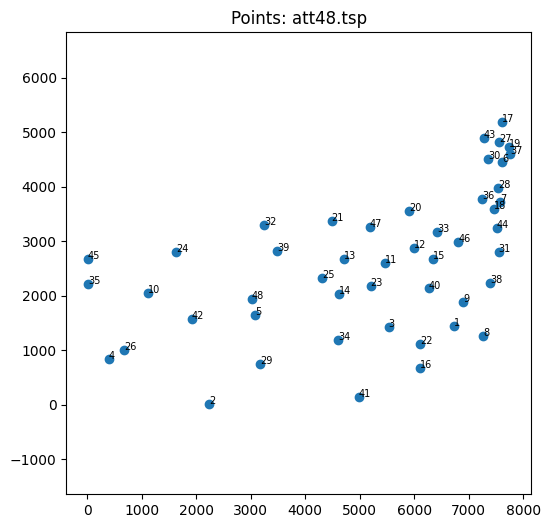

NN att48.tsp: cost=12861.00


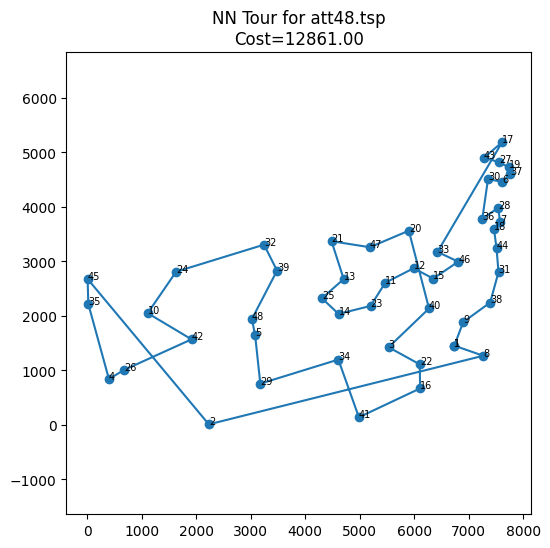

In [ ]:
plot_instance("att48.tsp")
visualize_nn("att48.tsp")


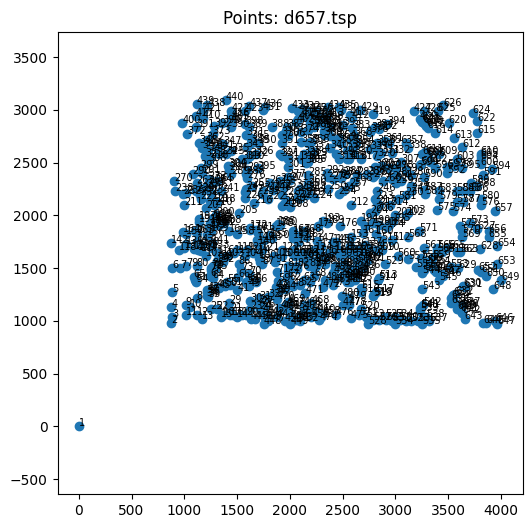

NameError: name 'get_distance_matrix' is not defined

In [ ]:
plot_instance("d657.tsp")
visualize_nn("d657.tsp")

In [ ]:
visualize_nn("gr17.tsp")

NameError: name 'get_distance_matrix' is not defined

In [ ]:
#@title Brute Force

# Implement a brute force method to solve TSP problems
import itertools
import numpy as np

def brute_force_tsp_matrix(dist):
    """
    Pure brute-force algorithm for TSP.
    Input: dist = n×n NumPy array distance matrix.
    Returns: (best_tour, best_cost)
    best_tour is a list of node indices (0..n), last = first.
    """

    n = dist.shape[0]
    nodes = list(range(n))
    start = 0  # fix starting city (symmetry reduction)

    best_cost = float("inf")
    best_tour = None

    # Permute all cities except the start
    for perm in itertools.permutations(nodes[1:]):
        tour = (start,) + perm + (start,)
        cost = 0.0

        # compute tour cost
        for i in range(len(tour)-1):
            cost += dist[tour[i], tour[i+1]]

        # update best
        if cost < best_cost:
            best_cost = cost
            best_tour = tour

    return list(best_tour), best_cost

#Running it

name = "five_d.txt"

# Ensure five_d.txt is properly loaded if it wasn't due to previous errors
if name not in tsp_instances or not tsp_instances[name]["dist"]:
    five_d_path = os.path.join(TSP_FOLDER, name)
    try:
        tsp_instances[name] = load_plain_matrix(five_d_path)
        print(f"Re-loaded {name} successfully.")
    except Exception as e:
        print(f"Error re-loading {name}: {e}")

inst = tsp_instances[name]

dist = np.array(inst["dist"])
tour, cost = brute_force_tsp_matrix(dist)

print("Optimal brute-force tour:", tour)
print("Optimal cost:", cost)
print("Optimal tour (labels):",[inst["nodes"][i] for i in tour])

Re-loaded five_d.txt successfully.
Optimal brute-force tour: [0, 2, 1, 4, 3, 0]
Optimal cost: 19.0
Optimal tour (labels): [1, 3, 2, 5, 4, 1]


Held-Karp Dynamic Programming

In [ ]:
import numpy as np
from math import inf

def held_karp_tsp_matrix(dist):
    """
    Held–Karp exact TSP solver.
    dist: NxN numpy array
    Returns: (optimal_tour, optimal_cost)
    """
    n = dist.shape[0]
    N = 1 << n

    # dp[mask][j] = minimum cost to start at 0,
    # visit exactly the cities in mask, and end at j
    dp = [[inf] * n for _ in range(N)]
    parent = [[-1] * n for _ in range(N)]

    # Base case: start at city 0
    dp[1][0] = 0  # mask = 000...001

    # Iterate over all subsets that include city 0
    for mask in range(N):
        if not (mask & 1):  # must include city 0
            continue

        for j in range(n):
            if not (mask & (1 << j)):
                continue

            prev_mask = mask ^ (1 << j)
            if prev_mask == 0 and j == 0:
                continue

            for i in range(n):
                if not (prev_mask & (1 << i)):
                    continue

                new_cost = dp[prev_mask][i] + dist[i][j]
                if new_cost < dp[mask][j]:
                    dp[mask][j] = new_cost
                    parent[mask][j] = i

    # Close the tour
    full_mask = (1 << n) - 1
    best_cost = inf
    last_city = -1

    for j in range(1, n):
        cost = dp[full_mask][j] + dist[j][0]
        if cost < best_cost:
            best_cost = cost
            last_city = j

    # Reconstruct tour
    tour = [0] * (n + 1)
    tour[n] = 0
    mask = full_mask
    curr = last_city

    for k in range(n - 1, 0, -1):
        tour[k] = curr
        prev = parent[mask][curr]
        mask ^= (1 << curr)
        curr = prev

    tour[0] = 0

    return tour, best_cost

#Running for gr17.tsp
name = "gr17.tsp"
inst = tsp_instances[name]

dist = np.array(inst["dist"])

tour, cost = held_karp_tsp_matrix(dist)

print("Optimal cost:", cost)
print("Optimal tour:", tour)

#Runtime: 9 seconds

Optimal cost: 2085
Optimal tour: [0, 15, 11, 8, 4, 1, 9, 10, 2, 14, 13, 16, 5, 7, 6, 12, 3, 0]


In [ ]:
#Running for fri26.tsp
name = "gr17.tsp"
inst = tsp_instances[name]

dist = np.array(inst["dist"])

tour, cost = held_karp_tsp_matrix(dist)

print("Optimal cost:", cost)
print("Optimal tour:", tour)

#failed due to timeout, usage of all total RAM. Expected since HK DP caps at around 20 to 22 cities.

Optimal cost: 2085
Optimal tour: [0, 15, 11, 8, 4, 1, 9, 10, 2, 14, 13, 16, 5, 7, 6, 12, 3, 0]


In [ ]:
#@title Heuristics implementation

# Find libraries that implement the heuristics
# Use these libraries to solve a specific TSP problem


# TODO

## Tour Construction (Euclidean 2D)


Christofide's Algorithm



In [ ]:
import networkx as nx
import numpy as np

def christofides_tsp_from_matrix(dist):
    """
    dist: NxN numpy array (symmetric, metric)
    returns: tour (list of nodes), cost
    """
    n = dist.shape[0]

    # Build complete graph
    G = nx.Graph()
    for i in range(n):
        for j in range(i + 1, n):
            G.add_edge(i, j, weight=dist[i, j])

    # Christofides tour
    tour = nx.algorithms.approximation.traveling_salesman.christofides(G)

    # Close the cycle if needed
    if tour[0] != tour[-1]:
        tour.append(tour[0])

    # Compute cost
    cost = sum(dist[tour[i], tour[i + 1]] for i in range(len(tour) - 1))

    return tour, cost

In [ ]:
name = "pr1002.tsp"
inst = tsp_instances[name]
dist = np.array(inst["dist"])
tour, cost = christofides_tsp_from_matrix(dist)

print("Christofides tour:", tour)
print("Cost:", cost)

#Runtime: Less than 1 second
#Euclidean 2D -> Christofide's bound of 3/2 optimality applies

Christofides tour: [0, 75, 74, 73, 79, 80, 81, 87, 85, 86, 84, 83, 82, 77, 78, 88, 89, 91, 93, 92, 76, 90, 97, 98, 96, 95, 94, 133, 135, 134, 132, 99, 100, 101, 128, 129, 130, 144, 145, 146, 147, 143, 148, 149, 994, 251, 250, 249, 248, 252, 253, 254, 255, 256, 258, 257, 120, 119, 121, 122, 123, 124, 125, 126, 127, 131, 136, 137, 138, 139, 140, 141, 142, 150, 151, 152, 153, 154, 168, 167, 166, 165, 164, 155, 163, 162, 161, 157, 158, 184, 183, 182, 181, 995, 180, 179, 178, 173, 174, 175, 176, 177, 172, 169, 170, 171, 160, 159, 156, 185, 240, 241, 239, 237, 238, 188, 191, 192, 193, 196, 197, 200, 198, 199, 205, 206, 207, 208, 209, 204, 203, 202, 201, 195, 194, 186, 187, 189, 190, 236, 235, 234, 233, 232, 220, 219, 218, 217, 216, 211, 210, 215, 212, 214, 213, 221, 222, 223, 224, 225, 226, 227, 228, 264, 266, 265, 267, 268, 270, 271, 272, 468, 466, 467, 469, 470, 471, 476, 477, 997, 579, 578, 577, 575, 574, 572, 573, 589, 593, 595, 596, 598, 599, 600, 796, 794, 795, 797, 798, 799, 804, 805,

In [ ]:
name = "d198.tsp"
inst = tsp_instances[name]
dist = np.array(inst["dist"])
tour, cost = christofides_tsp_from_matrix(dist)

print("Christofides tour:", tour)
print("Cost:", cost)

#Runtime: <1 s
#Euclidean 2D applies

Christofides tour: [0, 16, 15, 14, 13, 39, 40, 41, 56, 57, 68, 70, 84, 85, 99, 98, 86, 83, 72, 69, 65, 73, 82, 87, 97, 96, 81, 74, 64, 51, 46, 45, 52, 61, 53, 44, 60, 88, 89, 95, 94, 93, 100, 92, 101, 102, 103, 104, 113, 112, 111, 105, 106, 110, 109, 108, 119, 137, 133, 134, 140, 142, 145, 161, 151, 148, 144, 149, 150, 162, 163, 164, 165, 171, 136, 143, 135, 132, 129, 130, 131, 139, 141, 146, 147, 152, 160, 159, 158, 157, 156, 155, 154, 153, 138, 122, 117, 116, 115, 120, 121, 114, 118, 123, 124, 168, 125, 128, 126, 169, 127, 170, 189, 188, 187, 190, 182, 180, 176, 177, 178, 184, 186, 191, 192, 185, 194, 197, 196, 195, 193, 183, 179, 173, 172, 175, 174, 181, 167, 166, 107, 91, 78, 79, 90, 77, 80, 75, 76, 63, 49, 62, 48, 47, 50, 38, 34, 33, 32, 29, 28, 23, 21, 22, 17, 18, 19, 20, 24, 25, 26, 27, 31, 35, 36, 30, 37, 43, 54, 59, 66, 71, 67, 58, 55, 42, 12, 11, 10, 9, 8, 7, 4, 3, 2, 5, 1, 6, 0]
Cost: 17306


Running Christofide for All

In [ ]:
import time

MAX_CHRISTOFIDES_N = 3000

christofides_results = {}

for name, inst in tsp_instances.items():
    n = inst.get("dimension", None)

    # -------- Size restraint --------
    if n is not None and n > MAX_CHRISTOFIDES_N:
        christofides_results[name] = {
            "tour": None,
            "cost": None,
            "runtime": None,
            "status": f"skipped (n={n} > {MAX_CHRISTOFIDES_N})",
            "edge_weight_type": inst.get("edge_weight_type", "unknown"),
            "dimension": n
        }
        print(f"⏭️ CH {name}: skipped (n={n})")
        continue

    try:
        dist = get_distance_matrix(inst)

        start = time.perf_counter()
        tour, cost = christofides_tsp_from_matrix(dist)
        runtime = time.perf_counter() - start

        christofides_results[name] = {
            "tour": tour,
            "cost": cost,
            "runtime": runtime,
            "status": "ok",
            "edge_weight_type": inst.get("edge_weight_type", "unknown"),
            "dimension": n
        }

        print(f"✓ CH {name}: cost={cost:.2f}, time={runtime:.4f}s")

    except Exception as e:
        christofides_results[name] = {
            "tour": None,
            "cost": None,
            "runtime": None,
            "status": f"failed ({e})",
            "edge_weight_type": inst.get("edge_weight_type", "unknown"),
            "dimension": n
        }
        print(f"⚠️ CH {name}: failed ({e})")

In [ ]:
for name, res in christofides_results.items():
    print(
        f"{name}: "
        f"cost={res['cost']:.2f}, "
        f"type={res['edge_weight_type']}, "
        f"n={res['dimension']}"
    )

a280.tsp: cost=2923.00, type=EUC_2D, n=280
att532.tsp: cost=31219.00, type=ATT, n=532
att48.tsp: cost=12613.00, type=ATT, n=48
berlin52.tsp: cost=8560.00, type=EUC_2D, n=52
bier127.tsp: cost=133311.00, type=EUC_2D, n=127
ch130.tsp: cost=6841.00, type=EUC_2D, n=130
ch150.tsp: cost=7182.00, type=EUC_2D, n=150
d198.tsp: cost=17306.00, type=EUC_2D, n=198
d493.tsp: cost=38579.00, type=EUC_2D, n=493
d657.tsp: cost=55130.00, type=EUC_2D, n=657
eil101.tsp: cost=707.00, type=EUC_2D, n=101
eil51.tsp: cost=462.00, type=EUC_2D, n=51
eil76.tsp: cost=608.00, type=EUC_2D, n=76
fl417.tsp: cost=13073.00, type=EUC_2D, n=417
gil262.tsp: cost=2698.00, type=EUC_2D, n=262
kroA100.tsp: cost=23293.00, type=EUC_2D, n=100
kroA150.tsp: cost=29358.00, type=EUC_2D, n=150
kroA200.tsp: cost=33071.00, type=EUC_2D, n=200
kroB100.tsp: cost=24012.00, type=EUC_2D, n=100
kroB150.tsp: cost=29833.00, type=EUC_2D, n=150
kroB200.tsp: cost=32804.00, type=EUC_2D, n=200
kroC100.tsp: cost=22752.00, type=EUC_2D, n=100
kroD100.tsp:

Nearest Neighbour #we already implemented earlier in visualizations

In [ ]:
import time

nn_results = {}

for name, inst in tsp_instances.items():
    dist = get_distance_matrix(inst)

    start = time.perf_counter()
    tour, cost = nearest_neighbor(dist)
    runtime = time.perf_counter() - start

    nn_results[name] = {
        "tour": tour,
        "cost": cost,
        "runtime": runtime,
        "edge_weight_type": inst.get("edge_weight_type", "unknown"),
        "dimension": inst.get("dimension", len(dist))
    }

    print(f"NN {name}: cost={cost:.2f}, time={runtime:.4f}s")

In [ ]:
for name, res in nn_results.items():
    print(f"{name}: NN cost = {res['cost']:.2f}")

a280.tsp: NN cost = 3157.00
att532.tsp: NN cost = 35516.00
att48.tsp: NN cost = 12861.00
berlin52.tsp: NN cost = 8980.00
bier127.tsp: NN cost = 135737.00
ch130.tsp: NN cost = 7579.00
ch150.tsp: NN cost = 8191.00
d198.tsp: NN cost = 18240.00
d493.tsp: NN cost = 41665.00
d657.tsp: NN cost = 61627.00
eil101.tsp: NN cost = 803.00
eil51.tsp: NN cost = 511.00
eil76.tsp: NN cost = 642.00
fl417.tsp: NN cost = 15013.00
gil262.tsp: NN cost = 3208.00
kroA100.tsp: NN cost = 27807.00
kroA150.tsp: NN cost = 33633.00
kroA200.tsp: NN cost = 35859.00
kroB100.tsp: NN cost = 29158.00
kroB150.tsp: NN cost = 34499.00
kroB200.tsp: NN cost = 36980.00
kroC100.tsp: NN cost = 26227.00
kroD100.tsp: NN cost = 26947.00
kroE100.tsp: NN cost = 27460.00
lin105.tsp: NN cost = 20356.00
lin318.tsp: NN cost = 54019.00
linhp318.tsp: NN cost = 54019.00
p654.tsp: NN cost = 43457.00
pcb442.tsp: NN cost = 61979.00
pr1002.tsp: NN cost = 331103.00
pr107.tsp: NN cost = 46680.00
pr124.tsp: NN cost = 69297.00
pr136.tsp: NN cost = 

Greedy Algorithm

In [ ]:
def greedy_tsp_from_matrix(dist):
    """
    Greedy (cheapest-link) TSP heuristic.
    dist: NxN symmetric distance matrix
    returns: tour, cost
    """
    n = len(dist)

    # ---------- Union-Find ----------
    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(x, y):
        rx, ry = find(x), find(y)
        if rx != ry:
            parent[ry] = rx

    # ---------- Build and sort all edges ----------
    edges = []
    for i in range(n):
        for j in range(i + 1, n):
            edges.append((dist[i][j], i, j))

    edges.sort()

    degree = [0] * n
    chosen_edges = []

    # ---------- Greedy edge selection ----------
    for w, u, v in edges:
        if degree[u] == 2 or degree[v] == 2:
            continue

        # Check for subtour
        if find(u) == find(v):
            # Allow only if this is the final edge
            if len(chosen_edges) == n - 1:
                chosen_edges.append((u, v))
                degree[u] += 1
                degree[v] += 1
            continue

        # Accept edge
        chosen_edges.append((u, v))
        union(u, v)
        degree[u] += 1
        degree[v] += 1

        if len(chosen_edges) == n:
            break

    # ---------- Reconstruct tour ----------
    adj = {i: [] for i in range(n)}
    for u, v in chosen_edges:
        adj[u].append(v)
        adj[v].append(u)

    tour = [0]
    prev = -1
    curr = 0

    while True:
        nxt = adj[curr][0] if adj[curr][0] != prev else adj[curr][1]
        if nxt == 0:
            break
        tour.append(nxt)
        prev, curr = curr, nxt

    tour.append(0)

    cost = sum(dist[tour[i]][tour[i + 1]] for i in range(len(tour) - 1))

    return tour, cost

In [ ]:
import time

greedy_results = {}

for name, inst in tsp_instances.items():
    try:
        dist = get_distance_matrix(inst)

        start = time.perf_counter()
        tour, cost = greedy_tsp_from_matrix(dist)
        runtime = time.perf_counter() - start

        greedy_results[name] = {
            "tour": tour,
            "cost": cost,
            "runtime": runtime,
            "edge_weight_type": inst.get("edge_weight_type", "unknown"),
            "dimension": inst.get("dimension", len(dist))
        }

        print(f"Greedy {name}: cost={cost:.2f}, time={runtime:.4f}s")

    except Exception as e:
        print(f"⚠️ Greedy failed on {name}: {e}")

Greedy christofides_hard_n400_s0.tsp: cost=12820.00, time=0.2316s
Greedy christofides_hard_n100_s0.tsp: cost=4856.00, time=0.0103s
Greedy christofides_hard_n200_s0.tsp: cost=8433.00, time=0.0499s
Greedy christofides_hard_n300_s0.tsp: cost=9322.00, time=0.1360s
Greedy christofides_hard_n500_s0.tsp: cost=12075.00, time=0.3666s
Greedy christofides_hard_n150_s0.tsp: cost=8812.00, time=0.0258s
Greedy christofides_hard_n50_s0.tsp: cost=7556.00, time=0.0022s
Greedy christofides_hard_n75_s0.tsp: cost=8792.00, time=0.0052s
Greedy christofides_hard_n125_s0.tsp: cost=7988.00, time=0.0154s
Greedy christofides_hard_n175_s0.tsp: cost=5723.00, time=0.0344s
Greedy christofides_hard_n225_s0.tsp: cost=9227.00, time=0.0613s
Greedy christofides_hard_n250_s0.tsp: cost=11519.00, time=0.0887s
Greedy christofides_hard_n275_s0.tsp: cost=7046.00, time=0.0978s
Greedy family_A_random_n400_s0.tsp: cost=211353.00, time=0.2904s
Greedy family_A_random_n100_s0.tsp: cost=95600.00, time=0.0121s
Greedy family_A_random_n2

In [ ]:
for name, res in greedy_results.items():
    print(
        f"{name}: "
        f"cost={res['cost']:.2f}, "
        f"type={res['edge_weight_type']}, "
        f"n={res['dimension']}"
    )

bayg29.tsp: cost=1974.00, type=EXPLICIT, n=29
bays29.tsp: cost=2480.00, type=EXPLICIT, n=29
brazil58.tsp: cost=30458.00, type=EXPLICIT, n=58
brg180.tsp: cost=37830.00, type=EXPLICIT, n=180
dantzig42.tsp: cost=1003.00, type=EXPLICIT, n=42
fri26.tsp: cost=988.00, type=EXPLICIT, n=26
gr120.tsp: cost=8241.00, type=EXPLICIT, n=120
gr17.tsp: cost=2189.00, type=EXPLICIT, n=17
gr21.tsp: cost=3028.00, type=EXPLICIT, n=21
gr24.tsp: cost=1602.00, type=EXPLICIT, n=24
gr48.tsp: cost=6406.00, type=EXPLICIT, n=48
hk48.tsp: cost=13402.00, type=EXPLICIT, n=48
pa561.tsp: cost=3309.00, type=EXPLICIT, n=561
si175.tsp: cost=21957.00, type=EXPLICIT, n=175
si535.tsp: cost=49413.00, type=EXPLICIT, n=535


Insertion

In [ ]:
def insertion_tsp_from_matrix(dist):
    """
    Cheapest Insertion heuristic for TSP.
    dist: NxN symmetric distance matrix
    returns: tour, cost
    """
    n = len(dist)

    # ---------- Step 1: initial subtour ----------
    # Start with two nodes: 0 and its nearest neighbor
    start = 0
    nearest = np.argmin([dist[start][j] if j != start else np.inf for j in range(n)])

    tour = [start, nearest, start]
    unvisited = set(range(n))
    unvisited.remove(start)
    unvisited.remove(nearest)

    # ---------- Step 2: iterative insertion ----------
    while unvisited:
        best_increase = np.inf
        best_city = None
        best_position = None

        # Try inserting every unvisited city into every edge
        for city in unvisited:
            for i in range(len(tour) - 1):
                a = tour[i]
                b = tour[i + 1]

                increase = dist[a][city] + dist[city][b] - dist[a][b]

                if increase < best_increase:
                    best_increase = increase
                    best_city = city
                    best_position = i + 1

        # Insert the best city at the best position
        tour.insert(best_position, best_city)
        unvisited.remove(best_city)

    # ---------- Step 3: compute cost ----------
    cost = sum(dist[tour[i]][tour[i + 1]] for i in range(len(tour) - 1))

    return tour, cost

In [ ]:
import time

MAX_INSERTION_N = 2000

insertion_results = {}

for name, inst in tsp_instances.items():
    n = inst.get("dimension", None)

    # -------- Size restraint --------
    if n is not None and n > MAX_INSERTION_N:
        insertion_results[name] = {
            "tour": None,
            "cost": None,
            "runtime": None,
            "status": f"skipped (n={n} > {MAX_INSERTION_N})",
            "edge_weight_type": inst.get("edge_weight_type", "unknown"),
            "dimension": n
        }
        print(f"⏭️ Insertion {name}: skipped (n={n})")
        continue

    try:
        dist = get_distance_matrix(inst)

        start = time.perf_counter()
        tour, cost = insertion_tsp_from_matrix(dist)
        runtime = time.perf_counter() - start

        insertion_results[name] = {
            "tour": tour,
            "cost": cost,
            "runtime": runtime,
            "status": "ok",
            "edge_weight_type": inst.get("edge_weight_type", "unknown"),
            "dimension": n
        }

        print(f"✓ Insertion {name}: cost={cost:.2f}, time={runtime:.4f}s")

    except Exception as e:
        insertion_results[name] = {
            "tour": None,
            "cost": None,
            "runtime": None,
            "status": f"failed ({e})",
            "edge_weight_type": inst.get("edge_weight_type", "unknown"),
            "dimension": n
        }
        print(f"⚠️ Insertion {name}: failed ({e})")

✓ Insertion christofides_hard_n400_s0.tsp: cost=886.00, time=11.9186s
✓ Insertion christofides_hard_n100_s0.tsp: cost=412.00, time=0.2822s
✓ Insertion christofides_hard_n200_s0.tsp: cost=651.00, time=1.7240s
✓ Insertion christofides_hard_n300_s0.tsp: cost=747.00, time=4.4971s
✓ Insertion christofides_hard_n500_s0.tsp: cost=958.00, time=24.2784s
✓ Insertion christofides_hard_n150_s0.tsp: cost=493.00, time=0.5500s
✓ Insertion christofides_hard_n50_s0.tsp: cost=2759.00, time=0.0201s
✓ Insertion christofides_hard_n75_s0.tsp: cost=353.00, time=0.0710s
✓ Insertion christofides_hard_n125_s0.tsp: cost=429.00, time=0.3169s
✓ Insertion christofides_hard_n175_s0.tsp: cost=536.00, time=0.8685s
✓ Insertion christofides_hard_n225_s0.tsp: cost=3127.00, time=1.8360s
✓ Insertion christofides_hard_n250_s0.tsp: cost=625.00, time=2.4916s
✓ Insertion christofides_hard_n275_s0.tsp: cost=701.00, time=4.2263s
✓ Insertion family_A_random_n400_s0.tsp: cost=378732.00, time=12.4434s
✓ Insertion family_A_random_n1

Nearest Neighbour, Christofide, Greedy, Insertion Comparison

In [ ]:
def fmt(x):
    return f"{x:.2f}" if x is not None else " "
for name in tsp_instances:
    print(
        f"{name}: "
        f"NN={fmt(nn_results[name]['cost'])}, "
        f"Greedy={fmt(greedy_results[name]['cost'])}, "
        f"CH={fmt(christofides_results[name]['cost'])}"
    )


In [ ]:
tsp_summary = {}

for name in tsp_instances:
    if (
        name in nn_results
        and name in greedy_results
        and name in insertion_results
        and name in christofides_results
    ):
        nn_cost = nn_results[name]["cost"]
        greedy_cost = greedy_results[name]["cost"]
        insertion_cost = insertion_results[name]["cost"]
        ch_cost = christofides_results[name]["cost"]

        tsp_summary[name] = {
            # -------- Metadata --------
            "dimension": tsp_instances[name].get("dimension"),
            "edge_weight_type": tsp_instances[name].get("edge_weight_type"),

            # -------- Costs --------
            "nn_cost": nn_cost,
            "greedy_cost": greedy_cost,
            "insertion_cost": insertion_cost,
            "christofides_cost": ch_cost,

            # -------- Runtimes --------
            "nn_time": nn_results[name]["runtime"],
            "greedy_time": greedy_results[name]["runtime"],
            "insertion_time": insertion_results[name]["runtime"],
            "christofides_time": christofides_results[name]["runtime"],

            # -------- Ratios (null-safe) --------
            "nn_ratio": (
                nn_cost / ch_cost
                if nn_cost is not None and ch_cost is not None
                else None
            ),
            "greedy_ratio": (
                greedy_cost / ch_cost
                if greedy_cost is not None and ch_cost is not None
                else None
            ),
            "insertion_ratio": (
                insertion_cost / ch_cost
                if insertion_cost is not None and ch_cost is not None
                else None
            ),
        }

tsp_summary

{}

In [ ]:
import csv

with open("tsp_results.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "instance", "dimension", "edge_type",

        "nn_cost", "greedy_cost", "insertion_cost", "christofides_cost",
        "nn_ratio", "greedy_ratio", "insertion_ratio",

        "nn_time", "greedy_time", "insertion_time", "christofides_time"
    ])

    for name, r in tsp_summary.items():
        writer.writerow([
            name,
            r["dimension"],
            r["edge_weight_type"],

            r["nn_cost"],
            r["greedy_cost"],
            r["insertion_cost"],
            r["christofides_cost"],

            r["nn_ratio"],
            r["greedy_ratio"],
            r["insertion_ratio"],

            r["nn_time"],
            r["greedy_time"],
            r["insertion_time"],
            r["christofides_time"]
        ])

In [ ]:
def latex_num(x, fmt="{:.2f}"):
    return fmt.format(x) if x is not None else "--"

def latex_time(x):
    return f"{x:.3f}s" if x is not None else "--"


def latex_table(summary, baseline="CH"):
    """
    baseline: "CH" (Christofides) or "Greedy"
    """

    if baseline == "CH":
        ratio1_label = "NN/CH"
        ratio2_label = "Ins/CH"
    elif baseline == "Greedy":
        ratio1_label = "NN/Greedy"
        ratio2_label = "Ins/Greedy"
    else:
        raise ValueError("baseline must be 'CH' or 'Greedy'")

    lines = []
    lines.append("\\begin{tabular}{lrrrrrrrr}")
    lines.append("\\hline")
    lines.append(
        "Instance & "
        "NN & Greedy & Insertion & CH & "
        f"{ratio1_label} & {ratio2_label} & Greedy/CH & CH/Greedy \\\\"
    )
    lines.append("\\hline")

    for name, r in summary.items():
        nn = r["nn_cost"]
        gr = r["greedy_cost"]
        ins = r["insertion_cost"]
        ch = r["christofides_cost"]

        # Baseline-dependent ratios
        if baseline == "CH":
            r1 = nn / ch if nn is not None and ch is not None else None
            r2 = ins / ch if ins is not None and ch is not None else None
        else:  # Greedy baseline
            r1 = nn / gr if nn is not None and gr is not None else None
            r2 = ins / gr if ins is not None and gr is not None else None

        # Always-available symmetric ratios
        greedy_ch = gr / ch if gr is not None and ch is not None else None
        ch_greedy = ch / gr if ch is not None and gr is not None else None

        lines.append(
            f"{name} & "
            f"{latex_num(nn)} ({latex_time(r['nn_time'])}) & "
            f"{latex_num(gr)} ({latex_time(r['greedy_time'])}) & "
            f"{latex_num(ins)} ({latex_time(r['insertion_time'])}) & "
            f"{latex_num(ch)} ({latex_time(r['christofides_time'])}) & "
            f"{latex_num(r1)} & "
            f"{latex_num(r2)} & "
            f"{latex_num(greedy_ch)} & "
            f"{latex_num(ch_greedy)} \\\\"
        )

    lines.append("\\hline")
    lines.append("\\end{tabular}")
    return "\n".join(lines)

print(latex_table(tsp_summary, baseline="CH"))
#print(latex_table(tsp_summary, baseline="Greedy"))

\begin{tabular}{lrrrrrrrr}
\hline
Instance & NN & Greedy & Insertion & CH & NN/CH & Ins/CH & Greedy/CH & CH/Greedy \\
\hline
ali535.tsp & 253127.00 (0.198s) & 237817.00 (0.367s) & 242524.00 (30.971s) & 225134.00 (12.101s) & 1.12 & 1.08 & 1.06 & 0.95 \\
burma14.tsp & 4048.00 (0.000s) & 3889.00 (0.000s) & 3588.00 (0.001s) & 3606.00 (0.003s) & 1.12 & 1.00 & 1.08 & 0.93 \\
gr137.tsp & 93912.00 (0.014s) & 79460.00 (0.012s) & 79730.00 (0.835s) & 76589.00 (0.280s) & 1.23 & 1.04 & 1.04 & 0.96 \\
gr202.tsp & 49336.00 (0.030s) & 45926.00 (0.029s) & 46480.00 (2.483s) & 43377.00 (1.068s) & 1.14 & 1.07 & 1.06 & 0.94 \\
gr229.tsp & 162430.00 (0.052s) & 163730.00 (0.045s) & 153896.00 (2.096s) & 147311.00 (0.965s) & 1.10 & 1.04 & 1.11 & 0.90 \\
gr431.tsp & 210069.00 (0.119s) & 204581.00 (0.201s) & 198626.00 (15.182s) & 186132.00 (7.951s) & 1.13 & 1.07 & 1.10 & 0.91 \\
gr666.tsp & 366962.00 (0.287s) & 339319.00 (0.542s) & 343511.00 (61.039s) & 326784.00 (23.692s) & 1.12 & 1.05 & 1.04 & 0.96 \\
gr96.tsp

## Tour Improvement

2-opt

In [ ]:
def normalize_tour(tour):
    # remove duplicated endpoint
    if tour[0] == tour[-1]:
        return tour[:-1]
    return tour

def tour_cost(tour, dist):
    n = len(tour)
    return sum(dist[tour[i], tour[(i + 1) % n]] for i in range(n))

def two_opt_swap(tour, i, k):
    return tour[:i] + tour[i:k+1][::-1] + tour[k+1:]

def two_opt(tour, dist, max_iter=1000):
    tour = tour.copy()
    n = len(tour)
    best_cost = tour_cost(tour, dist)

    improved = True
    it = 0

    while improved and it < max_iter:
        improved = False
        it += 1

        for i in range(1, n - 2):
            for k in range(i + 1, n - 1):
                # edges: (i-1,i) and (k,k+1)
                a, b = tour[i - 1], tour[i]
                c, d = tour[k], tour[(k + 1) % n]

                # cost difference
                delta = (
                    dist[a, c] + dist[b, d]
                    - dist[a, b] - dist[c, d]
                )

                if delta < -1e-9:
                    tour = two_opt_swap(tour, i, k)
                    best_cost += delta
                    improved = True
                    break
            if improved:
                break

    return tour, best_cost

def close_tour(tour):
    if tour[0] != tour[-1]:
        return tour + [tour[0]]
    return tour

In [ ]:
# Start from Christofides result
tour0 = normalize_tour(tour)

print("Christofides cost:", tour_cost(tour0, dist))

# Run 2-opt
tour_2opt, cost_2opt = two_opt(tour0, dist)

# Close the cycle
final_2opt_tour = close_tour(tour_2opt)

print("\nFinal 2-opt tour:")
print(final_2opt_tour)

print("\nFinal tour length:", cost_2opt)

Christofides cost: 47646


KeyboardInterrupt: 

3-Opt

In [ ]:
def three_opt_swap(tour, i, j, k, case):
    A = tour[:i]
    B = tour[i:j]
    C = tour[j:k]
    D = tour[k:]

    if case == 1:
        return A + B[::-1] + C + D
    elif case == 2:
        return A + B + C[::-1] + D
    elif case == 3:
        return A + B[::-1] + C[::-1] + D
    elif case == 4:
        return A + C + B + D
    elif case == 5:
        return A + C[::-1] + B + D

def three_opt(tour, dist, max_iter=10):
    tour = tour.copy()
    n = len(tour)
    best_cost = tour_cost(tour, dist)

    improved = True
    it = 0

    while improved and it < max_iter:
        improved = False
        it += 1

        for i in range(1, n - 4):
            for j in range(i + 1, n - 2):
                for k in range(j + 1, n):

                    a, b = tour[i - 1], tour[i]
                    c, d = tour[j - 1], tour[j]
                    e, f = tour[k - 1], tour[k % n]

                    old = (
                        dist[a, b] +
                        dist[c, d] +
                        dist[e, f]
                    )

                    for case in range(1, 6):
                        new_tour = three_opt_swap(tour, i, j, k, case)
                        new_cost = tour_cost(new_tour, dist)

                        if new_cost < best_cost - 1e-9:
                            tour = new_tour
                            best_cost = new_cost
                            improved = True
                            break

                    if improved:
                        break
                if improved:
                    break
            if improved:
                break

    return tour, best_cost

In [ ]:
# Start from Christofides result
tour0 = normalize_tour(tour)

print("Christofides cost:", tour_cost(tour0, dist))

# Run 2-opt
tour_3opt, cost_3opt = three_opt(tour0, dist)

# Close the cycle
final_tour = close_tour(tour_3opt)

print("\nFinal 3-opt tour:")
print(final_tour)

print("\nFinal tour length:", cost_3opt)

Christofides cost: 55130

Final 3-opt tour:
[0, 3, 4, 5, 6, 78, 79, 64, 60, 53, 45, 44, 40, 50, 54, 49, 63, 68, 73, 77, 74, 84, 101, 116, 128, 129, 138, 131, 117, 141, 163, 156, 164, 162, 190, 196, 195, 197, 198, 199, 209, 218, 234, 240, 264, 263, 261, 253, 271, 290, 289, 269, 237, 231, 210, 235, 238, 230, 239, 217, 206, 220, 262, 298, 307, 317, 322, 335, 340, 346, 324, 334, 308, 309, 321, 342, 348, 349, 364, 370, 388, 397, 422, 436, 430, 435, 439, 421, 415, 404, 400, 389, 398, 391, 409, 420, 437, 438, 399, 371, 390, 416, 372, 361, 345, 347, 341, 323, 303, 299, 293, 288, 292, 325, 294, 287, 275, 254, 241, 247, 251, 268, 276, 270, 300, 310, 320, 326, 350, 369, 387, 377, 365, 386, 401, 405, 414, 423, 432, 431, 424, 419, 410, 425, 413, 406, 402, 395, 385, 394, 403, 407, 412, 433, 434, 429, 417, 411, 428, 382, 392, 367, 362, 353, 344, 338, 332, 329, 316, 315, 314, 313, 328, 339, 359, 363, 352, 366, 368, 374, 376, 379, 384, 396, 378, 373, 358, 351, 357, 333, 318, 312, 305, 304, 311, 327, 28

In [ ]:
# Start from Christofides + 2 opt result

print("2-opt cost:", tour_cost(final_2opt_tour, dist))

# Run 2-opt
tour_3opt, cost_3opt = three_opt(final_2opt_tour, dist)

# Close the cycle
final_3opt_tour = close_tour(tour_3opt)

print("\nFinal 3-opt tour:")
print(final_3opt_tour)

print("\nFinal tour length:", cost_3opt)

2-opt cost: 51766


KeyboardInterrupt: 

#Engineering Features

##Min Edge Weight

In [ ]:
import math

def compute_min_edge_weight(inst):
    dist = get_distance_matrix(inst)
    n = dist.shape[0]

    min_w = math.inf
    for i in range(n):
        for j in range(i + 1, n):
            w = dist[i, j]
            if w > 0 and w < min_w:
                min_w = w

    return min_w

In [ ]:
import pandas as pd

rows = []

for fname, inst in tsp_instances.items():
    min_w = compute_min_edge_weight(inst)
    rows.append({
        "instance_id": fname,
        "min_edge_weight": min_w
    })
df_min_edge = pd.DataFrame(rows)
df_min_edge

""


Writing into CSV

In [ ]:
import pandas as pd

CSV_PATH = "/content/drive/MyDrive/Dataframe/Dataset.csv"

# Load CSV
df = pd.read_csv(CSV_PATH)

# Build lookup from loaded instances
min_edge_dict = {
    fname: compute_min_edge_weight(inst)
    for fname, inst in tsp_instances.items()
}

# Map feature into dataframe using correct identifier column
df["min_edge_weight"] = df["file"].map(min_edge_dict)

# ---- Mandatory sanity check ----
missing = df.loc[df["min_edge_weight"].isna(), "file"]

if len(missing) > 0:
    raise ValueError(
        "Missing min_edge_weight for the following files:\n"
        + "\n".join(missing.astype(str))
    )

# Write back to CSV
df.to_csv(CSV_PATH, index=False)
print("✓ CSV updated with min_edge_weight")

KeyboardInterrupt: 

##Max Edge Weight

In [ ]:
import math

def compute_max_edge_weight(inst):
    dist = get_distance_matrix(inst)
    n = dist.shape[0]

    max_w = -math.inf
    for i in range(n):
        for j in range(i + 1, n):
            w = dist[i, j]
            if w > max_w:
                max_w = w

    return max_w

In [ ]:
rows = []

for fname, inst in tsp_instances.items():
    max_w = compute_max_edge_weight(inst)
    rows.append({
        "instance_id": fname,
        "max_edge_weight": max_w
    })

df_max_edge = pd.DataFrame(rows)
df_max_edge

""


Write into CSV

In [ ]:
CSV_PATH = "/content/drive/MyDrive/Dataframe/Dataset.csv"

# Load CSV
df = pd.read_csv(CSV_PATH)

# Build lookup
max_edge_dict = {
    fname: compute_max_edge_weight(inst)
    for fname, inst in tsp_instances.items()
}

# Map into dataframe
df["max_edge_weight"] = df["file"].map(max_edge_dict)

# ---- Mandatory sanity check ----
missing = df.loc[df["max_edge_weight"].isna(), "file"]

if len(missing) > 0:
    raise ValueError(
        "Missing max_edge_weight for the following files:\n"
        + "\n".join(missing.astype(str))
    )

# Write back
df.to_csv(CSV_PATH, index=False)
print("✓ CSV updated with max_edge_weight")


✓ CSV updated with max_edge_weight


In [ ]:
assert (df["max_edge_weight"] >= df["min_edge_weight"]).all()

##Mean Edge Weight

In [ ]:
import numpy as np

def compute_mean_edge_weight(inst):
    dist = get_distance_matrix(inst)
    n = dist.shape[0]

    total = 0.0
    count = 0

    for i in range(n):
        for j in range(i + 1, n):
            total += dist[i, j]
            count += 1

    return total / count

In [ ]:
rows = []

for fname, inst in tsp_instances.items():
    max_w = compute_mean_edge_weight(inst)
    rows.append({
        "instance_id": fname,
        "mean_edge_weight": max_w
    })

df_max_edge = pd.DataFrame(rows)
df_max_edge

""


In [ ]:
CSV_PATH = "/content/drive/MyDrive/Dataframe/Dataset.csv"

# Reload fresh CSV
df = pd.read_csv(CSV_PATH)

# Build lookup
mean_edge_dict = {
    fname: compute_mean_edge_weight(inst)
    for fname, inst in tsp_instances.items()
}

# Map into dataframe
df["mean_edge_weight"] = df["file"].map(mean_edge_dict)

# ---- Mandatory sanity check ----
missing = df.loc[df["mean_edge_weight"].isna(), "file"]
if len(missing) > 0:
    raise ValueError(
        "Missing mean_edge_weight for the following files:\n"
        + "\n".join(missing.astype(str))
    )

# Write back
df.to_csv(CSV_PATH, index=False)
print("✓ CSV updated with mean_edge_weight")

✓ CSV updated with mean_edge_weight


In [ ]:
assert (df["mean_edge_weight"] >= df["min_edge_weight"]).all()
assert (df["mean_edge_weight"] <= df["max_edge_weight"]).all()

##Std_Edge_Weight (Population)

In [ ]:
import math

def compute_std_edge_weight(inst):
    dist = get_distance_matrix(inst)
    n = dist.shape[0]

    # First pass: mean
    total = 0.0
    count = 0
    for i in range(n):
        for j in range(i + 1, n):
            total += dist[i, j]
            count += 1

    mean = total / count

    # Second pass: variance
    var = 0.0
    for i in range(n):
        for j in range(i + 1, n):
            diff = dist[i, j] - mean
            var += diff * diff

    var /= count
    return math.sqrt(var)

In [ ]:
rows = []

for fname, inst in tsp_instances.items():
    max_w = compute_std_edge_weight(inst)
    rows.append({
        "instance_id": fname,
        "std_edge_weight": max_w
    })

df_max_edge = pd.DataFrame(rows)
df_max_edge

""


In [ ]:
CSV_PATH = "/content/drive/MyDrive/Dataframe/Dataset.csv"

# Reload CSV
df = pd.read_csv(CSV_PATH)

# Build lookup
std_edge_dict = {
    fname: compute_std_edge_weight(inst)
    for fname, inst in tsp_instances.items()
}

# Map into dataframe
df["std_edge_weight"] = df["file"].map(std_edge_dict)

# ---- Mandatory sanity check ----
missing = df.loc[df["std_edge_weight"].isna(), "file"]
if len(missing) > 0:
    raise ValueError(
        "Missing std_edge_weight for the following files:\n"
        + "\n".join(missing.astype(str))
    )

# Write back
df.to_csv(CSV_PATH, index=False)
print("✓ CSV updated with std_edge_weight")

✓ CSV updated with std_edge_weight


In [ ]:
assert (df["std_edge_weight"] >= 0).all()
assert (df["std_edge_weight"] <= df["max_edge_weight"]).all()

##CV Edge Weight (Std / Mean)

In [ ]:
def compute_cv_edge_weight(inst):
    mean = compute_mean_edge_weight(inst)
    if mean == 0:
        return 0.0
    std = compute_std_edge_weight(inst)
    return std / mean

In [ ]:
rows = []

for fname, inst in tsp_instances.items():
    max_w = compute_cv_edge_weight(inst)
    rows.append({
        "instance_id": fname,
        "cv_edge_weight": max_w
    })

df_max_edge = pd.DataFrame(rows)
df_max_edge

,instance_id,cv_edge_weight
0,ali535.tsp,0.648144
1,burma14.tsp,0.530076
2,gr137.tsp,0.595412
3,gr202.tsp,0.623839
4,gr229.tsp,0.630928
...,...,...
95,u724.tsp,0.523477
96,vm1084.tsp,0.524716
97,vm1748.tsp,0.495445
98,pa561.tsp,0.480571


In [ ]:
CSV_PATH = "/content/drive/MyDrive/Dataframe/Dataset.csv"

# Reload CSV
df = pd.read_csv(CSV_PATH)

# Build lookup
cv_edge_dict = {
    fname: compute_cv_edge_weight(inst)
    for fname, inst in tsp_instances.items()
}

# Map into dataframe
df["cv_edge_weight"] = df["file"].map(cv_edge_dict)

# ---- Mandatory sanity check ----
missing = df.loc[df["cv_edge_weight"].isna(), "file"]
if len(missing) > 0:
    raise ValueError(
        "Missing cv_edge_weight for the following files:\n"
        + "\n".join(missing.astype(str))
    )

# Write back
df.to_csv(CSV_PATH, index=False)
print("✓ CSV updated with cv_edge_weight")

✓ CSV updated with cv_edge_weight


In [ ]:
assert (df["cv_edge_weight"] >= 0).all()

##Weight Skewness

In [ ]:
import math

def compute_edge_weight_skewness(inst):
    dist = get_distance_matrix(inst)
    n = dist.shape[0]

    # First pass: mean
    total = 0.0
    count = 0
    for i in range(n):
        for j in range(i + 1, n):
            total += dist[i, j]
            count += 1

    mean = total / count

    # Second pass: std
    var = 0.0
    for i in range(n):
        for j in range(i + 1, n):
            diff = dist[i, j] - mean
            var += diff * diff

    var /= count
    std = math.sqrt(var)

    if std == 0:
        return 0.0

    # Third pass: skewness
    skew = 0.0
    for i in range(n):
        for j in range(i + 1, n):
            z = (dist[i, j] - mean) / std
            skew += z ** 3

    skew /= count
    return skew

In [ ]:
rows = []

for fname, inst in tsp_instances.items():
    max_w = compute_edge_weight_skewness(inst)
    rows.append({
        "instance_id": fname,
        "edge_weight_skewness": max_w
    })

df_max_edge = pd.DataFrame(rows)
df_max_edge

,instance_id,edge_weight_skewness
0,ali535.tsp,0.454522
1,burma14.tsp,0.654604
2,gr137.tsp,0.658051
3,gr202.tsp,1.412151
4,gr229.tsp,0.938197
...,...,...
95,u724.tsp,0.442602
96,vm1084.tsp,0.383253
97,vm1748.tsp,0.217661
98,pa561.tsp,0.312582


Writing into CSV

In [ ]:
CSV_PATH = "/content/drive/MyDrive/Dataframe/Dataset.csv"

# Reload CSV
df = pd.read_csv(CSV_PATH)

# Build lookup
skew_edge_dict = {
    fname: compute_edge_weight_skewness(inst)
    for fname, inst in tsp_instances.items()
}

# Map into dataframe
df["edge_weight_skewness"] = df["file"].map(skew_edge_dict)

# ---- Mandatory sanity check ----
missing = df.loc[df["edge_weight_skewness"].isna(), "file"]
if len(missing) > 0:
    raise ValueError(
        "Missing edge_weight_skewness for the following files:\n"
        + "\n".join(missing.astype(str))
    )

# Write back
df.to_csv(CSV_PATH, index=False)
print("✓ CSV updated with edge_weight_skewness")

✓ CSV updated with edge_weight_skewness


In [ ]:
# Skewness should be finite
assert df["edge_weight_skewness"].notna().all()
assert (~df["edge_weight_skewness"].isin([math.inf, -math.inf])).all()

# Typical range check (not a hard rule)
df["edge_weight_skewness"].describe()

,edge_weight_skewness
count,480.000000
mean,0.349757
std,0.319623
min,-0.306612
25%,0.201948
50%,0.351397
75%,0.488506
max,1.492900


##PCT Short Edges (Fraction of edges <10th percentile of weights)

In [ ]:
import numpy as np

def compute_pct_short_edges(inst, percentile=10):
    dist = get_distance_matrix(inst)
    n = dist.shape[0]

    # Collect unique edge weights
    edges = []
    for i in range(n):
        for j in range(i + 1, n):
            edges.append(dist[i, j])

    edges = np.array(edges)

    # Compute threshold
    threshold = np.percentile(edges, percentile)

    # Fraction of short edges
    pct_short = np.mean(edges <= threshold)

    return pct_short

In [ ]:
rows = []

for fname, inst in tsp_instances.items():
    max_w = compute_pct_short_edges(inst)
    rows.append({
        "instance_id": fname,
        "pct_short_edges": max_w
    })

df_max_edge = pd.DataFrame(rows)
df_max_edge

,instance_id,pct_short_edges
0,ali535.tsp,0.100032
1,burma14.tsp,0.109890
2,gr137.tsp,0.100043
3,gr202.tsp,0.100094
4,gr229.tsp,0.100015
...,...,...
95,u724.tsp,0.100120
96,vm1084.tsp,0.100030
97,vm1748.tsp,0.100041
98,pa561.tsp,0.103711


In [ ]:
CSV_PATH = "/content/drive/MyDrive/Dataframe/Dataset.csv"

# Reload CSV
df = pd.read_csv(CSV_PATH)

# Build lookup
pct_short_dict = {
    fname: compute_pct_short_edges(inst)
    for fname, inst in tsp_instances.items()
}

# Map feature
df["pct_short_edges"] = df["file"].map(pct_short_dict)

# ---- Mandatory sanity check ----
missing = df.loc[df["pct_short_edges"].isna(), "file"]
if len(missing) > 0:
    raise ValueError(
        "Missing pct_short_edges for the following files:\n"
        + "\n".join(missing.astype(str))
    )

# Write back
df.to_csv(CSV_PATH, index=False)
print("✓ CSV updated with pct_short_edges")

✓ CSV updated with pct_short_edges


In [ ]:
assert (df["pct_short_edges"] >= 0).all()
assert (df["pct_short_edges"] <= 1).all()

##Triangle_Violation_Rate (Sample Size 200000)

In [ ]:
import random

def compute_triangle_violation_rate(inst, num_samples=200000, seed=42):
    dist = get_distance_matrix(inst)
    n = dist.shape[0]

    if n < 3:
        return 0.0

    random.seed(seed)

    violations = 0
    trials = 0

    for _ in range(num_samples):
        i, j, k = random.sample(range(n), 3)

        dij = dist[i, j]
        djk = dist[j, k]
        dik = dist[i, k]

        # Triangle inequality check
        if dik > dij + djk:
            violations += 1

        trials += 1

    return violations / trials

In [ ]:
rows = []

for fname, inst in tsp_instances.items():
    max_w = compute_triangle_violation_rate(inst)
    rows.append({
        "instance_id": fname,
        "triangle_violation_rate": max_w
    })

df_max_edge = pd.DataFrame(rows)
df_max_edge



,instance_id,triangle_violation_rate
0,pr1002.tsp,0.00018


In [ ]:
CSV_PATH = "/content/drive/MyDrive/Dataframe/Dataset.csv"

df = pd.read_csv(CSV_PATH)

triangle_violation_dict = {
    fname: compute_triangle_violation_rate(inst)
    for fname, inst in tsp_instances.items()
}

df["triangle_violation_rate"] = df["file"].map(triangle_violation_dict)

# ---- Mandatory sanity check ----
missing = df.loc[df["triangle_violation_rate"].isna(), "file"]
if len(missing) > 0:
    raise ValueError(
        "Missing triangle_violation_rate for the following files:\n"
        + "\n".join(missing.astype(str))
    )

df.to_csv(CSV_PATH, index=False)
print("✓ CSV updated with triangle_violation_rate")

✓ CSV updated with triangle_violation_rate


##Average Violation Magnitude

In [ ]:
import random

def compute_avg_violation_magnitude(inst, num_samples=200000, seed=42):
    dist = get_distance_matrix(inst)
    n = dist.shape[0]

    if n < 3:
        return 0.0

    random.seed(seed)

    total_violation = 0.0
    violations = 0

    for _ in range(num_samples):
        i, j, k = random.sample(range(n), 3)

        dij = dist[i, j]
        djk = dist[j, k]
        dik = dist[i, k]

        violation = dik - (dij + djk)
        if violation > 0:
            total_violation += violation
            violations += 1

    if violations == 0:
        return 0.0

    return total_violation / violations

In [ ]:
rows = []

for fname, inst in tsp_instances.items():
    max_w = compute_avg_violation_magnitude(inst)
    rows.append({
        "instance_id": fname,
        "avg_violation magnitude": max_w
    })

df_max_edge = pd.DataFrame(rows)
df_max_edge

,instance_id,avg_violation magnitude
0,ali535.tsp,0.0
1,burma14.tsp,0.0
2,gr137.tsp,0.0
3,gr202.tsp,0.0
4,gr229.tsp,0.0
...,...,...
95,u724.tsp,1.0
96,vm1084.tsp,1.0
97,vm1748.tsp,1.0
98,pa561.tsp,0.0


Write into CSV

In [ ]:
CSV_PATH = "/content/drive/MyDrive/Dataframe/Dataset.csv"

df = pd.read_csv(CSV_PATH)

avg_violation_dict = {
    fname: compute_avg_violation_magnitude(inst)
    for fname, inst in tsp_instances.items()
}

df["avg_violation_magnitude"] = df["file"].map(avg_violation_dict)

# ---- Mandatory sanity check ----
missing = df.loc[df["avg_violation_magnitude"].isna(), "file"]
if len(missing) > 0:
    raise ValueError(
        "Missing avg_violation_magnitude for the following files:\n"
        + "\n".join(missing.astype(str))
    )

df.to_csv(CSV_PATH, index=False)
print("✓ CSV updated with avg_violation_magnitude")

✓ CSV updated with avg_violation_magnitude


##MST Weight (Prim)

In [ ]:
import numpy as np
import math

def compute_mst_weight(inst):
    dist = get_distance_matrix(inst)
    n = dist.shape[0]

    in_mst = [False] * n
    min_edge = [math.inf] * n

    # Start from node 0
    min_edge[0] = 0.0
    total_weight = 0.0

    for _ in range(n):
        # Pick the node not yet in MST with smallest connecting edge
        u = -1
        best = math.inf
        for i in range(n):
            if not in_mst[i] and min_edge[i] < best:
                best = min_edge[i]
                u = i

        # Add it to MST
        in_mst[u] = True
        total_weight += best

        # Update neighbors
        for v in range(n):
            if not in_mst[v] and dist[u, v] < min_edge[v]:
                min_edge[v] = dist[u, v]

    return total_weight

In [ ]:
rows = []

for fname, inst in tsp_instances.items():
    max_w = compute_mst_weight(inst)
    rows.append({
        "instance_id": fname,
        "avg_mst_weight": max_w
    })

df_max_edge = pd.DataFrame(rows)
df_max_edge

,instance_id,avg_mst_weight
0,ali535.tsp,172673.0
1,burma14.tsp,2345.0
2,gr137.tsp,58935.0
3,gr202.tsp,32623.0
4,gr229.tsp,113977.0
...,...,...
95,u724.tsp,37959.0
96,vm1084.tsp,209247.0
97,vm1748.tsp,294628.0
98,pa561.tsp,2396.0


Write into CSV

In [ ]:
CSV_PATH = "/content/drive/MyDrive/Dataframe/Dataset.csv"

df = pd.read_csv(CSV_PATH)

mst_dict = {
    fname: compute_mst_weight(inst)
    for fname, inst in tsp_instances.items()
}

df["mst_weight"] = df["file"].map(mst_dict)

# ---- Mandatory sanity check ----
missing = df.loc[df["mst_weight"].isna(), "file"]
if len(missing) > 0:
    raise ValueError(
        "Missing mst_weight for the following files:\n"
        + "\n".join(missing.astype(str))
    )

df.to_csv(CSV_PATH, index=False)
print("✓ CSV updated with mst_weight")

✓ CSV updated with mst_weight


In [ ]:
assert (df["mst_weight"] > 0).all()

##NN Cost over MST Weight

In [ ]:
import pandas as pd

CSV_PATH = "/content/drive/MyDrive/Dataframe/Dataset.csv"

# Load CSV
df = pd.read_csv(CSV_PATH)

# Aggregate NN cost per instance (ensures unique index)
nn_cost_per_instance = (
    df[df["heuristic"] == "NN"]
    .groupby("file", as_index=True)["cost"]
    .mean()
)

# Sanity check: every instance must have NN
if nn_cost_per_instance.isna().any():
    raise ValueError("Missing NN cost for some instances")

# Sanity check: mst_weight must exist
if "mst_weight" not in df.columns:
    raise ValueError("mst_weight column not found")

# Compute NN / MST ratio
df["nn_cost_over_mst"] = df["file"].map(nn_cost_per_instance) / df["mst_weight"]

# Mandatory sanity check (metric instances)
metric_mask = df["type"].str.lower().isin(["euclidean", "euclidean_2d", "geo"])
if (df.loc[metric_mask, "nn_cost_over_mst"] < 1.0).any():
    raise ValueError("NN/MST < 1 detected for metric instance")

# Write back
df.to_csv(CSV_PATH, index=False)
print("✓ CSV updated with nn_cost_over_mst")

✓ CSV updated with nn_cost_over_mst


#Constructing Explicit Instances

In [ ]:
import os
import numpy as np

BASE_DIR = "/content/drive/MyDrive/TSP Problems/Generated_Problems"
os.makedirs(BASE_DIR, exist_ok=True)

In [ ]:
def write_tsplib_explicit(
    filepath,
    dist_matrix,
    name,
    comment=""
):
    n = len(dist_matrix)

    with open(filepath, "w") as f:
        f.write(f"NAME: {name}\n")
        f.write("TYPE: TSP\n")
        f.write(f"COMMENT: {comment}\n")
        f.write(f"DIMENSION: {n}\n")
        f.write("EDGE_WEIGHT_TYPE: EXPLICIT\n")
        f.write("EDGE_WEIGHT_FORMAT: FULL_MATRIX\n")
        f.write("EDGE_WEIGHT_SECTION\n")

        for i in range(n):
            row = " ".join(str(int(dist_matrix[i][j])) for j in range(n))
            f.write(row + "\n")

        f.write("EOF\n")

In [ ]:
def gen_random_explicit(n, low=1, high=10000, seed=None):
    rng = np.random.default_rng(seed)
    W = rng.integers(low, high, size=(n, n))
    W = (W + W.T) // 2
    np.fill_diagonal(W, 0)
    return W

def gen_clustered_explicit(
    n,
    k_clusters=4,
    intra_range=(1, 100),
    inter_range=(1500, 4000),
    seed=None
):
    rng = np.random.default_rng(seed)
    W = np.zeros((n, n), dtype=int)

    # cluster sizes
    sizes = [n // k_clusters] * k_clusters
    for i in range(n % k_clusters):
        sizes[i] += 1

    clusters = []
    idx = 0
    for s in sizes:
        clusters.append(list(range(idx, idx + s)))
        idx += s

    for i in range(n):
        for j in range(i + 1, n):
            same = any(i in c and j in c for c in clusters)
            if same:
                w = rng.integers(*intra_range)
            else:
                w = rng.integers(*inter_range)
            W[i, j] = W[j, i] = w

    return W

In [ ]:
def gen_christofides_hard(n, seed=None):
    rng = np.random.default_rng(seed)

    # baseline large weights
    W = rng.integers(800, 1200, size=(n, n))
    W = (W + W.T) // 2
    np.fill_diagonal(W, 0)

    split = n // 2

    # cheap intra-cluster edges
    for i in range(split):
        for j in range(split):
            if i != j:
                W[i, j] = rng.integers(1, 40)

    for i in range(split, n):
        for j in range(split, n):
            if i != j:
                W[i, j] = rng.integers(1, 40)

    # expensive inter-cluster edges
    for i in range(split):
        for j in range(split, n):
            W[i, j] = W[j, i] = rng.integers(2500, 5000)

    # misleading cheap cross edges to poison MST
    for _ in range(n // 2):
        i = rng.integers(0, split)
        j = rng.integers(split, n)
        W[i, j] = W[j, i] = rng.integers(5, 20)

    return W

In [ ]:
N = 750       # number of nodes
NUM_FILES = 1   # per family

families = {
    "christofides_hard": gen_christofides_hard
}

for fam_name, gen_fn in families.items():
    out_dir = os.path.join(BASE_DIR, fam_name)
    os.makedirs(out_dir, exist_ok=True)

    for seed in range(NUM_FILES):
        W = gen_fn(n=N, seed=seed)

        fname = f"{fam_name}_n{N}_s{seed}.tsp"
        path = os.path.join(out_dir, fname)

        write_tsplib_explicit(
            filepath=path,
            dist_matrix=W,
            name=f"{fam_name}_n{N}_s{seed}",
            comment=f"{fam_name} generated explicit tsp"
        )

print("Generation complete.")

Generation complete.


#Finding Optimal Using LKH/Concorde (For Generated Instances)

In [ ]:
!apt-get update
!apt-get install -y build-essential gcc g++ make wget

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:5 https://cli.github.com/packages stable InRelease [3,917 B]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,070 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,613 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [6,749 kB]
Get:11 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.0 kB]
Get:12 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/multiverse amd64 Packages [70.

In [ ]:
# Download Concorde
!wget http://www.math.uwaterloo.ca/tsp/concorde/downloads/codes/src/co031219.tgz

# Extract
!tar -xvzf co031219.tgz

# Move into directory
%cd concorde

# Configure and build
!./configure
!make

--2026-02-21 06:11:29--  http://www.math.uwaterloo.ca/tsp/concorde/downloads/codes/src/co031219.tgz
Resolving www.math.uwaterloo.ca (www.math.uwaterloo.ca)... 129.97.206.21
Connecting to www.math.uwaterloo.ca (www.math.uwaterloo.ca)|129.97.206.21|:80... connected.
HTTP request sent, awaiting response... 308 Permanent Redirect
Location: https://www.math.uwaterloo.ca/tsp/concorde/downloads/codes/src/co031219.tgz [following]
--2026-02-21 06:11:29--  https://www.math.uwaterloo.ca/tsp/concorde/downloads/codes/src/co031219.tgz
Connecting to www.math.uwaterloo.ca (www.math.uwaterloo.ca)|129.97.206.21|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 698592 (682K) [application/x-gzip]
Saving to: ‘co031219.tgz’

co031219.tgz        100%[===================>] 682.22K  4.00MB/s    in 0.2s    

2026-02-21 06:11:30 (4.00 MB/s) - ‘co031219.tgz’ saved [698592/698592]

./concorde/
./concorde/Makefile.in
./concorde/configure.in
./concorde/configure
./concorde/aclocal.m4
./concor

In [ ]:
#located at/content/concorde/TSP/concorde

In [ ]:
!./TSP/concorde #verify installation

./TSP/concorde
Usage: ./TSP/concorde [-see below-] [dat_file]
   -B    do not branch
   -C #  maximum chunk size in localcuts (default 16)
   -d    use dfs branching instead of bfs
   -D f  edgegen file for initial edge set
   -e f  initial edge file
   -E f  full edge file (must contain initial edge set)
   -f    write optimal tour as edge file (default is tour file)
   -F f  read extra cuts from file
   -g h  be a grunt for boss h
   -h    be a boss for the branching
   -i    just solve the blossom polytope
   -I    just solve the subtour polytope
   -J #  number of tentative branches
   -k #  number of nodes for random problem
   -K h  use cut server h
   -M f  master file
   -m    use multiple passes of cutting loop
   -n s  problem location (just a name or host:name, not a file name)
   -o f  output file name (for optimal tour)
   -P f  cutpool file
   -q    do not cut the root lp
   -r #  use #x# grid for random points, no dups if #<0
   -R f  restart file
   -s #  random seed
  

LKH

In [ ]:
%cd /content

/content


In [ ]:
!pwd

/content


In [ ]:
# Download
!wget http://webhotel4.ruc.dk/~keld/research/LKH-3/LKH-3.0.9.tgz

# Extract
!tar -xzf LKH-3.0.9.tgz

# Enter directory
%cd LKH-3.0.9

# Compile
!make

--2026-02-21 06:47:19--  http://webhotel4.ruc.dk/~keld/research/LKH-3/LKH-3.0.9.tgz
Resolving webhotel4.ruc.dk (webhotel4.ruc.dk)... 130.225.220.230
Connecting to webhotel4.ruc.dk (webhotel4.ruc.dk)|130.225.220.230|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2309117 (2.2M) [application/x-gzip]
Saving to: ‘LKH-3.0.9.tgz’

LKH-3.0.9.tgz       100%[===================>]   2.20M  1.61MB/s    in 1.4s    

2026-02-21 06:47:20 (1.61 MB/s) - ‘LKH-3.0.9.tgz’ saved [2309117/2309117]

tar: Ignoring unknown extended header keyword 'SCHILY.fflags'
/content/LKH-3.0.9
make -C SRC
make[1]: Entering directory '/content/LKH-3.0.9/SRC'
make LKH
make[2]: Entering directory '/content/LKH-3.0.9/SRC'
cc -c -o OBJ/Activate.o Activate.c -O3 -Wall -IINCLUDE -DTWO_LEVEL_TREE -g -flto -fcommon
cc -c -o OBJ/AddCandidate.o AddCandidate.c -O3 -Wall -IINCLUDE -DTWO_LEVEL_TREE -g -flto -fcommon
cc -c -o OBJ/AddExtraCandidates.o AddExtraCandidates.c -O3 -Wall -IINCLUDE -DTWO_LEVEL_TREE -g -

In [ ]:
!ls -l /content/LKH-3.0.9/LKH

-rwxr-xr-x 1 root root 1581072 Feb 21 06:47 /content/LKH-3.0.9/LKH


In [ ]:
#lkh at /content/LKH-3.0.9/LKH

In [ ]:
LKH_PATH = "/content/LKH-3.0.9/LKH"
TSP_FOLDER = "/content/drive/MyDrive/TSP Problems/Generated_Problems"
DATASET_PATH = "/content/drive/MyDrive/Dataframe/Dataset.csv"

In [ ]:
!ls /content

co031219.tgz  drive			      sample_data
concorde      family_B_clustered_n500_s0.par  tmp_tsp


In [ ]:
import os
import subprocess
import pandas as pd
import re

df = pd.read_csv(DATASET_PATH)

df["file"] = df["file"].astype(str).str.replace(".tsp", "", regex=False).str.strip()

if "optimal_cost" not in df.columns:
    df["optimal_cost"] = pd.NA

for filename in os.listdir(TSP_FOLDER):

    if not filename.endswith(".tsp"):
        continue

    tsp_path = os.path.join(TSP_FOLDER, filename)
    name = filename.replace(".tsp", "")

    print(f"\nRunning LKH on {name}...")

    # Create parameter file
    par_path = f"/content/{name}.par"
    with open(par_path, "w") as f:
        f.write(f"PROBLEM_FILE = {tsp_path}\n")
        f.write(f"OUTPUT_TOUR_FILE = /content/{name}.tour\n")
        f.write("RUNS = 20\n")   # increase to 10–20 for stronger results

    # Run LKH
    result = subprocess.run(
        [LKH_PATH, par_path],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )

    output = result.stdout

    # Extract cost from output
    match = re.search(r"Cost = (\d+)", output)
    if match:
        best_cost = float(match.group(1))
        print(f"Best cost found: {best_cost}")

        mask = df["file"] == name
        df.loc[mask, "optimal_cost"] = best_cost
        print(f"Updated {mask.sum()} rows.")
    else:
        print("WARNING: Could not extract cost from LKH output")

df.to_csv(DATASET_PATH, index=False)

print("\nDataset updated successfully.")


Running LKH on family_B_clustered_n500_s0...
Best cost found: 6995.0
Updated 4 rows.

Running LKH on family_B_clustered_n300_s0...
Best cost found: 6982.0
Updated 4 rows.

Running LKH on family_B_clustered_n125_s0...
Best cost found: 6796.0
Updated 4 rows.

Running LKH on family_B_clustered_n150_s0...
Best cost found: 6754.0
Updated 4 rows.

Running LKH on family_B_clustered_n100_s0...
Best cost found: 6702.0
Updated 4 rows.

Running LKH on family_B_clustered_n50_s0...
Best cost found: 6796.0
Updated 4 rows.

Running LKH on family_B_clustered_n275_s0...
Best cost found: 6942.0
Updated 4 rows.

Running LKH on family_B_clustered_n75_s0...
Best cost found: 6632.0
Updated 4 rows.

Running LKH on family_B_clustered_n400_s0...
Best cost found: 6989.0
Updated 4 rows.

Running LKH on family_B_clustered_n200_s0...
Best cost found: 6845.0
Updated 4 rows.

Running LKH on family_B_clustered_n225_s0...
Best cost found: 6818.0
Updated 4 rows.

Running LKH on family_B_clustered_n250_s0...
Best cost 

In [ ]:
result = subprocess.run(
    [CONCORDE_PATH, tsp_path],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

print(result.stdout)

/content/concorde/TSP/concorde /content/drive/MyDrive/TSP Problems/Generated_Problems/family_B_clustered_n250_s0.tsp
Host: 3ec61597c545  Current process id: 35591
Using random seed 1771656095
Problem Name: family_B_clustered_n250_s0
Problem Type: TSP
family_B_clustered generated explicit tsp
Number of Nodes: 250
Explicit Lengths (CC_MATRIXNORM)
Set initial upperbound to 6923 (from tour)
need to link an lp solver to use this function
CClp_create_info failed
need to link an lp solver to use this function
CCtsp_read_probfile or first_lp failed
need to link an lp solver to use this function
CCtsp_init_lp failed



In [ ]:
import os
import subprocess
import re
import pandas as pd

DATASET_PATH = "/content/drive/MyDrive/Dataframe/Dataset.csv"
CONCORDE_PATH = "/content/concorde/TSP/concorde"
TSP_FOLDER = "/content/drive/MyDrive/TSP Problems/Generated_Problems"

df = pd.read_csv(DATASET_PATH)

# Normalize file column
df["file"] = (
    df["file"]
    .astype(str)
    .str.replace(".tsp", "", regex=False)
    .str.strip()
)

if "optimal_cost" not in df.columns:
    df["optimal_cost"] = pd.NA

for name in tsp_instances.keys():

    clean_name = str(name).replace(".tsp", "").strip()
    tsp_path = os.path.join(TSP_FOLDER, f"{clean_name}.tsp")

    print(f"\nSolving {clean_name}...")

    result = subprocess.run(
        [CONCORDE_PATH, tsp_path],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )

    output = result.stdout

    match = re.search(r"(Optimal.*?)(\d+)", output, re.IGNORECASE)

    if match:
        optimal_value = float(match.group(2))
        print(f"Optimal cost: {optimal_value}")

        mask = df["file"] == clean_name

        if mask.any():
            df.loc[mask, "optimal_cost"] = optimal_value
            print(f"Updated {mask.sum()} rows.")
        else:
            print(f"ERROR: {clean_name} not found in Dataset.csv")

    else:
        print("WARNING: Could not extract optimal cost.")
        # Uncomment to inspect format once:
        # print(output)

df.to_csv(DATASET_PATH, index=False)

print("\nDataset updated successfully.")


Solving family_B_clustered_n500_s0...

Solving family_B_clustered_n300_s0...

Solving family_B_clustered_n125_s0...

Solving family_B_clustered_n150_s0...

Solving family_B_clustered_n100_s0...

Solving family_B_clustered_n50_s0...

Solving family_B_clustered_n275_s0...

Solving family_B_clustered_n75_s0...

Solving family_B_clustered_n400_s0...

Solving family_B_clustered_n200_s0...

Solving family_B_clustered_n225_s0...

Solving family_B_clustered_n250_s0...


KeyboardInterrupt: 

#Optimality Gap

In [ ]:
# =========================================
# Add Optimal Solutions (Overwrite Dataset)
# =========================================

import pandas as pd

# ---- PATHS (adjust if needed) ----
DATASET_PATH = "/content/drive/MyDrive/Dataframe/Dataset.csv"
SOLUTIONS_PATH = "/content/drive/MyDrive/Dataframe/solutions.txt"

# ---- STEP 1: LOAD DATASET ----
df = pd.read_csv(DATASET_PATH)

# Strip ".tsp" from instance names
df["file"] = df["file"].str.replace(".tsp", "", regex=False)

# ---- STEP 2: LOAD SOLUTIONS ----
def load_optimal_solutions(filepath):
    optimal_dict = {}
    with open(filepath, "r") as f:
        for line in f:
            if ":" in line:
                name, value = line.split(":")
                name = name.strip()
                value = value.strip().split()[0]  # remove annotations
                optimal_dict[name] = float(value)
    return optimal_dict

optimal_dict = load_optimal_solutions(SOLUTIONS_PATH)

if "optimal_cost" in df.columns:
    df = df.drop(columns=["optimal_cost"])

# ---- STEP 3: MAP OPTIMAL COST ----
df["optimal_cost"] = df["file"].map(optimal_dict)

# ---- STEP 4: OVERWRITE ORIGINAL FILE ----
df.to_csv(DATASET_PATH, index=False)

print("dataset.csv updated successfully.")

dataset.csv updated successfully.


In [ ]:
# =========================================
# Compute Optimality Gap (Percentage)
# With Sentinel Check for cost == 1000000
# =========================================

import pandas as pd
import numpy as np

DATASET_PATH = "/content/drive/MyDrive/Dataframe/Dataset.csv"

# Load dataset
df = pd.read_csv(DATASET_PATH)

# Ensure numeric
df["cost"] = pd.to_numeric(df["cost"], errors="coerce")
df["optimal_cost"] = pd.to_numeric(df["optimal_cost"], errors="coerce")

# Remove column if re-running
if "optimality_gap" in df.columns:
    df = df.drop(columns=["optimality_gap"])

# Initialize column with NaN
df["optimality_gap"] = np.nan

# Valid rows mask
valid_mask = (
    df["cost"].notna() &
    df["optimal_cost"].notna() &
    (df["optimal_cost"] != 0) &
    (df["runtime_ms"] != 1000000)
)

# Compute percentage gap only for valid rows
df.loc[valid_mask, "optimality_gap"] = (
    (df.loc[valid_mask, "cost"] - df.loc[valid_mask, "optimal_cost"])
    / df.loc[valid_mask, "optimal_cost"]
) * 100

# Save back
df.to_csv(DATASET_PATH, index=False)

print("optimality_gap (percentage) added successfully.")

optimality_gap (percentage) added successfully.


#Heuristic Selection Models

##Logistic Regression

Mean regret: 0.005705788079932855
Median regret: 0.0
Catastrophic failure rate: 0.0
Non-Zero Regret Rate: 0.1875
Exact match rate: 0.78125

Top Structural Features (Logistic Regression):
                    feature  avg_abs_coef
0   triangle_violation_rate      0.621526
1   avg_violation_magnitude      0.571982
2                mst_weight      0.564032
3           max_edge_weight      0.544123
4            cv_edge_weight      0.525897
5                         n      0.520116
6          nn_cost_over_mst      0.463623
7           std_edge_weight      0.447107
8           pct_short_edges      0.311469
9               type_EUC_2D      0.282453
10     edge_weight_skewness      0.264088
11                 type_Geo      0.184300
12            type_Explicit      0.166741
13          min_edge_weight      0.083112


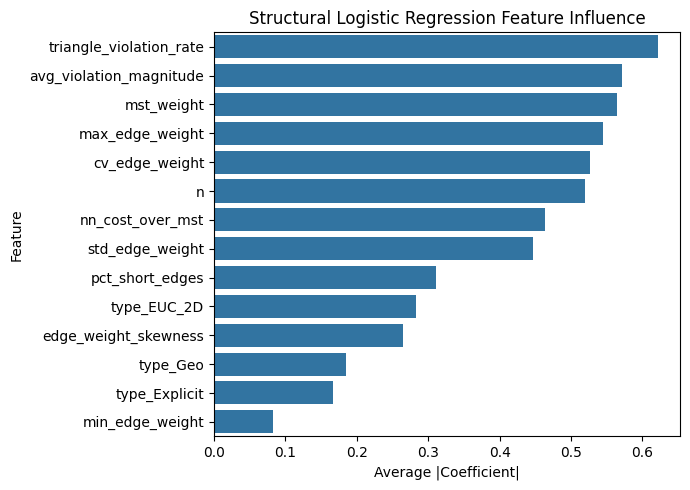

In [ ]:
# ==============================
# STRUCTURAL MULTICLASS LOGISTIC REGRESSION
# ==============================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression

# ------------------------------
# 1. Load Dataset
# ------------------------------
CSV_PATH = "/content/drive/MyDrive/Dataframe/Dataset.csv"
df_struct_lr = pd.read_csv(CSV_PATH)

# ------------------------------
# 2. Define Feasibility + Oracle
# ------------------------------
RUNTIME_CAP = 600_000
EPS = 0.05

df_struct_lr["feasible"] = df_struct_lr["runtime_ms"] <= RUNTIME_CAP

df_struct_lr["best_feasible_cost"] = (
    df_struct_lr[df_struct_lr["feasible"]]
    .groupby("file")["cost"]
    .transform("min")
)

df_struct_lr["is_best"] = (
    df_struct_lr["feasible"] &
    (df_struct_lr["cost"] <=
     (1 + EPS) * df_struct_lr["best_feasible_cost"])
)

# ------------------------------
# 3. Select One Best Heuristic Per Instance
# ------------------------------
best_rows = (
    df_struct_lr[df_struct_lr["is_best"]]
    .sort_values(["file", "cost"])
    .groupby("file")
    .first()
    .reset_index()
)

# ------------------------------
# 4. Define Structural Features (NO heuristic input)
# ------------------------------
numeric_features = [
    "n",
    "min_edge_weight",
    "max_edge_weight",
    "std_edge_weight",
    "cv_edge_weight",
    "edge_weight_skewness",
    "pct_short_edges",
    "triangle_violation_rate",
    "avg_violation_magnitude",
    "mst_weight",
    "nn_cost_over_mst",
]

categorical_features = ["type"]

X = best_rows[numeric_features + categorical_features]
y = best_rows["heuristic"]

# ------------------------------
# 5. Encode Target Labels
# ------------------------------
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# ------------------------------
# 6. Train/Test Split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=3,
    stratify=y_encoded
)

# ------------------------------
# 7. Preprocessing
# ------------------------------
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"),
         categorical_features),
    ]
)

# ------------------------------
# 8. Logistic Regression Model
# ------------------------------
logreg_model = LogisticRegression(
    max_iter=5000,
    solver="lbfgs",
    n_jobs=-1
)

pipeline_struct_lr = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("classifier", logreg_model),
    ]
)

# ------------------------------
# 9. Train
# ------------------------------
pipeline_struct_lr.fit(X_train, y_train)

# ------------------------------
# 10. Predict
# ------------------------------
y_pred_encoded = pipeline_struct_lr.predict(X_test)
y_pred = label_encoder.inverse_transform(y_pred_encoded)
y_true = label_encoder.inverse_transform(y_test)

# ------------------------------
# 11. Build Evaluation Table
# ------------------------------
eval_struct_lr = best_rows.loc[X_test.index].copy()
eval_struct_lr["true_heuristic"] = y_true
eval_struct_lr["predicted_heuristic"] = y_pred

lookup = df_struct_lr[[
    "file",
    "heuristic",
    "cost",
    "best_feasible_cost"
]]

eval_struct_lr = eval_struct_lr.merge(
    lookup,
    left_on=["file", "predicted_heuristic"],
    right_on=["file", "heuristic"],
    how="left",
    suffixes=("", "_pred")
)

# Rename predicted cost explicitly
eval_struct_lr = eval_struct_lr.rename(
    columns={"cost_pred": "predicted_cost"}
)

# Compute regret
eval_struct_lr["regret"] = (
    eval_struct_lr["predicted_cost"] /
    eval_struct_lr["best_feasible_cost"] - 1
)

# ------------------------------
# 12. Print Performance
# ------------------------------
print("Mean regret:", eval_struct_lr["regret"].mean())
print("Median regret:", eval_struct_lr["regret"].median())
print("Catastrophic failure rate:",
      (eval_struct_lr["regret"] > 1).mean())
print("Non-Zero Regret Rate:",
      (eval_struct_lr["regret"] > 0).mean())

print("Exact match rate:",
      (eval_struct_lr["true_heuristic"] ==
       eval_struct_lr["predicted_heuristic"]).mean())

# ------------------------------
# 13. Extract Feature Coefficients
# ------------------------------
clf = pipeline_struct_lr.named_steps["classifier"]
pre = pipeline_struct_lr.named_steps["preprocess"]

feature_names = np.concatenate([
    numeric_features,
    pre.named_transformers_["cat"]
        .get_feature_names_out(categorical_features)
])

coef_matrix = clf.coef_

coef_df = pd.DataFrame(
    coef_matrix,
    columns=feature_names,
    index=label_encoder.classes_
)

# Average absolute coefficient magnitude per feature
avg_abs_coef = coef_df.abs().mean().sort_values(ascending=False)

coef_summary = avg_abs_coef.reset_index()
coef_summary.columns = ["feature", "avg_abs_coef"]

print("\nTop Structural Features (Logistic Regression):")
print(coef_summary.head(30))

# ------------------------------
# 14. Plot Feature Importance
# ------------------------------
plt.figure(figsize=(7,5))
sns.barplot(
    data=coef_summary,
    y="feature",
    x="avg_abs_coef"
)
plt.title("Structural Logistic Regression Feature Influence")
plt.xlabel("Average |Coefficient|")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

LR Train accuracy: 0.8281, Test accuracy: 0.7812
              precision    recall  f1-score   support

          CH       0.75      1.00      0.86        15
      Greedy       1.00      0.67      0.80         6
   Insertion       0.75      0.67      0.71         9
          NN       0.00      0.00      0.00         2

    accuracy                           0.78        32
   macro avg       0.62      0.58      0.59        32
weighted avg       0.75      0.78      0.75        32



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


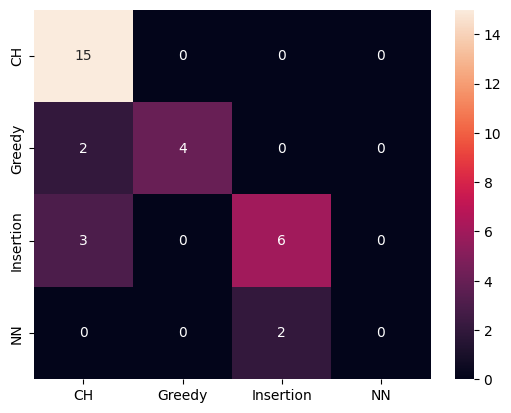

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Compare train/test accuracy
train_acc = pipeline_struct_lr.score(X_train, y_train)
test_acc = pipeline_struct_lr.score(X_test, y_test)
print(f"LR Train accuracy: {train_acc:.4f}, Test accuracy: {test_acc:.4f}")

# 2. Per‑class performance
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

# 3. Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.show()

# 4. Check if RF/XGB have lower test accuracy for the same split
# (you need to have stored y_test_rf, y_pred_rf, etc.)

In [ ]:
# ------------------------------
# Display detailed prediction results (like RF)
# ------------------------------
print(eval_struct_lr[[
    "file",
    "true_heuristic",
    "predicted_heuristic",
    "predicted_cost",
    "best_feasible_cost",
    "regret"
]].sort_values("regret", ascending=False))

# ------------------------------
# Confusion Matrix (True vs Predicted)
# ------------------------------
print("\n--- Confusion Matrix ---")
confusion = pd.crosstab(
    eval_struct_lr["true_heuristic"],
    eval_struct_lr["predicted_heuristic"],
    rownames=["True"],
    colnames=["Predicted"]
)
print(confusion)

# ------------------------------
# Per‑class accuracy (corrected)
# ------------------------------
eval_struct_lr["correct"] = eval_struct_lr["true_heuristic"] == eval_struct_lr["predicted_heuristic"]
class_accuracy = eval_struct_lr.groupby("true_heuristic")["correct"].mean()
print("\n--- Per‑class Accuracy ---")
print(class_accuracy)

# Optional: drop the temporary column if you don't need it later
eval_struct_lr.drop("correct", axis=1, inplace=True)

                          file true_heuristic predicted_heuristic  \
5                        fri26         Greedy                  CH   
15   christofides_hard_n700_s0             NN           Insertion   
28                       gr120      Insertion                  CH   
16                      tsp225         Greedy                  CH   
20                       pr226      Insertion                  CH   
8                        u1432      Insertion                  CH   
3    christofides_hard_n450_s0      Insertion           Insertion   
0      family_A_random_n175_s0         Greedy              Greedy   
7    christofides_hard_n525_s0      Insertion           Insertion   
6                         a280             CH                  CH   
10                       gr137             CH                  CH   
9   family_B_clustered_n200_s0      Insertion           Insertion   
11     family_A_random_n275_s0         Greedy              Greedy   
4                      nrw1379    

##Random Forest

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

CSV_PATH = "/content/drive/MyDrive/Dataframe/Dataset.csv"
df_struct = pd.read_csv(CSV_PATH)

In [ ]:
RUNTIME_CAP_STRUCT = 600_000
EPS_STRUCT = 0.05

df_struct["feasible_struct"] = df_struct["runtime_ms"] <= RUNTIME_CAP_STRUCT

In [ ]:
df_struct["best_feasible_cost_struct"] = (
    df_struct[df_struct["feasible_struct"]]
    .groupby("file")["cost"]
    .transform("min")
)

In [ ]:
df_struct["is_best_struct"] = (
    df_struct["feasible_struct"] &
    (df_struct["cost"] <= (1 + EPS_STRUCT) * df_struct["best_feasible_cost_struct"])
)

In [ ]:
best_rows = (
    df_struct[df_struct["is_best_struct"]]
    .sort_values(["file", "cost"])
    .groupby("file")
    .first()
    .reset_index()
)

In [ ]:
instance_features_struct = [
    "n",
    "min_edge_weight",
    "max_edge_weight",
    "std_edge_weight",
    "cv_edge_weight",
    "edge_weight_skewness",
    "pct_short_edges",
    "triangle_violation_rate",
    "avg_violation_magnitude",
    "mst_weight",
    "nn_cost_over_mst",
    "type"
]

In [ ]:
y_struct = best_rows["heuristic"]
X_struct = best_rows[instance_features_struct]

In [ ]:
numeric_features_struct = [
    "n",
    "min_edge_weight",
    "max_edge_weight",
    "std_edge_weight",
    "cv_edge_weight",
    "edge_weight_skewness",
    "pct_short_edges",
    "triangle_violation_rate",
    "avg_violation_magnitude",
    "mst_weight",
    "nn_cost_over_mst",
]

In [ ]:
from sklearn.preprocessing import OneHotEncoder
categorical_features_struct = ["type"]
preprocess_struct = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features_struct),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_struct),
    ]
)

In [ ]:
rf_struct = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    random_state=2,
    n_jobs=-1
)

rf_pipeline_struct = Pipeline(
    steps=[
        ("preprocess", preprocess_struct),
        ("classifier", rf_struct),
    ]
)

In [ ]:
X_train_struct, X_test_struct, y_train_struct, y_test_struct = train_test_split(
    X_struct,
    y_struct,
    test_size=0.2,
    random_state=2,
    stratify=y_struct
)

In [ ]:
rf_pipeline_struct.fit(X_train_struct, y_train_struct)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['n', 'min_edge_weight',
                                                   'max_edge_weight',
                                                   'std_edge_weight',
                                                   'cv_edge_weight',
                                                   'edge_weight_skewness',
                                                   'pct_short_edges',
                                                   'triangle_violation_rate',
                                                   'avg_violation_magnitude',
                                                   'mst_weight',
                                                   'nn_cost_over_mst']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['type'])])),
                ('classifier',
                 RandomForestClassifier(min_samples_leaf=2, n_estimators=400,
                                        n_jobs=-1, random_state=2))])

In [ ]:
y_pred_struct = rf_pipeline_struct.predict(X_test_struct)

In [ ]:
test_instances_struct = best_rows.loc[X_test_struct.index].copy()
test_instances_struct["predicted_heuristic"] = y_pred_struct

In [ ]:
pred_costs = df_struct.merge(
    test_instances_struct[["file", "predicted_heuristic"]],
    left_on=["file", "heuristic"],
    right_on=["file", "predicted_heuristic"],
    how="inner"
)

In [ ]:
pred_costs["regret_struct"] = (
    pred_costs["cost"] /
    pred_costs["best_feasible_cost_struct"] - 1
)

print("STRUCTURAL RF Mean regret:", pred_costs["regret_struct"].mean())
print("STRUCTURAL RF Median regret:", pred_costs["regret_struct"].median())

STRUCTURAL RF Mean regret: 0.008078360091374436
STRUCTURAL RF Median regret: 0.0


Printing Results

In [ ]:
# ============================================
# FIXED RANDOM FOREST EVALUATION CODE
# ============================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------------
# STEP 1: Get test instances
# ------------------------------------------------------------------
eval_struct = best_rows.loc[X_test_struct.index].copy()

# ------------------------------------------------------------------
# STEP 2: Add true and predicted heuristics
# ------------------------------------------------------------------
eval_struct["true_heuristic"] = y_test_struct.values
eval_struct["predicted_heuristic"] = y_pred_struct

# ------------------------------------------------------------------
# STEP 3: Create lookup table with NO DUPLICATES
# ------------------------------------------------------------------
pred_cost_lookup = df_struct[[
    "file",
    "heuristic",
    "cost",
    "best_feasible_cost_struct"
]].drop_duplicates()  # ← CRITICAL FIX: Remove duplicates!

# ------------------------------------------------------------------
# STEP 4: Merge with suffixes to avoid column conflicts
# ------------------------------------------------------------------
eval_struct = eval_struct.merge(
    pred_cost_lookup,
    left_on=["file", "predicted_heuristic"],
    right_on=["file", "heuristic"],
    how="left",
    suffixes=("", "_lookup")  # This prevents column name conflicts
)

# ------------------------------------------------------------------
# STEP 5: Drop the redundant 'heuristic' column
# ------------------------------------------------------------------
eval_struct = eval_struct.drop(columns=["heuristic"], errors="ignore")

# ------------------------------------------------------------------
# STEP 6: Identify which cost columns to use
# ------------------------------------------------------------------
# After merge, we might have both 'cost' and 'cost_lookup'
# Use the one from the lookup (which is what we want)
cost_col = 'cost_lookup' if 'cost_lookup' in eval_struct.columns else 'cost'
best_cost_col = 'best_feasible_cost_struct_lookup' if 'best_feasible_cost_struct_lookup' in eval_struct.columns else 'best_feasible_cost_struct'

# ------------------------------------------------------------------
# STEP 7: Compute regret safely (handling missing values)
# ------------------------------------------------------------------
eval_struct["regret_struct"] = np.nan

# Only compute for rows with valid data
valid_mask = eval_struct[cost_col].notna() & eval_struct[best_cost_col].notna()
eval_struct.loc[valid_mask, "regret_struct"] = (
    eval_struct.loc[valid_mask, cost_col] /
    eval_struct.loc[valid_mask, best_cost_col] - 1
)

# ------------------------------------------------------------------
# STEP 8: Display detailed results
# ------------------------------------------------------------------
print("\n--- Detailed Results (highest regret first) ---")
# Create a display DataFrame with consistent column names
display_df = eval_struct[[
    "file",
    "true_heuristic",
    "predicted_heuristic",
    cost_col,
    best_cost_col,
    "regret_struct"
]].copy()
display_df = display_df.rename(columns={
    cost_col: "cost",
    best_cost_col: "best_feasible_cost_struct"
})
print(display_df.sort_values("regret_struct", ascending=False).to_string())

# ------------------------------------------------------------------
# STEP 9: Calculate metrics (using only valid predictions)
# ------------------------------------------------------------------
valid_eval = eval_struct[eval_struct["regret_struct"].notna()].copy()

if len(valid_eval) > 0:
    cat_failure_rate = (valid_eval["regret_struct"] > 1).mean()
    nonzero_failure_rate = (valid_eval["regret_struct"] > 0).mean()
    exact_match_rate = (valid_eval["true_heuristic"] == valid_eval["predicted_heuristic"]).mean()

    print("\n--- Random Forest Performance Metrics ---")
    print(f"Catastrophic Failure Rate (regret > 1): {cat_failure_rate:.4f}")
    print(f"Non-zero Regret Rate (regret > 0): {nonzero_failure_rate:.4f}")
    print(f"Exact Heuristic Match Rate: {exact_match_rate:.4f}")
    print(f"Mean regret: {valid_eval['regret_struct'].mean():.6f}")
    print(f"Median regret: {valid_eval['regret_struct'].median():.6f}")

    # Also show how many predictions were invalid
    invalid_count = len(eval_struct) - len(valid_eval)
    if invalid_count > 0:
        print(f"\nNote: {invalid_count} predictions were infeasible (no cost data)")
else:
    print("No valid predictions with cost data!")


--- Detailed Results (highest regret first) ---
                          file true_heuristic predicted_heuristic      cost  best_feasible_cost_struct  regret_struct
19                       pr144             NN                  CH   70610.0                    61652.0       0.145299
28                       att48      Insertion                  CH   12613.0                    11827.0       0.066458
8   family_B_clustered_n275_s0             NN           Insertion    8375.0                     8002.0       0.046613
5                        si175             CH              Greedy   21957.0                    21954.0       0.000137
3                      kroB100             CH                  CH   24012.0                    24012.0       0.000000
4                        pr439             CH                  CH  120358.0                   120358.0       0.000000
2      family_A_random_n275_s0         Greedy              Greedy  184402.0                   184402.0       0.000000
0      

Feature Weights

In [ ]:
rf_struct_model = rf_pipeline_struct.named_steps["classifier"]
pre_struct = rf_pipeline_struct.named_steps["preprocess"]

In [ ]:
# Numeric feature names
num_features = numeric_features_struct

# One-hot encoded categorical feature names
cat_features = pre_struct.named_transformers_["cat"] \
    .get_feature_names_out(categorical_features_struct)

# Combine
feature_names_struct = np.concatenate([num_features, cat_features])

In [ ]:
importances_struct = rf_struct_model.feature_importances_

rf_struct_importance_df = pd.DataFrame({
    "feature": feature_names_struct,
    "importance": importances_struct
}).sort_values("importance", ascending=False)

rf_struct_importance_df

,feature,importance
7,triangle_violation_rate,0.154346
8,avg_violation_magnitude,0.121350
9,mst_weight,0.120365
0,n,0.086645
4,cv_edge_weight,0.083681
10,nn_cost_over_mst,0.077904
6,pct_short_edges,0.068691
5,edge_weight_skewness,0.066760
12,type_Explicit,0.063739
3,std_edge_weight,0.050532


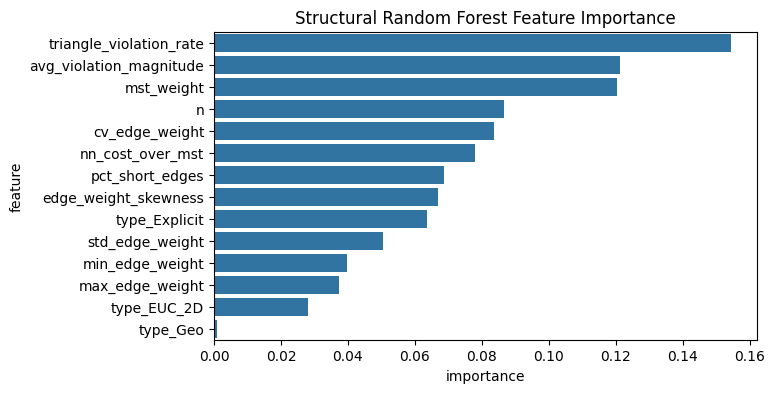

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

sns.barplot(
    data=rf_struct_importance_df,
    y="feature",
    x="importance"
)

plt.title("Structural Random Forest Feature Importance")
plt.show()

##XGBoost

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from xgboost import XGBClassifier

# ---------- 1. Load and prepare data ----------
CSV_PATH = "/content/drive/MyDrive/Dataframe/Dataset.csv"
df = pd.read_csv(CSV_PATH)

RUNTIME_CAP = 600_000
EPS = 0.05

df["feasible"] = df["runtime_ms"] <= RUNTIME_CAP
df["best_feasible_cost"] = (
    df[df["feasible"]]
    .groupby("file")["cost"]
    .transform("min")
)
df["is_best"] = (
    df["feasible"] &
    (df["cost"] <= (1 + EPS) * df["best_feasible_cost"])
)

best_rows = (
    df[df["is_best"]]
    .sort_values(["file", "cost"])
    .groupby("file")
    .first()
    .reset_index(drop=False)   # keep 'file' as a column, not index
)

# Features and target
feature_cols = [
    "n", "min_edge_weight", "max_edge_weight", "std_edge_weight",
    "cv_edge_weight", "edge_weight_skewness", "pct_short_edges",
    "triangle_violation_rate", "avg_violation_magnitude",
    "mst_weight", "nn_cost_over_mst", "type"
]
X = best_rows[feature_cols]
y = best_rows["heuristic"]          # string labels

# ---------- 2. Encode target ----------
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)   # now integers

# ---------- 3. Train/test split (keep file IDs for later) ----------
X_train, X_test, y_train, y_test, files_train, files_test = train_test_split(
    X, y_encoded, best_rows["file"],
    test_size=0.2,
    random_state=2,
    stratify=y_encoded          # stratification works with integer labels
)

# ---------- 4. Preprocessing pipeline ----------
numeric_features = [
    "n", "min_edge_weight", "max_edge_weight", "std_edge_weight",
    "cv_edge_weight", "edge_weight_skewness", "pct_short_edges",
    "triangle_violation_rate", "avg_violation_magnitude",
    "mst_weight", "nn_cost_over_mst"
]
categorical_features = ["type"]

preprocessor = ColumnTransformer([
    ("num", "passthrough", numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=2,
    n_jobs=-1
)

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", xgb_model)
])

# ---------- 5. Train ----------
pipeline.fit(X_train, y_train)

# ---------- 6. Predict ----------
y_pred_encoded = pipeline.predict(X_test)
y_pred = label_encoder.inverse_transform(y_pred_encoded)   # back to strings

# ---------- 7. Evaluate using file merge (no index dependency) ----------
# Create a DataFrame with test files and their predicted heuristics
test_results = pd.DataFrame({
    "file": files_test.values,
    "predicted_heuristic": y_pred,
    "true_heuristic": label_encoder.inverse_transform(y_test)
})

# Merge with the full dataset to get cost and best feasible cost
eval_df = test_results.merge(
    df[["file", "heuristic", "cost", "best_feasible_cost"]],
    left_on=["file", "predicted_heuristic"],
    right_on=["file", "heuristic"],
    how="left"
)
eval_df = eval_df.drop(columns=["heuristic"])   # remove duplicate column

# Compute regret
eval_df["regret"] = eval_df["cost"] / eval_df["best_feasible_cost"] - 1

# ---------- 8. Print results ----------
print("\n--- Detailed Results (highest regret first) ---")
print(eval_df[["file", "true_heuristic", "predicted_heuristic",
               "cost", "best_feasible_cost", "regret"]]
      .sort_values("regret", ascending=False))

cat_failure = (eval_df["regret"] > 1).mean()
nonzero_regret = (eval_df["regret"] > 0).mean()
exact_match = (eval_df["true_heuristic"] == eval_df["predicted_heuristic"]).mean()

print("\n--- XGBoost Performance Metrics ---")
print(f"Catastrophic Failure Rate (regret > 1): {cat_failure:.4f}")
print(f"Non-zero Regret Rate (regret > 0): {nonzero_regret:.4f}")
print(f"Exact Heuristic Match Rate: {exact_match:.4f}")
print(f"Mean regret: {eval_df['regret'].mean():.6f}")
print(f"Median regret: {eval_df['regret'].median():.6f}")

# ---------- 9. Regret distribution plot (compare with Random Forest) ----------
# Assuming you have a DataFrame 'rf_eval' with Random Forest results containing 'regret' column
plt.figure(figsize=(7,4))
sns.kdeplot(eval_struct["regret_struct"], label="Random Forest", fill=True, alpha=0.5)
sns.kdeplot(eval_df["regret"], label="XGBoost", fill=True, alpha=0.5)# adjust rf_eval name
plt.xlabel("Regret")
plt.title("Regret Distribution Comparison")
plt.legend()
plt.tight_layout()
plt.show()


--- Detailed Results (highest regret first) ---
                          file true_heuristic predicted_heuristic      cost  \
21   christofides_hard_n750_s0      Insertion                  NN    3998.0   
19                       pr144             NN                  CH   70610.0   
28                       att48      Insertion                  CH   12613.0   
8   family_B_clustered_n275_s0             NN           Insertion    8375.0   
5                        si175             CH              Greedy   21957.0   
3                      kroB100             CH                  CH   24012.0   
2      family_A_random_n275_s0         Greedy              Greedy  184402.0   
0                        pr152             CH                  CH   79224.0   
7                        ch130             CH                  CH    6841.0   
9                        gr202             CH                  CH   43377.0   
10     family_A_random_n200_s0         Greedy              Greedy  150020.0   
11 

NameError: name 'eval_struct' is not defined

<Figure size 700x400 with 0 Axes>

Feature Weights


--- XGBoost Feature Importances ---
                    feature  importance
8   avg_violation_magnitude    0.237604
9                mst_weight    0.166939
7   triangle_violation_rate    0.123924
0                         n    0.075967
4            cv_edge_weight    0.075291
5      edge_weight_skewness    0.058537
10         nn_cost_over_mst    0.057581
6           pct_short_edges    0.047031
2           max_edge_weight    0.044002
1           min_edge_weight    0.040693
3           std_edge_weight    0.032520
11              type_EUC_2D    0.024097
12            type_Explicit    0.008103
13                 type_Geo    0.007712


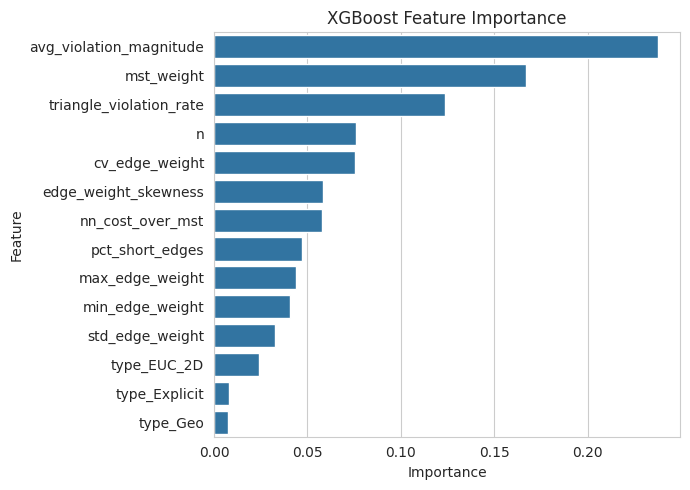

In [ ]:
# ---------- 10. Feature Importance for XGBoost ----------
# Get the trained XGBoost classifier from the pipeline
xgb_model_trained = pipeline.named_steps["classifier"]

# Get the preprocessor from the pipeline
preprocessor = pipeline.named_steps["preprocess"]

# Retrieve feature names after one-hot encoding
feature_names_xgb = np.concatenate([
    numeric_features,
    preprocessor.named_transformers_["cat"]
        .get_feature_names_out(categorical_features)
])

# Extract feature importances
importance_xgb = xgb_model_trained.feature_importances_

# Create a DataFrame for visualization
xgb_importance_df = pd.DataFrame({
    "feature": feature_names_xgb,
    "importance": importance_xgb
}).sort_values("importance", ascending=False)

# Display top features
print("\n--- XGBoost Feature Importances ---")
print(xgb_importance_df)

# Plot
plt.figure(figsize=(7, 5))
sns.barplot(data=xgb_importance_df, y="feature", x="importance")
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

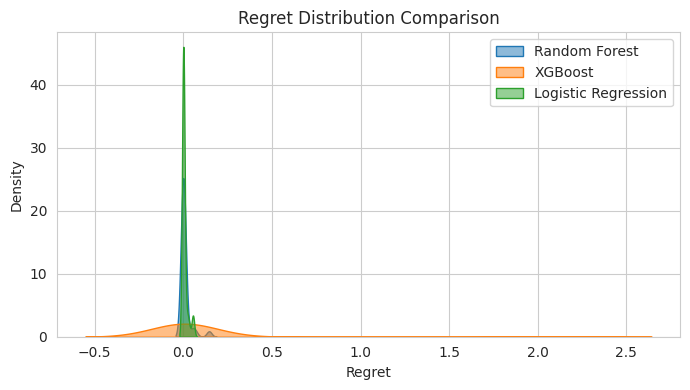

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a nice style (optional)
sns.set_style("whitegrid")

plt.figure(figsize=(7, 4))

# Plot Random Forest regret (adjust column name if needed)
sns.kdeplot(eval_struct["regret_struct"], label="Random Forest", fill=True, alpha=0.5)

# Plot XGBoost regret (adjust column name if needed)
sns.kdeplot(eval_df["regret"], label="XGBoost", fill=True, alpha=0.5)

sns.kdeplot(eval_struct_lr["regret"], label="Logistic Regression", fill=True, alpha=0.5)

plt.xlabel("Regret")
plt.title("Regret Distribution Comparison")
plt.legend()
plt.tight_layout()
plt.show()

#Integrated Models (Using Heuristic Data from Predicted Instead of Given Data)

##Random Forest

In [ ]:
pip install quantile-forest

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 11.6 MB/s eta 0:00:00


INTEGRATED TWO-STAGE PIPELINE WITH QUANTILE REGRESSION
Stage 1: Best Heuristic Classifier (Random Forest)
Stage 2: Optimality Gap Regressor with 90% Prediction Intervals (Quantile Forest)
Total instances: 160
Total rows in full dataset: 640

STAGE 1: Training Best Heuristic Classifier
Classifier Accuracy: 0.7812

STAGE 2: Preparing Quantile Optimality Gap Regressor

Optimality gap statistics:
  Min: 1.81%
  Max: 5496.41%
  Mean: 284.36%
  Median: 20.72%

Gap model training rows: 496
Gap model test rows: 128

Training Quantile Random Forest for 90% prediction intervals...

Quantile Regressor Performance:
  MAE: 44.40%
  R² (log scale): 0.9582

Prediction Interval Performance (90% nominal):
  Empirical coverage: 89.84%
  Mean interval width: 198.65 percentage points
  Median interval width: 13.94 percentage points

INTEGRATED PREDICTION ON TEST INSTANCES

INTEGRATED PIPELINE PERFORMANCE

📊 Gap Prediction Performance (for predicted heuristics):
   MAE:  30.64 percentage points
   RMSE: 12

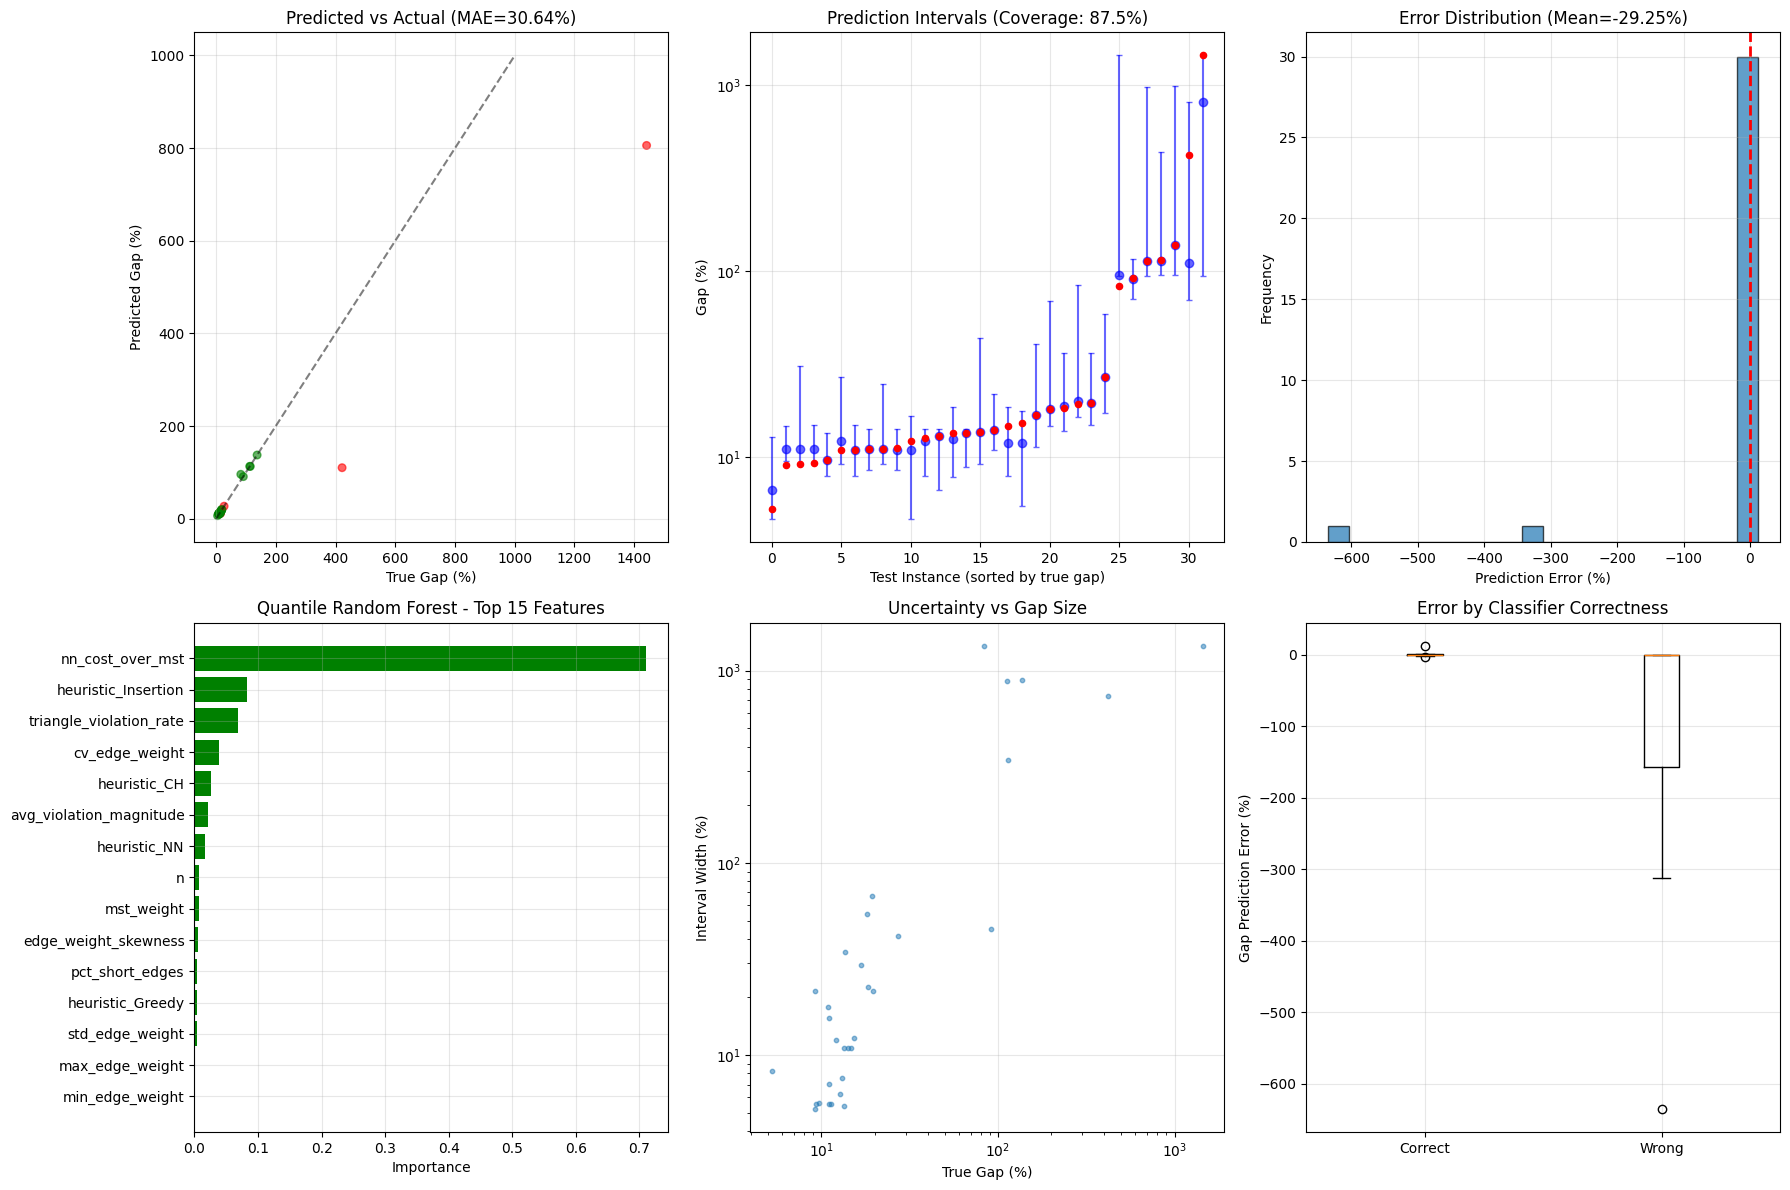


FINAL SUMMARY

INTEGRATED TWO-STAGE PIPELINE WITH QUANTILE REGRESSION
Test Instances: 32

STAGE 1: BEST HEURISTIC CLASSIFIER
  - Accuracy: 78.12%
  - Correct: 25/32

STAGE 2: QUANTILE OPTIMALITY GAP REGRESSOR
  - MAE: 30.64 percentage points
  - RMSE: 125.16
  - R² (log scale): 0.9481
  - Within ±10%: 90.62%
  - Within ±20%: 93.75%
  - Within ±30%: 93.75%

UNCERTAINTY QUANTIFICATION (90% Prediction Intervals)
  - Empirical coverage: 87.50%
  - Mean interval width: 188.75 percentage points
  - Median interval width: 16.62 percentage points

COMBINED PERFORMANCE
  - Average Regret if using predicted heuristic: 0.0901
  - Median Regret: 0.0000


✅ Results saved to:
   - seed_1_rf_quantile_integrated_results.csv
   - seed_1_rf_quantile_feature_importance.csv


In [ ]:
# ============================================
# INTEGRATED TWO-STAGE PIPELINE WITH QUANTILE REGRESSION
# Stage 1: Predict Best Heuristic (Random Forest Classifier)
# Stage 2: Predict Optimality Gap with 90% Prediction Intervals (Quantile Regression)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from quantile_forest import RandomForestQuantileRegressor
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("INTEGRATED TWO-STAGE PIPELINE WITH QUANTILE REGRESSION")
print("Stage 1: Best Heuristic Classifier (Random Forest)")
print("Stage 2: Optimality Gap Regressor with 90% Prediction Intervals (Quantile Forest)")
print("="*80)

# ============================================
# PART 1: LOAD AND PREPARE DATA
# ============================================
CSV_PATH = "/content/drive/MyDrive/Dataframe/Dataset.csv"
df = pd.read_csv(CSV_PATH)

RUNTIME_CAP = 600_000
EPS = 0.05

# Define feasibility and best heuristic
df["feasible"] = df["runtime_ms"] <= RUNTIME_CAP
df["best_feasible_cost"] = (
    df[df["feasible"]]
    .groupby("file")["cost"]
    .transform("min")
)
df["is_best"] = (
    df["feasible"] &
    (df["cost"] <= (1 + EPS) * df["best_feasible_cost"])
)

# Get best heuristic per instance
best_rows = (
    df[df["is_best"]]
    .sort_values(["file", "cost"])
    .groupby("file")
    .first()
    .reset_index()
)

# Instance features (same for both models)
instance_features = [
    "n", "min_edge_weight", "max_edge_weight", "std_edge_weight",
    "cv_edge_weight", "edge_weight_skewness", "pct_short_edges",
    "triangle_violation_rate", "avg_violation_magnitude",
    "mst_weight", "nn_cost_over_mst", "type"
]

numeric_features = [f for f in instance_features if f != "type"]
categorical_features = ["type"]

print(f"Total instances: {len(best_rows)}")
print(f"Total rows in full dataset: {len(df)}")

# ============================================
# PART 2: STAGE 1 - BEST HEURISTIC CLASSIFIER
# ============================================
print("\n" + "="*60)
print("STAGE 1: Training Best Heuristic Classifier")
print("="*60)

# Prepare data for classifier
X_class = best_rows[instance_features]
y_class = best_rows["heuristic"]

# Split data (same random_state for reproducibility)
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.2, random_state=1, stratify=y_class
)

# Preprocessing for classifier
preprocess_class = ColumnTransformer([
    ("num", "passthrough", numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

# Random Forest Classifier
rf_classifier = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    random_state=3,
    n_jobs=-1
)

pipeline_class = Pipeline([
    ("preprocess", preprocess_class),
    ("classifier", rf_classifier)
])

# Train classifier
pipeline_class.fit(X_train_class, y_train_class)

# Predict on test set
y_pred_class = pipeline_class.predict(X_test_class)

# Classifier performance
class_accuracy = (y_pred_class == y_test_class).mean()
print(f"Classifier Accuracy: {class_accuracy:.4f}")

# Store test instance info
test_files = best_rows.loc[X_test_class.index, "file"].values
test_instances = pd.DataFrame({
    'file': test_files,
    'true_heuristic': y_test_class.values,
    'predicted_heuristic': y_pred_class
})

# ============================================
# PART 3: PREPARE DATA FOR STAGE 2 (QUANTILE GAP REGRESSOR)
# ============================================
print("\n" + "="*60)
print("STAGE 2: Preparing Quantile Optimality Gap Regressor")
print("="*60)

# Clean data for gap regression (remove rows with missing optimality_gap)
df_gap = df.dropna(subset=['optimality_gap']).copy()

# Apply log transformation to optimality_gap
df_gap['gap_log'] = np.log1p(df_gap['optimality_gap'])

print(f"\nOptimality gap statistics:")
print(f"  Min: {df_gap['optimality_gap'].min():.2f}%")
print(f"  Max: {df_gap['optimality_gap'].max():.2f}%")
print(f"  Mean: {df_gap['optimality_gap'].mean():.2f}%")
print(f"  Median: {df_gap['optimality_gap'].median():.2f}%")

# Features for gap model: instance features + heuristic
gap_feature_cols = instance_features + ['heuristic']
X_gap = df_gap[gap_feature_cols]
y_gap = df_gap['gap_log']

# Split gap data by file to prevent leakage
unique_files_gap = df_gap['file'].unique()
train_files_gap, test_files_gap = train_test_split(
    unique_files_gap, test_size=0.2, random_state=1
)

train_mask_gap = df_gap['file'].isin(train_files_gap)
test_mask_gap = df_gap['file'].isin(test_files_gap)

X_train_gap, X_test_gap = X_gap[train_mask_gap], X_gap[test_mask_gap]
y_train_gap, y_test_gap = y_gap[train_mask_gap], y_gap[test_mask_gap]

print(f"\nGap model training rows: {len(X_train_gap)}")
print(f"Gap model test rows: {len(X_test_gap)}")

# Preprocessing for gap model (includes heuristic!)
gap_numeric = [f for f in instance_features if f != "type"]
gap_categorical = ["type", "heuristic"]  # Includes heuristic!

preprocess_gap = ColumnTransformer([
    ("num", StandardScaler(), gap_numeric),  # Scale for regression
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), gap_categorical)
])

# Transform the data for the quantile forest
X_train_gap_processed = preprocess_gap.fit_transform(X_train_gap)
X_test_gap_processed = preprocess_gap.transform(X_test_gap)

# Get feature names for later
cat_feat_names = preprocess_gap.named_transformers_["cat"].get_feature_names_out(["type", "heuristic"])
all_feature_names = np.concatenate([gap_numeric, cat_feat_names])

# Quantile Random Forest Regressor
print("\nTraining Quantile Random Forest for 90% prediction intervals...")
quantile_rf = RandomForestQuantileRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    random_state=3,
    n_jobs=-1
)

quantile_rf.fit(X_train_gap_processed, y_train_gap)

# Predict on test set (0.05, 0.5, 0.95 quantiles)
y_pred_quantiles = quantile_rf.predict(X_test_gap_processed, quantiles=[0.05, 0.5, 0.95])

# Extract quantiles
y_lower_log = y_pred_quantiles[:, 0]   # 5th percentile
y_pred_log = y_pred_quantiles[:, 1]    # 50th percentile (median)
y_upper_log = y_pred_quantiles[:, 2]   # 95th percentile

# Convert back to original scale
y_lower = np.expm1(y_lower_log)
y_pred = np.expm1(y_pred_log)
y_upper = np.expm1(y_upper_log)
y_test_orig = np.expm1(y_test_gap)

# Evaluate point predictions
point_mae = mean_absolute_error(y_test_orig, y_pred)
point_r2_log = r2_score(y_test_gap, y_pred_log)

print(f"\nQuantile Regressor Performance:")
print(f"  MAE: {point_mae:.2f}%")
print(f"  R² (log scale): {point_r2_log:.4f}")

# Evaluate interval coverage (should be ~90%)
coverage = np.mean((y_test_orig >= y_lower) & (y_test_orig <= y_upper))
mean_width = np.mean(y_upper - y_lower)
median_width = np.median(y_upper - y_lower)

print(f"\nPrediction Interval Performance (90% nominal):")
print(f"  Empirical coverage: {coverage*100:.2f}%")
print(f"  Mean interval width: {mean_width:.2f} percentage points")
print(f"  Median interval width: {median_width:.2f} percentage points")

# ============================================
# PART 4: INTEGRATED PREDICTION ON TEST INSTANCES
# ============================================
print("\n" + "="*60)
print("INTEGRATED PREDICTION ON TEST INSTANCES")
print("="*60)

integrated_results = []

for idx, row in test_instances.iterrows():
    file = row['file']
    true_heuristic = row['true_heuristic']
    pred_heuristic = row['predicted_heuristic']

    # Get instance features for this file
    instance_row = best_rows[best_rows['file'] == file].iloc[0]

    # Create feature vector for gap prediction using PREDICTED heuristic
    gap_input = {}
    for feat in instance_features:
        gap_input[feat] = instance_row[feat]
    gap_input['heuristic'] = pred_heuristic  # Use PREDICTED heuristic!

    # Convert to DataFrame for prediction
    gap_df = pd.DataFrame([gap_input])

    # Transform
    X_proc = preprocess_gap.transform(gap_df)

    # Predict quantiles (0.05, 0.5, 0.95)
    pred_quantiles = quantile_rf.predict(X_proc, quantiles=[0.05, 0.5, 0.95])

    pred_gap_log = pred_quantiles[0, 1]  # Median
    lower_gap_log = pred_quantiles[0, 0]  # 5th percentile
    upper_gap_log = pred_quantiles[0, 2]  # 95th percentile

    pred_gap = np.expm1(pred_gap_log)
    lower_gap = np.expm1(lower_gap_log)
    upper_gap = np.expm1(upper_gap_log)

    # Get true gap for the predicted heuristic (if available)
    true_gap_row = df_gap[(df_gap['file'] == file) &
                          (df_gap['heuristic'] == pred_heuristic)]

    if len(true_gap_row) > 0:
        true_gap = true_gap_row['optimality_gap'].iloc[0]
        true_gap_log = true_gap_row['gap_log'].iloc[0]
    else:
        true_gap = np.nan
        true_gap_log = np.nan

    # Get true gap for the actual best heuristic
    true_best_row = df_gap[(df_gap['file'] == file) &
                           (df_gap['heuristic'] == true_heuristic)]
    true_best_gap = true_best_row['optimality_gap'].iloc[0] if len(true_best_row) > 0 else np.nan

    integrated_results.append({
        'file': file,
        'true_heuristic': true_heuristic,
        'predicted_heuristic': pred_heuristic,
        'classifier_correct': true_heuristic == pred_heuristic,
        'predicted_gap': pred_gap,
        'lower_gap': lower_gap,
        'upper_gap': upper_gap,
        'interval_width': upper_gap - lower_gap,
        'true_gap_pred_heuristic': true_gap,
        'true_best_gap': true_best_gap,
        'gap_error': pred_gap - true_gap if not np.isnan(true_gap) else np.nan,
        'in_interval': (true_gap >= lower_gap) & (true_gap <= upper_gap) if not np.isnan(true_gap) else False,
        'regret_if_use_pred': (pred_gap - true_best_gap) / 100 if not np.isnan(true_best_gap) else np.nan
    })

integrated_df = pd.DataFrame(integrated_results)

# ============================================
# PART 5: EVALUATE INTEGRATED PIPELINE
# ============================================
print("\n" + "="*60)
print("INTEGRATED PIPELINE PERFORMANCE")
print("="*60)

# Filter out rows with missing true gaps
valid_results = integrated_df.dropna(subset=['true_gap_pred_heuristic'])

if len(valid_results) > 0:
    # Gap prediction metrics
    gap_mae = mean_absolute_error(valid_results['true_gap_pred_heuristic'],
                                   valid_results['predicted_gap'])
    gap_rmse = np.sqrt(mean_squared_error(valid_results['true_gap_pred_heuristic'],
                                          valid_results['predicted_gap']))

    # Log-scale metrics
    true_log = np.log1p(valid_results['true_gap_pred_heuristic'])
    pred_log = np.log1p(valid_results['predicted_gap'])
    r2_log = r2_score(true_log, pred_log)

    print(f"\n📊 Gap Prediction Performance (for predicted heuristics):")
    print(f"   MAE:  {gap_mae:.2f} percentage points")
    print(f"   RMSE: {gap_rmse:.2f}")
    print(f"   R² (log scale): {r2_log:.4f}")

    # Classification accuracy
    class_acc = valid_results['classifier_correct'].mean()
    print(f"\n📊 Classifier Accuracy on these instances: {class_acc:.4f}")

    # Interval coverage
    interval_coverage = valid_results['in_interval'].mean()
    print(f"\n📊 90% Prediction Interval Coverage: {interval_coverage*100:.2f}%")
    print(f"   Mean interval width: {valid_results['interval_width'].mean():.2f}%")
    print(f"   Median interval width: {valid_results['interval_width'].median():.2f}%")

    # Combined metric: How often is predicted gap within X% of true?
    print(f"\n📊 Prediction Accuracy:")
    for threshold in [10, 20, 30]:
        within_threshold = (np.abs(valid_results['gap_error']) <= threshold).mean()
        print(f"   Within ±{threshold}%: {within_threshold:.2%}")

# ============================================
# PART 6: DETAILED RESULTS TABLE WITH INTERVALS
# ============================================
print("\n" + "="*80)
print("DETAILED INTEGRATED RESULTS (WITH 90% PREDICTION INTERVALS)")
print("="*80)

# Sort by classification correctness then gap error
display_df = valid_results.sort_values(['classifier_correct', 'gap_error'],
                                       ascending=[False, True])

print("\n📋 TEST INSTANCE RESULTS:")
print("-"*130)
print(f"{'File':<25} {'True Best':<12} {'Pred Best':<12} {'Correct':<8} "
      f"{'Pred Gap':<12} {'90% Interval':<20} {'True Gap':<12} {'In Int':<8}")
print("-"*130)

for _, row in display_df.iterrows():
    correct_marker = "✓" if row['classifier_correct'] else "✗"
    interval_str = f"[{row['lower_gap']:.1f}, {row['upper_gap']:.1f}]"
    in_interval = "✅" if row['in_interval'] else "❌"
    print(f"{row['file']:<25} {row['true_heuristic']:<12} "
          f"{row['predicted_heuristic']:<12} {correct_marker:<8} "
          f"{row['predicted_gap']:<12.2f} {interval_str:<20} "
          f"{row['true_gap_pred_heuristic']:<12.2f} {in_interval:<8}")

# ============================================
# PART 7: FEATURE IMPORTANCE FOR QUANTILE REGRESSOR
# ============================================
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get feature importances from the quantile forest
feature_importance = quantile_rf.feature_importances_
importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\n📊 Quantile Random Forest - Top 15 Features:")
print(importance_df.head(15).to_string(index=False))

# ============================================
# PART 8: VISUALIZATIONS
# ============================================
print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Predicted vs Actual Gaps with Intervals
ax = axes[0, 0]
colors = ['green' if x else 'red' for x in valid_results['classifier_correct']]
ax.scatter(valid_results['true_gap_pred_heuristic'],
           valid_results['predicted_gap'],
           alpha=0.6, s=30, c=colors)
ax.plot([0, 1000], [0, 1000], 'k--', alpha=0.5)
ax.set_xlabel('True Gap (%)')
ax.set_ylabel('Predicted Gap (%)')
ax.set_title(f'Predicted vs Actual (MAE={gap_mae:.2f}%)')
ax.grid(True, alpha=0.3)

# Plot 2: Prediction Intervals
ax = axes[0, 1]
sorted_idx = np.argsort(valid_results['true_gap_pred_heuristic'].values)
n_show = min(50, len(valid_results))
plot_idx = sorted_idx[:n_show]

for i, idx in enumerate(plot_idx):
    row = valid_results.iloc[idx]
    ax.errorbar(i, row['predicted_gap'],
                yerr=[[row['predicted_gap'] - row['lower_gap']],
                      [row['upper_gap'] - row['predicted_gap']]],
                fmt='o', capsize=2, color='blue', alpha=0.6)
    ax.scatter(i, row['true_gap_pred_heuristic'], color='red', s=20, zorder=5)

ax.set_xlabel('Test Instance (sorted by true gap)')
ax.set_ylabel('Gap (%)')
ax.set_title(f'Prediction Intervals (Coverage: {interval_coverage*100:.1f}%)')
ax.set_yscale('symlog')
ax.grid(True, alpha=0.3)

# Plot 3: Error Distribution
ax = axes[0, 2]
ax.hist(valid_results['gap_error'].dropna(), bins=20, edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Prediction Error (%)')
ax.set_ylabel('Frequency')
ax.set_title(f'Error Distribution (Mean={valid_results["gap_error"].mean():.2f}%)')
ax.grid(True, alpha=0.3)

# Plot 4: Feature Importance
ax = axes[1, 0]
top_features = importance_df.head(15)
ax.barh(range(len(top_features)), top_features['importance'].values, color='green')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values)
ax.set_xlabel('Importance')
ax.set_title('Quantile Random Forest - Top 15 Features')
ax.invert_yaxis()
ax.grid(True, alpha=0.3)

# Plot 5: Interval Width vs True Gap
ax = axes[1, 1]
ax.scatter(valid_results['true_gap_pred_heuristic'],
           valid_results['interval_width'], alpha=0.5, s=10)
ax.set_xlabel('True Gap (%)')
ax.set_ylabel('Interval Width (%)')
ax.set_title('Uncertainty vs Gap Size')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# Plot 6: Classifier Correct vs Gap Error
ax = axes[1, 2]
correct_data = [valid_results[valid_results['classifier_correct']]['gap_error'].dropna(),
                valid_results[~valid_results['classifier_correct']]['gap_error'].dropna()]
ax.boxplot(correct_data, labels=['Correct', 'Wrong'])
ax.set_ylabel('Gap Prediction Error (%)')
ax.set_title('Error by Classifier Correctness')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# PART 9: SUMMARY STATISTICS
# ============================================
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

print(f"""
INTEGRATED TWO-STAGE PIPELINE WITH QUANTILE REGRESSION
======================================================
Test Instances: {len(valid_results)}

STAGE 1: BEST HEURISTIC CLASSIFIER
  - Accuracy: {class_acc:.2%}
  - Correct: {valid_results['classifier_correct'].sum()}/{len(valid_results)}

STAGE 2: QUANTILE OPTIMALITY GAP REGRESSOR
  - MAE: {gap_mae:.2f} percentage points
  - RMSE: {gap_rmse:.2f}
  - R² (log scale): {r2_log:.4f}
  - Within ±10%: {(np.abs(valid_results['gap_error']) <= 10).mean():.2%}
  - Within ±20%: {(np.abs(valid_results['gap_error']) <= 20).mean():.2%}
  - Within ±30%: {(np.abs(valid_results['gap_error']) <= 30).mean():.2%}

UNCERTAINTY QUANTIFICATION (90% Prediction Intervals)
  - Empirical coverage: {interval_coverage*100:.2f}%
  - Mean interval width: {valid_results['interval_width'].mean():.2f} percentage points
  - Median interval width: {valid_results['interval_width'].median():.2f} percentage points

COMBINED PERFORMANCE
  - Average Regret if using predicted heuristic: {valid_results['regret_if_use_pred'].mean():.4f}
  - Median Regret: {valid_results['regret_if_use_pred'].median():.4f}
""")

# ============================================
# PART 10: SAVE RESULTS
# ============================================
valid_results.to_csv('/content/drive/MyDrive/Results/RF/seed_3_rf_quantile_integrated_results.csv', index=False)
importance_df.to_csv('/content/drive/MyDrive/Results/RF/seed_3_rf_quantile_feature_importance.csv', index=False)
print("\n✅ Results saved to:")
print("   - seed_1_rf_quantile_integrated_results.csv")
print("   - seed_1_rf_quantile_feature_importance.csv")

INTEGRATED TWO-STAGE PIPELINE
Stage 1: Best Heuristic Classifier
Stage 2: Optimality Gap Regressor (using predicted heuristic)
Total instances: 160
Total rows in full dataset: 640

STAGE 1: Training Best Heuristic Classifier
Classifier Accuracy: 0.7812

STAGE 2: Preparing Optimality Gap Regressor
Gap model training rows: 496
Gap model test rows: 128
✓ Gap regressor trained successfully

INTEGRATED PREDICTION ON TEST INSTANCES

INTEGRATED PIPELINE PERFORMANCE

📊 Gap Prediction Performance (for predicted heuristics):
   MAE:  45.47 percentage points
   RMSE: 192.19
   R² (log scale): 0.9269

📊 Classifier Accuracy on these instances: 0.7812
   Predictions within ±10%: 84.38%
   Predictions within ±20%: 87.50%
   Predictions within ±30%: 87.50%

DETAILED INTEGRATED RESULTS

📋 TEST INSTANCE RESULTS:
----------------------------------------------------------------------------------------------------
File                      True Best    Pred Best    Correct  Pred Gap     True Gap     Error 

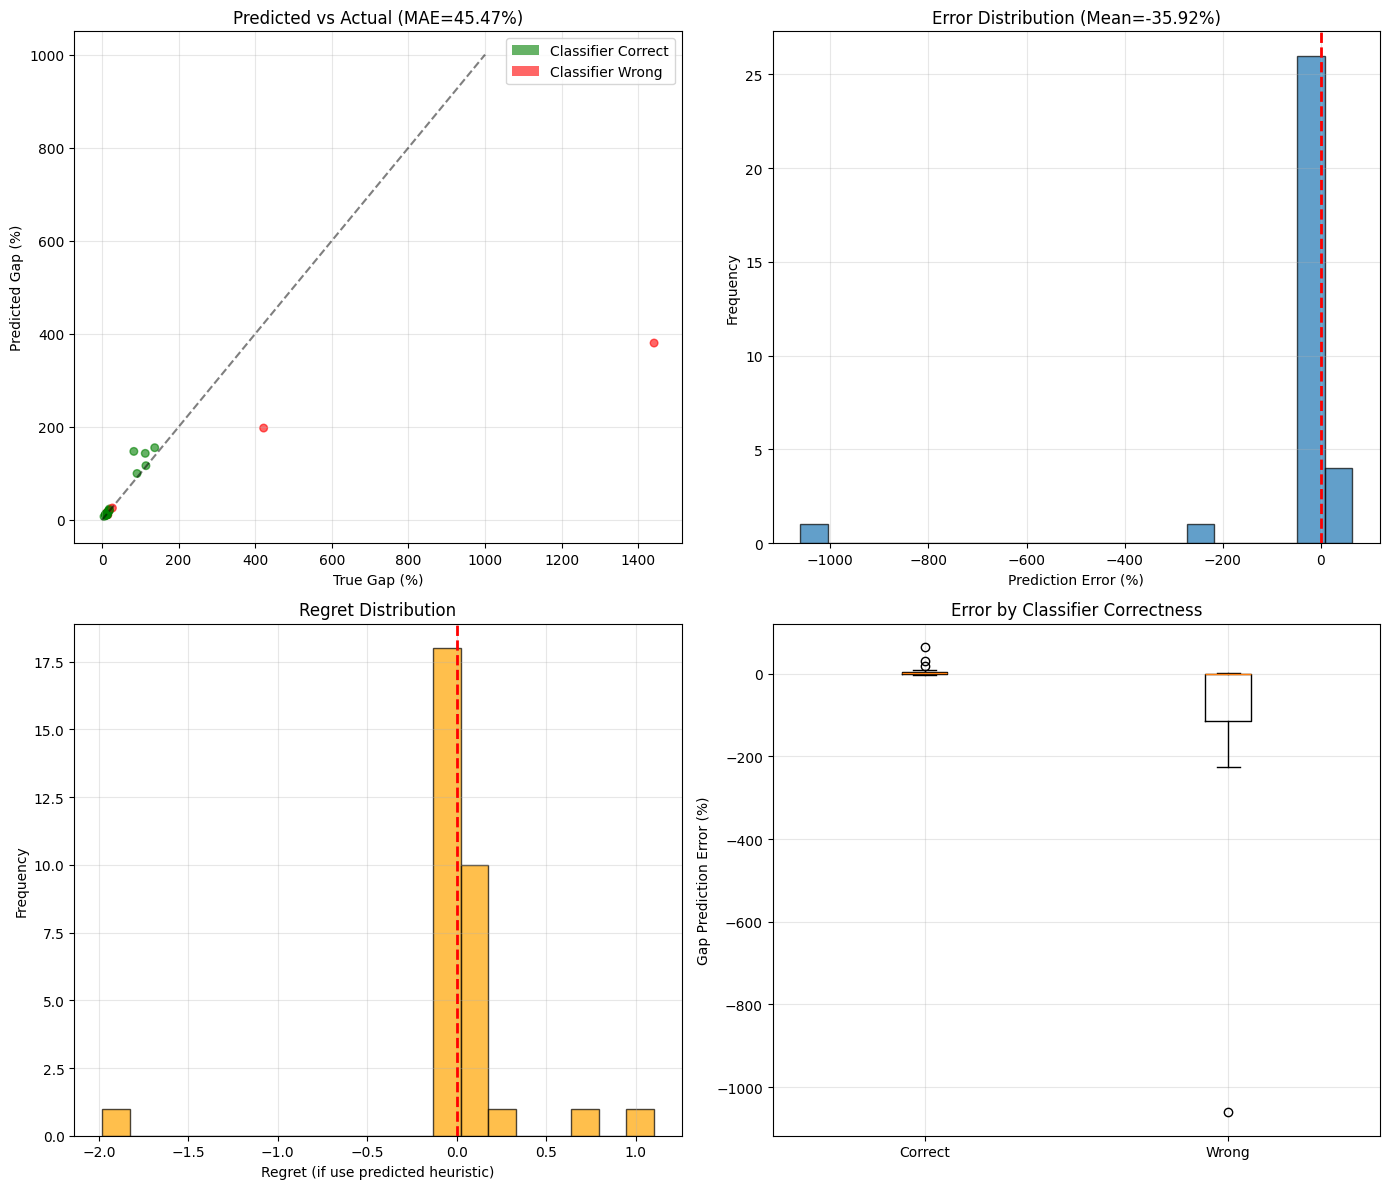


FINAL SUMMARY

INTEGRATED TWO-STAGE PIPELINE RESULTS
Test Instances: 32

STAGE 1: BEST HEURISTIC CLASSIFIER
  - Accuracy: 78.12%
  - Correct: 25/32

STAGE 2: OPTIMALITY GAP REGRESSOR
  - MAE: 45.47 percentage points
  - RMSE: 192.19
  - R² (log scale): 0.9269
  - Within ±10%: 84.38%
  - Within ±20%: 87.50%
  - Within ±30%: 87.50%

COMBINED PERFORMANCE
  - Average Regret if using predicted heuristic: 0.0234
  - Median Regret: 0.0200



In [ ]:
# ============================================
# INTEGRATED TWO-STAGE PIPELINE
# Stage 1: Predict Best Heuristic (Random Forest)
# Stage 2: Predict Optimality Gap for Predicted Heuristic
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("INTEGRATED TWO-STAGE PIPELINE")
print("Stage 1: Best Heuristic Classifier")
print("Stage 2: Optimality Gap Regressor (using predicted heuristic)")
print("="*80)

# ============================================
# PART 1: LOAD AND PREPARE DATA
# ============================================
CSV_PATH = "/content/drive/MyDrive/Dataframe/Dataset.csv"
df = pd.read_csv(CSV_PATH)

RUNTIME_CAP = 600_000
EPS = 0.05

# Define feasibility and best heuristic
df["feasible"] = df["runtime_ms"] <= RUNTIME_CAP
df["best_feasible_cost"] = (
    df[df["feasible"]]
    .groupby("file")["cost"]
    .transform("min")
)
df["is_best"] = (
    df["feasible"] &
    (df["cost"] <= (1 + EPS) * df["best_feasible_cost"])
)

# Get best heuristic per instance
best_rows = (
    df[df["is_best"]]
    .sort_values(["file", "cost"])
    .groupby("file")
    .first()
    .reset_index()
)

# Instance features (same for both models)
instance_features = [
    "n", "min_edge_weight", "max_edge_weight", "std_edge_weight",
    "cv_edge_weight", "edge_weight_skewness", "pct_short_edges",
    "triangle_violation_rate", "avg_violation_magnitude",
    "mst_weight", "nn_cost_over_mst", "type"
]

numeric_features = [f for f in instance_features if f != "type"]
categorical_features = ["type"]

print(f"Total instances: {len(best_rows)}")
print(f"Total rows in full dataset: {len(df)}")

# ============================================
# PART 2: STAGE 1 - BEST HEURISTIC CLASSIFIER
# ============================================
print("\n" + "="*60)
print("STAGE 1: Training Best Heuristic Classifier")
print("="*60)

# Prepare data for classifier
X_class = best_rows[instance_features]
y_class = best_rows["heuristic"]

# Split data (same random_state for reproducibility)
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.2, random_state=1, stratify=y_class
)

# Preprocessing for classifier
preprocess_class = ColumnTransformer([
    ("num", "passthrough", numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

# Random Forest Classifier
rf_classifier = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    random_state=1,
    n_jobs=-1
)

pipeline_class = Pipeline([
    ("preprocess", preprocess_class),
    ("classifier", rf_classifier)
])

# Train classifier
pipeline_class.fit(X_train_class, y_train_class)

# Predict on test set
y_pred_class = pipeline_class.predict(X_test_class)

# Classifier performance
class_accuracy = (y_pred_class == y_test_class).mean()
print(f"Classifier Accuracy: {class_accuracy:.4f}")

# Store test instance info
test_files = best_rows.loc[X_test_class.index, "file"].values
test_instances = pd.DataFrame({
    'file': test_files,
    'true_heuristic': y_test_class.values,
    'predicted_heuristic': y_pred_class
})

# ============================================
# PART 3: PREPARE DATA FOR STAGE 2 (GAP REGRESSOR)
# ============================================
print("\n" + "="*60)
print("STAGE 2: Preparing Optimality Gap Regressor")
print("="*60)

# Clean data for gap regression (remove rows with missing optimality_gap)
df_gap = df.dropna(subset=['optimality_gap']).copy()

# Apply log transformation to optimality_gap
df_gap['gap_log'] = np.log1p(df_gap['optimality_gap'])

# Features for gap model: instance features + heuristic
gap_feature_cols = instance_features + ['heuristic']
X_gap = df_gap[gap_feature_cols]
y_gap = df_gap['gap_log']

# Split gap data by file to prevent leakage
unique_files_gap = df_gap['file'].unique()
train_files_gap, test_files_gap = train_test_split(
    unique_files_gap, test_size=0.2, random_state=1
)

train_mask_gap = df_gap['file'].isin(train_files_gap)
test_mask_gap = df_gap['file'].isin(test_files_gap)

X_train_gap, X_test_gap = X_gap[train_mask_gap], X_gap[test_mask_gap]
y_train_gap, y_test_gap = y_gap[train_mask_gap], y_gap[test_mask_gap]

print(f"Gap model training rows: {len(X_train_gap)}")
print(f"Gap model test rows: {len(X_test_gap)}")

# Preprocessing for gap model (includes heuristic!)
gap_numeric = [f for f in instance_features if f != "type"]
gap_categorical = ["type", "heuristic"]  # ← Includes heuristic!

preprocess_gap = ColumnTransformer([
    ("num", StandardScaler(), gap_numeric),  # Scale for regression
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), gap_categorical)
])

# Random Forest Regressor for gaps
rf_regressor = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    random_state=1,
    n_jobs=-1
)

pipeline_gap = Pipeline([
    ("preprocess", preprocess_gap),
    ("regressor", rf_regressor)
])

# Train gap regressor
pipeline_gap.fit(X_train_gap, y_train_gap)

print("✓ Gap regressor trained successfully")

# ============================================
# PART 4: INTEGRATED PREDICTION ON TEST INSTANCES
# ============================================
print("\n" + "="*60)
print("INTEGRATED PREDICTION ON TEST INSTANCES")
print("="*60)

integrated_results = []

for idx, row in test_instances.iterrows():
    file = row['file']
    true_heuristic = row['true_heuristic']
    pred_heuristic = row['predicted_heuristic']

    # Get instance features for this file
    instance_row = best_rows[best_rows['file'] == file].iloc[0]

    # Create feature vector for gap prediction using PREDICTED heuristic
    gap_input = {}
    for feat in instance_features:
        gap_input[feat] = instance_row[feat]
    gap_input['heuristic'] = pred_heuristic  # Use PREDICTED heuristic!

    # Convert to DataFrame for prediction
    gap_df = pd.DataFrame([gap_input])

    # Predict gap (on log scale)
    pred_gap_log = pipeline_gap.predict(gap_df)[0]
    pred_gap = np.expm1(pred_gap_log)

    # Get true gap for the predicted heuristic (if available)
    true_gap_row = df_gap[(df_gap['file'] == file) &
                          (df_gap['heuristic'] == pred_heuristic)]

    if len(true_gap_row) > 0:
        true_gap = true_gap_row['optimality_gap'].iloc[0]
        true_gap_log = true_gap_row['gap_log'].iloc[0]
    else:
        true_gap = np.nan
        true_gap_log = np.nan

    # Get true gap for the actual best heuristic
    true_best_row = df_gap[(df_gap['file'] == file) &
                           (df_gap['heuristic'] == true_heuristic)]
    true_best_gap = true_best_row['optimality_gap'].iloc[0] if len(true_best_row) > 0 else np.nan

    integrated_results.append({
        'file': file,
        'true_heuristic': true_heuristic,
        'predicted_heuristic': pred_heuristic,
        'classifier_correct': true_heuristic == pred_heuristic,
        'predicted_gap': pred_gap,
        'true_gap_pred_heuristic': true_gap,
        'true_best_gap': true_best_gap,
        'gap_error': pred_gap - true_gap if not np.isnan(true_gap) else np.nan,
        'regret_if_use_pred': (pred_gap - true_best_gap) / 100 if not np.isnan(true_best_gap) else np.nan
    })

integrated_df = pd.DataFrame(integrated_results)

# ============================================
# PART 5: EVALUATE INTEGRATED PIPELINE
# ============================================
print("\n" + "="*60)
print("INTEGRATED PIPELINE PERFORMANCE")
print("="*60)

# Filter out rows with missing true gaps
valid_results = integrated_df.dropna(subset=['true_gap_pred_heuristic'])

if len(valid_results) > 0:
    # Gap prediction metrics
    gap_mae = mean_absolute_error(valid_results['true_gap_pred_heuristic'],
                                   valid_results['predicted_gap'])
    gap_rmse = np.sqrt(mean_squared_error(valid_results['true_gap_pred_heuristic'],
                                          valid_results['predicted_gap']))

    # Log-scale metrics
    true_log = np.log1p(valid_results['true_gap_pred_heuristic'])
    pred_log = np.log1p(valid_results['predicted_gap'])
    r2_log = r2_score(true_log, pred_log)

    print(f"\n📊 Gap Prediction Performance (for predicted heuristics):")
    print(f"   MAE:  {gap_mae:.2f} percentage points")
    print(f"   RMSE: {gap_rmse:.2f}")
    print(f"   R² (log scale): {r2_log:.4f}")

    # Classification accuracy
    class_acc = valid_results['classifier_correct'].mean()
    print(f"\n📊 Classifier Accuracy on these instances: {class_acc:.4f}")

    # Combined metric: How often is predicted gap within X% of true?
    for threshold in [10, 20, 30]:
        within_threshold = (np.abs(valid_results['gap_error']) <= threshold).mean()
        print(f"   Predictions within ±{threshold}%: {within_threshold:.2%}")

# ============================================
# PART 6: DETAILED RESULTS TABLE
# ============================================
print("\n" + "="*80)
print("DETAILED INTEGRATED RESULTS")
print("="*80)

# Sort by classification correctness then gap error
display_df = valid_results.sort_values(['classifier_correct', 'gap_error'],
                                       ascending=[False, True])

print("\n📋 TEST INSTANCE RESULTS:")
print("-"*100)
print(f"{'File':<25} {'True Best':<12} {'Pred Best':<12} {'Correct':<8} "
      f"{'Pred Gap':<12} {'True Gap':<12} {'Error':<10}")
print("-"*100)

for _, row in display_df.iterrows():
    correct_marker = "✓" if row['classifier_correct'] else "✗"
    print(f"{row['file']:<25} {row['true_heuristic']:<12} "
          f"{row['predicted_heuristic']:<12} {correct_marker:<8} "
          f"{row['predicted_gap']:<12.2f} {row['true_gap_pred_heuristic']:<12.2f} "
          f"{row['gap_error']:<10.2f}")

# ============================================
# PART 7: FAILURE ANALYSIS
# ============================================
print("\n" + "="*60)
print("FAILURE ANALYSIS")
print("="*60)

# Cases where classifier was wrong
wrong_class = valid_results[~valid_results['classifier_correct']]
if len(wrong_class) > 0:
    print(f"\n🔴 Classifier Wrong ({len(wrong_class)} instances):")
    for _, row in wrong_class.iterrows():
        print(f"   {row['file']}: True={row['true_heuristic']}, "
              f"Pred={row['predicted_heuristic']}, "
              f"Gap error={row['gap_error']:.2f}%")
else:
    print("\n✅ Classifier correct on all instances!")

# Cases with large gap prediction errors (>30%)
large_errors = valid_results[np.abs(valid_results['gap_error']) > 30]
if len(large_errors) > 0:
    print(f"\n🟡 Large Gap Errors (>30%):")
    for _, row in large_errors.iterrows():
        print(f"   {row['file']}: Pred={row['predicted_gap']:.2f}%, "
              f"True={row['true_gap_pred_heuristic']:.2f}%, "
              f"Error={row['gap_error']:.2f}%")

# ============================================
# PART 8: VISUALIZATIONS
# ============================================
print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Predicted vs Actual Gaps
ax = axes[0, 0]
ax.scatter(valid_results['true_gap_pred_heuristic'],
           valid_results['predicted_gap'],
           alpha=0.6, s=30, c=valid_results['classifier_correct'].map({True: 'green', False: 'red'}))
ax.plot([0, 1000], [0, 1000], 'k--', alpha=0.5)
ax.set_xlabel('True Gap (%)')
ax.set_ylabel('Predicted Gap (%)')
ax.set_title(f'Predicted vs Actual (MAE={gap_mae:.2f}%)')
ax.grid(True, alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', alpha=0.6, label='Classifier Correct'),
                   Patch(facecolor='red', alpha=0.6, label='Classifier Wrong')]
ax.legend(handles=legend_elements)

# Plot 2: Error Distribution
ax = axes[0, 1]
ax.hist(valid_results['gap_error'].dropna(), bins=20, edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Prediction Error (%)')
ax.set_ylabel('Frequency')
ax.set_title(f'Error Distribution (Mean={valid_results["gap_error"].mean():.2f}%)')
ax.grid(True, alpha=0.3)

# Plot 3: Regret if using predicted heuristic
ax = axes[1, 0]
regret_data = valid_results['regret_if_use_pred'].dropna()
if len(regret_data) > 0:
    ax.hist(regret_data, bins=20, edgecolor='black', alpha=0.7, color='orange')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Regret (if use predicted heuristic)')
    ax.set_ylabel('Frequency')
    ax.set_title('Regret Distribution')
    ax.grid(True, alpha=0.3)

# Plot 4: Classifier Correct vs Gap Error
ax = axes[1, 1]
correct_data = [valid_results[valid_results['classifier_correct']]['gap_error'].dropna(),
                valid_results[~valid_results['classifier_correct']]['gap_error'].dropna()]
ax.boxplot(correct_data, labels=['Correct', 'Wrong'])
ax.set_ylabel('Gap Prediction Error (%)')
ax.set_title('Error by Classifier Correctness')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# PART 9: SUMMARY STATISTICS
# ============================================
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

print(f"""
INTEGRATED TWO-STAGE PIPELINE RESULTS
=======================================
Test Instances: {len(valid_results)}

STAGE 1: BEST HEURISTIC CLASSIFIER
  - Accuracy: {class_acc:.2%}
  - Correct: {valid_results['classifier_correct'].sum()}/{len(valid_results)}

STAGE 2: OPTIMALITY GAP REGRESSOR
  - MAE: {gap_mae:.2f} percentage points
  - RMSE: {gap_rmse:.2f}
  - R² (log scale): {r2_log:.4f}
  - Within ±10%: {(np.abs(valid_results['gap_error']) <= 10).mean():.2%}
  - Within ±20%: {(np.abs(valid_results['gap_error']) <= 20).mean():.2%}
  - Within ±30%: {(np.abs(valid_results['gap_error']) <= 30).mean():.2%}

COMBINED PERFORMANCE
  - Average Regret if using predicted heuristic: {valid_results['regret_if_use_pred'].mean():.4f}
  - Median Regret: {valid_results['regret_if_use_pred'].median():.4f}
""")


FEATURE IMPORTANCE ANALYSIS

Top 20 most important features:
                feature  importance
       nn_cost_over_mst    0.683699
triangle_violation_rate    0.086182
    heuristic_Insertion    0.082389
         cv_edge_weight    0.042129
           heuristic_CH    0.027029
avg_violation_magnitude    0.024805
           heuristic_NN    0.016694
                      n    0.007917
             mst_weight    0.006981
   edge_weight_skewness    0.005603
       heuristic_Greedy    0.004736
        pct_short_edges    0.004271
        std_edge_weight    0.003905
        max_edge_weight    0.001763
        min_edge_weight    0.001481
          type_Explicit    0.000224
            type_EUC_2D    0.000152
               type_Geo    0.000041


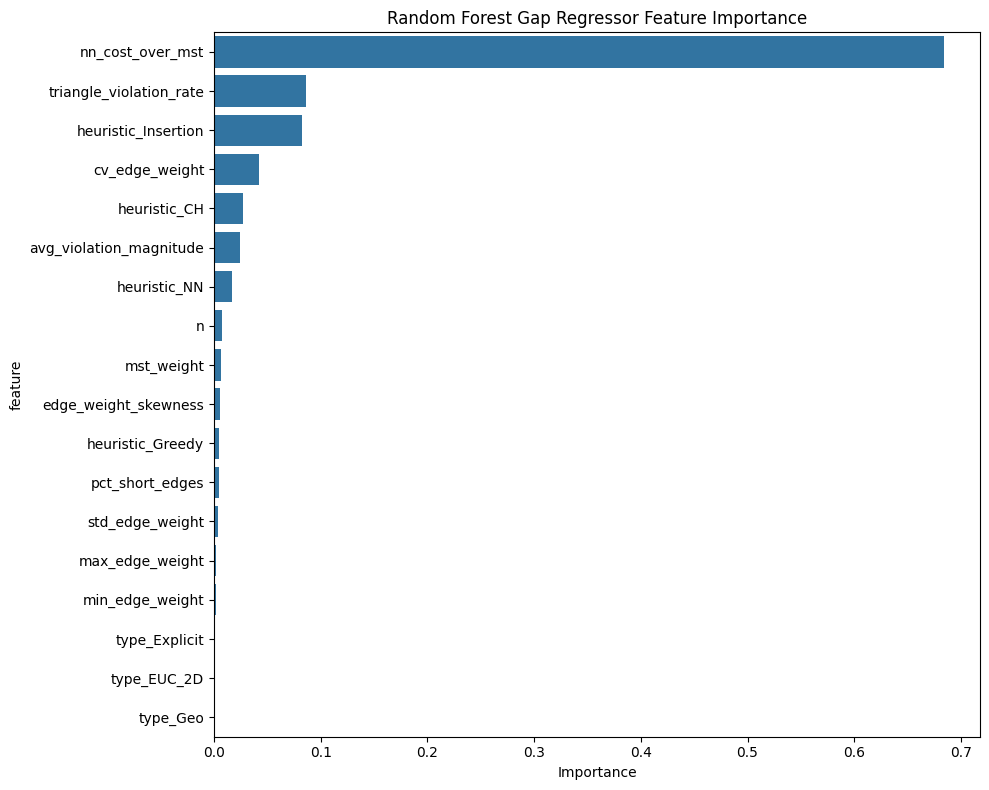


✅ Feature importance saved to 'rf_gap_importance.csv'


In [ ]:
# ============================================
# FEATURE IMPORTANCE FOR GAP REGRESSOR
# ============================================
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get the trained regressor from the pipeline
if 'pipeline_gap' in globals() and hasattr(pipeline_gap, 'named_steps'):
    rf_model = pipeline_gap.named_steps["regressor"]

    # Get feature names after preprocessing
    num_features = [f for f in instance_features if f != "type"]
    cat_encoder = preprocess_gap.named_transformers_["cat"]
    cat_feature_names = cat_encoder.get_feature_names_out(["type", "heuristic"])
    all_feature_names = np.concatenate([num_features, cat_feature_names])

    # Get importances
    importances = rf_model.feature_importances_

    # Create DataFrame
    importance_df = pd.DataFrame({
        'feature': all_feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)

    print("\nTop 20 most important features:")
    print(importance_df.head(20).to_string(index=False))

    # Plot
    plt.figure(figsize=(10, 8))
    sns.barplot(data=importance_df.head(20), y='feature', x='importance')
    plt.title('Random Forest Gap Regressor Feature Importance')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

    # Save to CSV
    importance_df.to_csv('rf_gap_importance.csv', index=False)
    print("\n✅ Feature importance saved to 'rf_gap_importance.csv'")
else:
    print("\n⚠️ Gap regressor pipeline not found. Make sure you ran the full script.")

##XGBoost

INTEGRATED XGBOOST TWO-STAGE PIPELINE WITH CONFORMAL PREDICTION
Stage 1: Best Heuristic Classifier (XGBoost)
Stage 2: Optimality Gap Regressor with 90% Prediction Intervals (Conformal)
Total instances: 160
Total rows in full dataset: 640

STAGE 1: Training XGBoost Best Heuristic Classifier
XGBoost Classifier Accuracy: 0.7188

STAGE 2: Preparing XGBoost Gap Regressor with Conformal Prediction

Optimality gap statistics:
  Min: 1.81%
  Max: 5496.41%
  Mean: 284.36%
  Median: 20.72%

Gap model training rows: 396
Gap model calibration rows: 100
Gap model test rows: 128

Training XGBoost gap regressor...

Conformal score (q_90%): 0.6784
Gap Regressor Hold-out Performance:
  MAE: 60.80%
  R² (log): 0.9467
  Interval coverage: 94.53%

INTEGRATED PREDICTION ON TEST INSTANCES (WITH CONFORMAL INTERVALS)

INTEGRATED PIPELINE PERFORMANCE

📊 Gap Prediction Performance (for predicted heuristics):
   MAE:  23.40 percentage points
   RMSE: 70.53
   R² (log scale): 0.9336

📊 XGBoost Classifier Accuracy

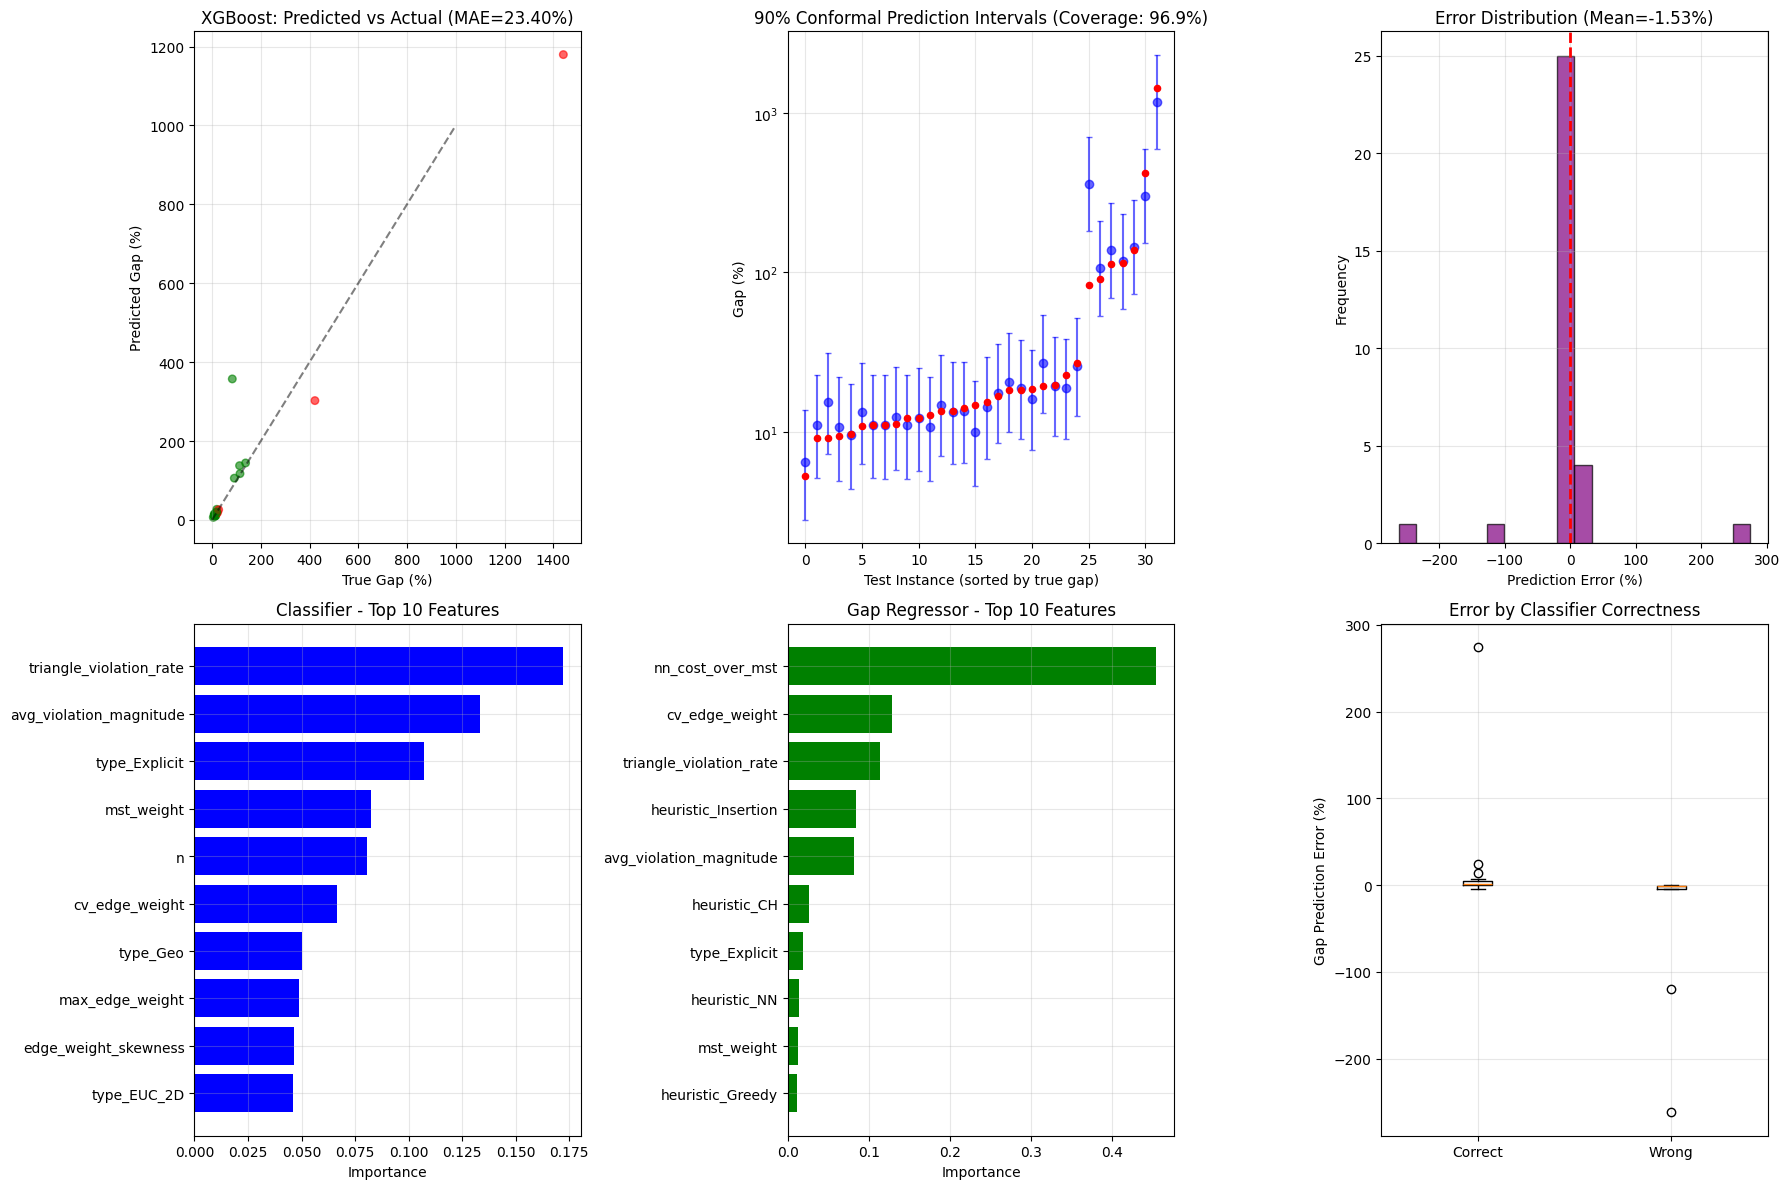


FINAL SUMMARY - XGBOOST WITH CONFORMAL PREDICTION

INTEGRATED XGBOOST TWO-STAGE PIPELINE WITH CONFORMAL PREDICTION
Test Instances: 32/32 (with gap data)

STAGE 1: BEST HEURISTIC CLASSIFIER
  - XGBoost Classifier Accuracy: 71.88%
  - Correct: 23/32

STAGE 2: OPTIMALITY GAP REGRESSOR (with Conformal Prediction)
  - MAE: 23.40 percentage points
  - RMSE: 70.53
  - R² (log scale): 0.9336
  - Within ±10%: 84.38%
  - Within ±20%: 87.50%
  - Within ±30%: 90.62%
  - Within ±50%: 90.62%

CONFORMAL PREDICTION (90% Intervals)
  - Conformal score (q_0.9): 0.6784 (log scale)
  - Empirical coverage: 96.88%
  - Mean interval width: 125.38 percentage points
  - Median interval width: 23.52 percentage points

COMBINED PERFORMANCE
  - Average Regret if using predicted heuristic: 0.3723
  - Median Regret: 0.0243
  - Max Regret: 9.0965


✅ Results saved to:
   - xgboost_conformal_integrated_results.csv
   - xgboost_classifier_importance.csv
   - xgboost_gap_regressor_importance.csv

📊 Conformal score (fo

In [ ]:
# ============================================
# INTEGRATED XGBOOST TWO-STAGE PIPELINE WITH CONFORMAL PREDICTION
# Stage 1: Predict Best Heuristic (XGBoost Classifier)
# Stage 2: Predict Optimality Gap with 90% Prediction Intervals (Conformal Prediction)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBClassifier, XGBRegressor
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("INTEGRATED XGBOOST TWO-STAGE PIPELINE WITH CONFORMAL PREDICTION")
print("Stage 1: Best Heuristic Classifier (XGBoost)")
print("Stage 2: Optimality Gap Regressor with 90% Prediction Intervals (Conformal)")
print("="*80)

# ============================================
# PART 1: LOAD AND PREPARE DATA
# ============================================
CSV_PATH = "/content/drive/MyDrive/Dataframe/Dataset.csv"
df = pd.read_csv(CSV_PATH)

RUNTIME_CAP = 600_000
EPS = 0.05

df["feasible"] = df["runtime_ms"] <= RUNTIME_CAP
df["best_feasible_cost"] = (
    df[df["feasible"]]
    .groupby("file")["cost"]
    .transform("min")
)
df["is_best"] = (
    df["feasible"] &
    (df["cost"] <= (1 + EPS) * df["best_feasible_cost"])
)

best_rows = (
    df[df["is_best"]]
    .sort_values(["file", "cost"])
    .groupby("file")
    .first()
    .reset_index(drop=False)
)

# Instance features (same for both models)
instance_features = [
    "n", "min_edge_weight", "max_edge_weight", "std_edge_weight",
    "cv_edge_weight", "edge_weight_skewness", "pct_short_edges",
    "triangle_violation_rate", "avg_violation_magnitude",
    "mst_weight", "nn_cost_over_mst", "type"
]

numeric_features = [f for f in instance_features if f != "type"]
categorical_features = ["type"]

print(f"Total instances: {len(best_rows)}")
print(f"Total rows in full dataset: {len(df)}")

# ============================================
# PART 2: STAGE 1 - XGBOOST BEST HEURISTIC CLASSIFIER
# ============================================
print("\n" + "="*60)
print("STAGE 1: Training XGBoost Best Heuristic Classifier")
print("="*60)

# Prepare data for classifier
X_class = best_rows[instance_features]
y_class = best_rows["heuristic"]

# Encode target
label_encoder = LabelEncoder()
y_class_encoded = label_encoder.fit_transform(y_class)

# Split data (same random_state=1 for reproducibility)
X_train_class, X_test_class, y_train_class, y_test_class, files_train, files_test = train_test_split(
    X_class, y_class_encoded, best_rows["file"],
    test_size=0.2,
    random_state=1,
    stratify=y_class_encoded
)

# Preprocessing for classifier
preprocess_class = ColumnTransformer([
    ("num", "passthrough", numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

# XGBoost Classifier
xgb_classifier = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=1,
    n_jobs=-1
)

pipeline_class = Pipeline([
    ("preprocess", preprocess_class),
    ("classifier", xgb_classifier)
])

# Train classifier
pipeline_class.fit(X_train_class, y_train_class)

# Predict on test set
y_pred_class_encoded = pipeline_class.predict(X_test_class)
y_pred_class = label_encoder.inverse_transform(y_pred_class_encoded)
y_true_class = label_encoder.inverse_transform(y_test_class)

# Classifier performance
class_accuracy = (y_pred_class == y_true_class).mean()
print(f"XGBoost Classifier Accuracy: {class_accuracy:.4f}")

# Store test instance info
test_instances = pd.DataFrame({
    'file': files_test.values,
    'true_heuristic': y_true_class,
    'predicted_heuristic': y_pred_class
})

# ============================================
# PART 3: PREPARE DATA FOR STAGE 2 (GAP REGRESSOR WITH CONFORMAL PREDICTION)
# ============================================
print("\n" + "="*60)
print("STAGE 2: Preparing XGBoost Gap Regressor with Conformal Prediction")
print("="*60)

# Clean data for gap regression (remove rows with missing optimality_gap)
df_gap = df.dropna(subset=['optimality_gap']).copy()

# Apply log transformation to optimality_gap
df_gap['gap_log'] = np.log1p(df_gap['optimality_gap'])

print(f"\nOptimality gap statistics:")
print(f"  Min: {df_gap['optimality_gap'].min():.2f}%")
print(f"  Max: {df_gap['optimality_gap'].max():.2f}%")
print(f"  Mean: {df_gap['optimality_gap'].mean():.2f}%")
print(f"  Median: {df_gap['optimality_gap'].median():.2f}%")

# Features for gap model: instance features + heuristic
gap_feature_cols = instance_features + ['heuristic']
X_gap = df_gap[gap_feature_cols]
y_gap = df_gap['gap_log']

# Split gap data by file to prevent leakage
unique_files_gap = df_gap['file'].unique()
train_files_gap, test_files_gap = train_test_split(
    unique_files_gap, test_size=0.2, random_state=1
)

train_mask_gap = df_gap['file'].isin(train_files_gap)
test_mask_gap = df_gap['file'].isin(test_files_gap)

# For conformal prediction, split training data into proper training and calibration
X_train_gap_full = X_gap[train_mask_gap]
y_train_gap_full = y_gap[train_mask_gap]

# Split training into proper training (80%) and calibration (20%)
X_train_proper, X_cal, y_train_proper, y_cal = train_test_split(
    X_train_gap_full, y_train_gap_full,
    test_size=0.2, random_state=1
)

X_test_gap = X_gap[test_mask_gap]
y_test_gap = y_gap[test_mask_gap]

print(f"\nGap model training rows: {len(X_train_proper)}")
print(f"Gap model calibration rows: {len(X_cal)}")
print(f"Gap model test rows: {len(X_test_gap)}")

# Preprocessing for gap model (includes heuristic!)
gap_numeric = [f for f in instance_features if f != "type"]
gap_categorical = ["type", "heuristic"]  # Includes heuristic!

preprocess_gap = ColumnTransformer([
    ("num", StandardScaler(), gap_numeric),  # Scale for regression
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), gap_categorical)
])

# XGBoost Regressor for gaps
xgb_regressor = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,
    reg_alpha=0.1,
    objective='reg:squarederror',
    random_state=1,
    n_jobs=-1
)

pipeline_gap = Pipeline([
    ("preprocess", preprocess_gap),
    ("regressor", xgb_regressor)
])

# Train gap regressor on proper training set
print("\nTraining XGBoost gap regressor...")
X_train_proper_processed = preprocess_gap.fit_transform(X_train_proper)
X_cal_processed = preprocess_gap.transform(X_cal)

pipeline_gap.fit(X_train_proper, y_train_proper)

# Get predictions on calibration set
y_cal_pred_log = pipeline_gap.predict(X_cal)

# Compute absolute residuals on calibration set
residuals = np.abs(y_cal - y_cal_pred_log)

# Find the 90th percentile of residuals (for 90% confidence intervals)
alpha = 0.1  # 90% prediction intervals
conformal_score = np.quantile(residuals, 1 - alpha)

print(f"\nConformal score (q_{1-alpha:.0%}): {conformal_score:.4f}")

# Evaluate gap regressor on its own test set
X_test_gap_processed = preprocess_gap.transform(X_test_gap)
y_test_pred_log = pipeline_gap.predict(X_test_gap)
y_test_pred = np.expm1(y_test_pred_log)
y_test_orig = np.expm1(y_test_gap)

# Create prediction intervals
y_test_lower_log = y_test_pred_log - conformal_score
y_test_upper_log = y_test_pred_log + conformal_score
y_test_lower = np.expm1(np.maximum(y_test_lower_log, 0))
y_test_upper = np.expm1(y_test_upper_log)

gap_mae_holdout = mean_absolute_error(y_test_orig, y_test_pred)
gap_r2_holdout = r2_score(y_test_gap, y_test_pred_log)

print(f"Gap Regressor Hold-out Performance:")
print(f"  MAE: {gap_mae_holdout:.2f}%")
print(f"  R² (log): {gap_r2_holdout:.4f}")

# Evaluate interval coverage on hold-out test set
coverage_holdout = np.mean((y_test_orig >= y_test_lower) & (y_test_orig <= y_test_upper))
print(f"  Interval coverage: {coverage_holdout*100:.2f}%")

# ============================================
# PART 4: INTEGRATED PREDICTION ON TEST INSTANCES WITH CONFORMAL INTERVALS
# ============================================
print("\n" + "="*60)
print("INTEGRATED PREDICTION ON TEST INSTANCES (WITH CONFORMAL INTERVALS)")
print("="*60)

integrated_results = []

for idx, row in test_instances.iterrows():
    file = row['file']
    true_heuristic = row['true_heuristic']
    pred_heuristic = row['predicted_heuristic']

    # Get instance features for this file
    instance_row = best_rows[best_rows['file'] == file].iloc[0]

    # Create feature vector for gap prediction using PREDICTED heuristic
    gap_input = {}
    for feat in instance_features:
        gap_input[feat] = instance_row[feat]
    gap_input['heuristic'] = pred_heuristic  # Use PREDICTED heuristic!

    # Convert to DataFrame for prediction
    gap_df = pd.DataFrame([gap_input])

    # Predict gap (on log scale)
    pred_gap_log = pipeline_gap.predict(gap_df)[0]
    pred_gap = np.expm1(pred_gap_log)

    # Add conformal interval
    lower_gap_log = pred_gap_log - conformal_score
    upper_gap_log = pred_gap_log + conformal_score
    lower_gap = np.expm1(max(lower_gap_log, 0))
    upper_gap = np.expm1(upper_gap_log)

    # Get true gap for the predicted heuristic (if available)
    true_gap_row = df_gap[(df_gap['file'] == file) &
                          (df_gap['heuristic'] == pred_heuristic)]

    if len(true_gap_row) > 0:
        true_gap = true_gap_row['optimality_gap'].iloc[0]
        true_gap_log = true_gap_row['gap_log'].iloc[0]
    else:
        true_gap = np.nan
        true_gap_log = np.nan

    # Get true gap for the actual best heuristic
    true_best_row = df_gap[(df_gap['file'] == file) &
                           (df_gap['heuristic'] == true_heuristic)]
    true_best_gap = true_best_row['optimality_gap'].iloc[0] if len(true_best_row) > 0 else np.nan

    integrated_results.append({
        'file': file,
        'true_heuristic': true_heuristic,
        'predicted_heuristic': pred_heuristic,
        'classifier_correct': true_heuristic == pred_heuristic,
        'predicted_gap': pred_gap,
        'lower_gap': lower_gap,
        'upper_gap': upper_gap,
        'interval_width': upper_gap - lower_gap,
        'true_gap_pred_heuristic': true_gap,
        'true_best_gap': true_best_gap,
        'gap_error': pred_gap - true_gap if not np.isnan(true_gap) else np.nan,
        'in_interval': (true_gap >= lower_gap) & (true_gap <= upper_gap) if not np.isnan(true_gap) else False,
        'regret_if_use_pred': (pred_gap - true_best_gap) / 100 if not np.isnan(true_best_gap) else np.nan
    })

integrated_df = pd.DataFrame(integrated_results)

# ============================================
# PART 5: EVALUATE INTEGRATED PIPELINE
# ============================================
print("\n" + "="*60)
print("INTEGRATED PIPELINE PERFORMANCE")
print("="*60)

# Filter out rows with missing true gaps
valid_results = integrated_df.dropna(subset=['true_gap_pred_heuristic'])

if len(valid_results) > 0:
    # Gap prediction metrics
    gap_mae = mean_absolute_error(valid_results['true_gap_pred_heuristic'],
                                   valid_results['predicted_gap'])
    gap_rmse = np.sqrt(mean_squared_error(valid_results['true_gap_pred_heuristic'],
                                          valid_results['predicted_gap']))

    # Log-scale metrics
    true_log = np.log1p(valid_results['true_gap_pred_heuristic'])
    pred_log = np.log1p(valid_results['predicted_gap'])
    r2_log = r2_score(true_log, pred_log)

    print(f"\n📊 Gap Prediction Performance (for predicted heuristics):")
    print(f"   MAE:  {gap_mae:.2f} percentage points")
    print(f"   RMSE: {gap_rmse:.2f}")
    print(f"   R² (log scale): {r2_log:.4f}")

    # Classification accuracy
    class_acc = valid_results['classifier_correct'].mean()
    print(f"\n📊 XGBoost Classifier Accuracy: {class_acc:.4f}")

    # Interval coverage
    interval_coverage = valid_results['in_interval'].mean()
    print(f"\n📊 90% Conformal Prediction Interval Coverage: {interval_coverage*100:.2f}%")
    print(f"   Mean interval width: {valid_results['interval_width'].mean():.2f}%")
    print(f"   Median interval width: {valid_results['interval_width'].median():.2f}%")

    # Combined metric: How often is predicted gap within X% of true?
    print(f"\n📊 Prediction Accuracy:")
    for threshold in [10, 20, 30, 50]:
        within_threshold = (np.abs(valid_results['gap_error']) <= threshold).mean()
        print(f"   Within ±{threshold}%: {within_threshold:.2%}")

# ============================================
# PART 6: DETAILED RESULTS TABLE WITH CONFORMAL INTERVALS
# ============================================
print("\n" + "="*80)
print("DETAILED INTEGRATED XGBOOST RESULTS (WITH 90% CONFORMAL INTERVALS)")
print("="*80)

# Sort by classification correctness then gap error
display_df = valid_results.sort_values(['classifier_correct', 'gap_error'],
                                       ascending=[False, True])

print("\n📋 TEST INSTANCE RESULTS:")
print("-"*130)
print(f"{'File':<25} {'True Best':<12} {'Pred Best':<12} {'Correct':<8} "
      f"{'Pred Gap':<12} {'90% Interval':<20} {'True Gap':<12} {'In Int':<8}")
print("-"*130)

for _, row in display_df.iterrows():
    correct_marker = "✓" if row['classifier_correct'] else "✗"
    interval_str = f"[{row['lower_gap']:.1f}, {row['upper_gap']:.1f}]"
    in_interval = "✅" if row['in_interval'] else "❌"
    print(f"{row['file']:<25} {row['true_heuristic']:<12} "
          f"{row['predicted_heuristic']:<12} {correct_marker:<8} "
          f"{row['predicted_gap']:<12.2f} {interval_str:<20} "
          f"{row['true_gap_pred_heuristic']:<12.2f} {in_interval:<8}")

# ============================================
# PART 7: FEATURE IMPORTANCE FOR BOTH MODELS
# ============================================
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Classifier feature importance
classifier = pipeline_class.named_steps["classifier"]
preprocess_class_step = pipeline_class.named_steps["preprocess"]

cat_feat_names_class = preprocess_class_step.named_transformers_["cat"].get_feature_names_out(categorical_features)
all_feat_names_class = np.concatenate([numeric_features, cat_feat_names_class])

class_importance = classifier.feature_importances_
class_imp_df = pd.DataFrame({
    'feature': all_feat_names_class,
    'importance': class_importance
}).sort_values('importance', ascending=False)

print("\n📊 XGBoost Classifier - Top 10 Features:")
print(class_imp_df.head(10).to_string(index=False))

# Regressor feature importance
regressor = pipeline_gap.named_steps["regressor"]
preprocess_gap_step = pipeline_gap.named_steps["preprocess"]

cat_feat_names_gap = preprocess_gap_step.named_transformers_["cat"].get_feature_names_out(["type", "heuristic"])
all_feat_names_gap = np.concatenate([gap_numeric, cat_feat_names_gap])

reg_importance = regressor.feature_importances_
reg_imp_df = pd.DataFrame({
    'feature': all_feat_names_gap,
    'importance': reg_importance
}).sort_values('importance', ascending=False)

print("\n📊 XGBoost Gap Regressor - Top 10 Features:")
print(reg_imp_df.head(10).to_string(index=False))

# ============================================
# PART 8: VISUALIZATIONS WITH CONFORMAL INTERVALS
# ============================================
print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Predicted vs Actual Gaps
ax = axes[0, 0]
colors = ['green' if x else 'red' for x in valid_results['classifier_correct']]
ax.scatter(valid_results['true_gap_pred_heuristic'],
           valid_results['predicted_gap'],
           alpha=0.6, s=30, c=colors)
ax.plot([0, 1000], [0, 1000], 'k--', alpha=0.5)
ax.set_xlabel('True Gap (%)')
ax.set_ylabel('Predicted Gap (%)')
ax.set_title(f'XGBoost: Predicted vs Actual (MAE={gap_mae:.2f}%)')
ax.grid(True, alpha=0.3)

# Plot 2: Prediction Intervals (Conformal)
ax = axes[0, 1]
sorted_idx = np.argsort(valid_results['true_gap_pred_heuristic'].values)
n_show = min(50, len(valid_results))
plot_idx = sorted_idx[:n_show]

for i, idx in enumerate(plot_idx):
    row = valid_results.iloc[idx]
    ax.errorbar(i, row['predicted_gap'],
                yerr=[[row['predicted_gap'] - row['lower_gap']],
                      [row['upper_gap'] - row['predicted_gap']]],
                fmt='o', capsize=2, color='blue', alpha=0.6)
    ax.scatter(i, row['true_gap_pred_heuristic'], color='red', s=20, zorder=5)

ax.set_xlabel('Test Instance (sorted by true gap)')
ax.set_ylabel('Gap (%)')
ax.set_title(f'90% Conformal Prediction Intervals (Coverage: {interval_coverage*100:.1f}%)')
ax.set_yscale('symlog')
ax.grid(True, alpha=0.3)

# Plot 3: Error Distribution
ax = axes[0, 2]
ax.hist(valid_results['gap_error'].dropna(), bins=20, edgecolor='black', alpha=0.7, color='purple')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Prediction Error (%)')
ax.set_ylabel('Frequency')
ax.set_title(f'Error Distribution (Mean={valid_results["gap_error"].mean():.2f}%)')
ax.grid(True, alpha=0.3)

# Plot 4: Classifier Feature Importance
ax = axes[1, 0]
top_class = class_imp_df.head(10)
ax.barh(range(len(top_class)), top_class['importance'].values, color='blue')
ax.set_yticks(range(len(top_class)))
ax.set_yticklabels(top_class['feature'].values)
ax.set_xlabel('Importance')
ax.set_title('Classifier - Top 10 Features')
ax.invert_yaxis()
ax.grid(True, alpha=0.3)

# Plot 5: Regressor Feature Importance
ax = axes[1, 1]
top_reg = reg_imp_df.head(10)
ax.barh(range(len(top_reg)), top_reg['importance'].values, color='green')
ax.set_yticks(range(len(top_reg)))
ax.set_yticklabels(top_reg['feature'].values)
ax.set_xlabel('Importance')
ax.set_title('Gap Regressor - Top 10 Features')
ax.invert_yaxis()
ax.grid(True, alpha=0.3)

# Plot 6: Classifier Correct vs Gap Error
ax = axes[1, 2]
correct_data = [valid_results[valid_results['classifier_correct']]['gap_error'].dropna(),
                valid_results[~valid_results['classifier_correct']]['gap_error'].dropna()]
ax.boxplot(correct_data, labels=['Correct', 'Wrong'])
ax.set_ylabel('Gap Prediction Error (%)')
ax.set_title('Error by Classifier Correctness')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# PART 9: SUMMARY STATISTICS
# ============================================
print("\n" + "="*60)
print("FINAL SUMMARY - XGBOOST WITH CONFORMAL PREDICTION")
print("="*60)

print(f"""
INTEGRATED XGBOOST TWO-STAGE PIPELINE WITH CONFORMAL PREDICTION
===============================================================
Test Instances: {len(valid_results)}/{len(test_instances)} (with gap data)

STAGE 1: BEST HEURISTIC CLASSIFIER
  - XGBoost Classifier Accuracy: {class_acc:.2%}
  - Correct: {valid_results['classifier_correct'].sum()}/{len(valid_results)}

STAGE 2: OPTIMALITY GAP REGRESSOR (with Conformal Prediction)
  - MAE: {gap_mae:.2f} percentage points
  - RMSE: {gap_rmse:.2f}
  - R² (log scale): {r2_log:.4f}
  - Within ±10%: {(np.abs(valid_results['gap_error']) <= 10).mean():.2%}
  - Within ±20%: {(np.abs(valid_results['gap_error']) <= 20).mean():.2%}
  - Within ±30%: {(np.abs(valid_results['gap_error']) <= 30).mean():.2%}
  - Within ±50%: {(np.abs(valid_results['gap_error']) <= 50).mean():.2%}

CONFORMAL PREDICTION (90% Intervals)
  - Conformal score (q_0.9): {conformal_score:.4f} (log scale)
  - Empirical coverage: {interval_coverage*100:.2f}%
  - Mean interval width: {valid_results['interval_width'].mean():.2f} percentage points
  - Median interval width: {valid_results['interval_width'].median():.2f} percentage points

COMBINED PERFORMANCE
  - Average Regret if using predicted heuristic: {valid_results['regret_if_use_pred'].mean():.4f}
  - Median Regret: {valid_results['regret_if_use_pred'].median():.4f}
  - Max Regret: {valid_results['regret_if_use_pred'].max():.4f}
""")

# ============================================
# PART 10: SAVE RESULTS
# ============================================
valid_results.to_csv('/content/drive/MyDrive/Results/RF/seed_1_XGB_results.csv', index=False)
class_imp_df.to_csv('/content/drive/MyDrive/Results/RF/seed_1_XGB_classifier_importance.csv', index=False)
reg_imp_df.to_csv('/content/drive/MyDrive/Results/RF/seed_1_XGB_regressor_importance.csv', index=False)

print("\n✅ Results saved to:")
print("   - xgboost_conformal_integrated_results.csv")
print("   - xgboost_classifier_importance.csv")
print("   - xgboost_gap_regressor_importance.csv")
print(f"\n📊 Conformal score (for 90% intervals): {conformal_score:.4f}")

INTEGRATED XGBOOST TWO-STAGE PIPELINE
Stage 1: Best Heuristic Classifier (XGBoost)
Stage 2: Optimality Gap Regressor (XGBoost)
Total instances: 160
Total rows in full dataset: 640

STAGE 1: Training XGBoost Best Heuristic Classifier
XGBoost Classifier Accuracy: 0.7188

STAGE 2: Preparing XGBoost Optimality Gap Regressor

Optimality gap statistics:
  Min: 1.81%
  Max: 5496.41%
  Mean: 284.36%
  Median: 20.72%

Gap model training rows: 496
Gap model test rows: 128

Training XGBoost gap regressor...
Gap Regressor Hold-out Performance:
  MAE: 52.33%
  R² (log): 0.9570

INTEGRATED PREDICTION ON TEST INSTANCES

INTEGRATED PIPELINE PERFORMANCE

📊 Gap Prediction Performance (for predicted heuristics):
   MAE:  18.15 percentage points
   RMSE: 60.50
   R² (log scale): 0.9796

📊 XGBoost Classifier Accuracy: 0.7188

📊 Prediction Accuracy:
   Within ±10%: 84.38%
   Within ±20%: 87.50%
   Within ±30%: 90.62%
   Within ±50%: 93.75%

DETAILED INTEGRATED XGBOOST RESULTS

📋 TEST INSTANCE RESULTS:
-----

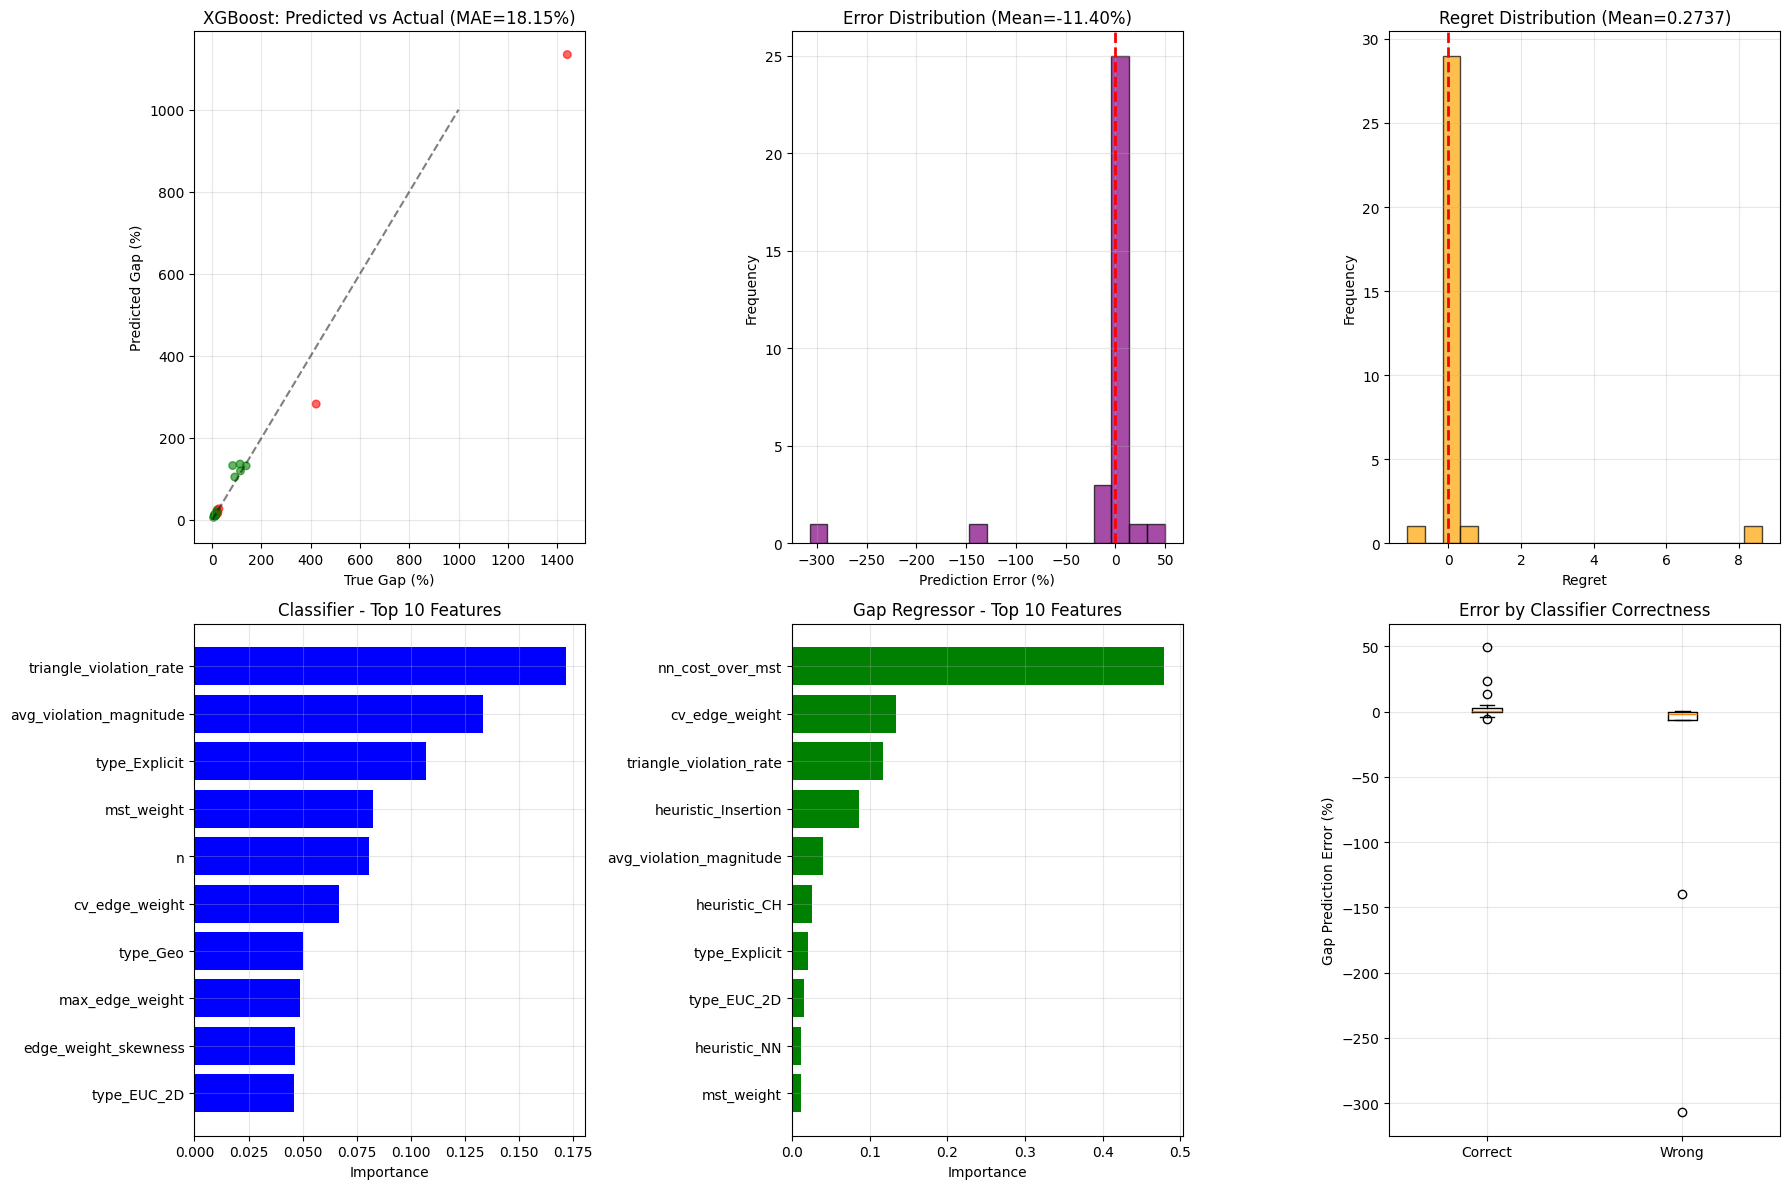


FINAL SUMMARY - XGBOOST INTEGRATED PIPELINE

INTEGRATED XGBOOST TWO-STAGE PIPELINE RESULTS
Test Instances: 32/32 (with gap data)

STAGE 1: BEST HEURISTIC CLASSIFIER
  - XGBoost Classifier Accuracy: 71.88%
  - Correct: 23/32

STAGE 2: OPTIMALITY GAP REGRESSOR
  - MAE: 18.15 percentage points
  - RMSE: 60.50
  - R² (log scale): 0.9796

PREDICTION ACCURACY:
  - Within ±10%: 84.38%
  - Within ±20%: 87.50%
  - Within ±30%: 90.62%
  - Within ±50%: 93.75%

COMBINED PERFORMANCE
  - Average Regret if using predicted heuristic: 0.2737
  - Median Regret: 0.0155
  - Max Regret: 8.6437


✅ Results saved to 'xgboost_integrated_pipeline_results.csv'


In [ ]:
# ============================================
# INTEGRATED XGBOOST TWO-STAGE PIPELINE
# Stage 1: Predict Best Heuristic (XGBoost Classifier)
# Stage 2: Predict Optimality Gap for Predicted Heuristic
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBClassifier, XGBRegressor
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("INTEGRATED XGBOOST TWO-STAGE PIPELINE")
print("Stage 1: Best Heuristic Classifier (XGBoost)")
print("Stage 2: Optimality Gap Regressor (XGBoost)")
print("="*80)

# ============================================
# PART 1: LOAD AND PREPARE DATA
# ============================================
CSV_PATH = "/content/drive/MyDrive/Dataframe/Dataset.csv"
df = pd.read_csv(CSV_PATH)

RUNTIME_CAP = 600_000
EPS = 0.05

df["feasible"] = df["runtime_ms"] <= RUNTIME_CAP
df["best_feasible_cost"] = (
    df[df["feasible"]]
    .groupby("file")["cost"]
    .transform("min")
)
df["is_best"] = (
    df["feasible"] &
    (df["cost"] <= (1 + EPS) * df["best_feasible_cost"])
)

best_rows = (
    df[df["is_best"]]
    .sort_values(["file", "cost"])
    .groupby("file")
    .first()
    .reset_index(drop=False)
)

# Instance features (same for both models)
instance_features = [
    "n", "min_edge_weight", "max_edge_weight", "std_edge_weight",
    "cv_edge_weight", "edge_weight_skewness", "pct_short_edges",
    "triangle_violation_rate", "avg_violation_magnitude",
    "mst_weight", "nn_cost_over_mst", "type"
]

numeric_features = [f for f in instance_features if f != "type"]
categorical_features = ["type"]

print(f"Total instances: {len(best_rows)}")
print(f"Total rows in full dataset: {len(df)}")

# ============================================
# PART 2: STAGE 1 - XGBOOST BEST HEURISTIC CLASSIFIER
# ============================================
print("\n" + "="*60)
print("STAGE 1: Training XGBoost Best Heuristic Classifier")
print("="*60)

# Prepare data for classifier
X_class = best_rows[instance_features]
y_class = best_rows["heuristic"]

# Encode target
label_encoder = LabelEncoder()
y_class_encoded = label_encoder.fit_transform(y_class)

# Split data (same random_state=1 for reproducibility)
X_train_class, X_test_class, y_train_class, y_test_class, files_train, files_test = train_test_split(
    X_class, y_class_encoded, best_rows["file"],
    test_size=0.2,
    random_state=1,
    stratify=y_class_encoded
)

# Preprocessing for classifier
preprocess_class = ColumnTransformer([
    ("num", "passthrough", numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

# XGBoost Classifier
xgb_classifier = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=1,
    n_jobs=-1
)

pipeline_class = Pipeline([
    ("preprocess", preprocess_class),
    ("classifier", xgb_classifier)
])

# Train classifier
pipeline_class.fit(X_train_class, y_train_class)

# Predict on test set
y_pred_class_encoded = pipeline_class.predict(X_test_class)
y_pred_class = label_encoder.inverse_transform(y_pred_class_encoded)
y_true_class = label_encoder.inverse_transform(y_test_class)

# Classifier performance
class_accuracy = (y_pred_class == y_true_class).mean()
print(f"XGBoost Classifier Accuracy: {class_accuracy:.4f}")

# Store test instance info
test_instances = pd.DataFrame({
    'file': files_test.values,
    'true_heuristic': y_true_class,
    'predicted_heuristic': y_pred_class
})

# ============================================
# PART 3: PREPARE DATA FOR STAGE 2 (GAP REGRESSOR)
# ============================================
print("\n" + "="*60)
print("STAGE 2: Preparing XGBoost Optimality Gap Regressor")
print("="*60)

# Clean data for gap regression (remove rows with missing optimality_gap)
df_gap = df.dropna(subset=['optimality_gap']).copy()

# Apply log transformation to optimality_gap
df_gap['gap_log'] = np.log1p(df_gap['optimality_gap'])

print(f"\nOptimality gap statistics:")
print(f"  Min: {df_gap['optimality_gap'].min():.2f}%")
print(f"  Max: {df_gap['optimality_gap'].max():.2f}%")
print(f"  Mean: {df_gap['optimality_gap'].mean():.2f}%")
print(f"  Median: {df_gap['optimality_gap'].median():.2f}%")

# Features for gap model: instance features + heuristic
gap_feature_cols = instance_features + ['heuristic']
X_gap = df_gap[gap_feature_cols]
y_gap = df_gap['gap_log']

# Split gap data by file to prevent leakage
unique_files_gap = df_gap['file'].unique()
train_files_gap, test_files_gap = train_test_split(
    unique_files_gap, test_size=0.2, random_state=1
)

train_mask_gap = df_gap['file'].isin(train_files_gap)
test_mask_gap = df_gap['file'].isin(test_files_gap)

X_train_gap, X_test_gap = X_gap[train_mask_gap], X_gap[test_mask_gap]
y_train_gap, y_test_gap = y_gap[train_mask_gap], y_gap[test_mask_gap]

print(f"\nGap model training rows: {len(X_train_gap)}")
print(f"Gap model test rows: {len(X_test_gap)}")

# Preprocessing for gap model (includes heuristic!)
gap_numeric = [f for f in instance_features if f != "type"]
gap_categorical = ["type", "heuristic"]  # Includes heuristic!

preprocess_gap = ColumnTransformer([
    ("num", StandardScaler(), gap_numeric),  # Scale for regression
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), gap_categorical)
])

# XGBoost Regressor for gaps
xgb_regressor = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,
    reg_alpha=0.1,
    objective='reg:squarederror',
    random_state=1,
    n_jobs=-1
)

pipeline_gap = Pipeline([
    ("preprocess", preprocess_gap),
    ("regressor", xgb_regressor)
])

# Train gap regressor
print("\nTraining XGBoost gap regressor...")
pipeline_gap.fit(X_train_gap, y_train_gap)

# Evaluate gap regressor on its own test set
y_pred_gap_log = pipeline_gap.predict(X_test_gap)
y_pred_gap = np.expm1(y_pred_gap_log)
y_test_gap_orig = np.expm1(y_test_gap)

gap_mae_holdout = mean_absolute_error(y_test_gap_orig, y_pred_gap)
gap_r2_holdout = r2_score(y_test_gap, y_pred_gap_log)

print(f"Gap Regressor Hold-out Performance:")
print(f"  MAE: {gap_mae_holdout:.2f}%")
print(f"  R² (log): {gap_r2_holdout:.4f}")

# ============================================
# PART 4: INTEGRATED PREDICTION ON TEST INSTANCES
# ============================================
print("\n" + "="*60)
print("INTEGRATED PREDICTION ON TEST INSTANCES")
print("="*60)

integrated_results = []

for idx, row in test_instances.iterrows():
    file = row['file']
    true_heuristic = row['true_heuristic']
    pred_heuristic = row['predicted_heuristic']

    # Get instance features for this file
    instance_row = best_rows[best_rows['file'] == file].iloc[0]

    # Create feature vector for gap prediction using PREDICTED heuristic
    gap_input = {}
    for feat in instance_features:
        gap_input[feat] = instance_row[feat]
    gap_input['heuristic'] = pred_heuristic  # Use PREDICTED heuristic!

    # Convert to DataFrame for prediction
    gap_df = pd.DataFrame([gap_input])

    # Predict gap (on log scale)
    pred_gap_log = pipeline_gap.predict(gap_df)[0]
    pred_gap = np.expm1(pred_gap_log)

    # Get true gap for the predicted heuristic (if available)
    true_gap_row = df_gap[(df_gap['file'] == file) &
                          (df_gap['heuristic'] == pred_heuristic)]

    if len(true_gap_row) > 0:
        true_gap = true_gap_row['optimality_gap'].iloc[0]
        true_gap_log = true_gap_row['gap_log'].iloc[0]
    else:
        true_gap = np.nan
        true_gap_log = np.nan

    # Get true gap for the actual best heuristic
    true_best_row = df_gap[(df_gap['file'] == file) &
                           (df_gap['heuristic'] == true_heuristic)]
    true_best_gap = true_best_row['optimality_gap'].iloc[0] if len(true_best_row) > 0 else np.nan

    integrated_results.append({
        'file': file,
        'true_heuristic': true_heuristic,
        'predicted_heuristic': pred_heuristic,
        'classifier_correct': true_heuristic == pred_heuristic,
        'predicted_gap': pred_gap,
        'true_gap_pred_heuristic': true_gap,
        'true_best_gap': true_best_gap,
        'gap_error': pred_gap - true_gap if not np.isnan(true_gap) else np.nan,
        'regret_if_use_pred': (pred_gap - true_best_gap) / 100 if not np.isnan(true_best_gap) else np.nan
    })

integrated_df = pd.DataFrame(integrated_results)

# ============================================
# PART 5: EVALUATE INTEGRATED PIPELINE
# ============================================
print("\n" + "="*60)
print("INTEGRATED PIPELINE PERFORMANCE")
print("="*60)

# Filter out rows with missing true gaps
valid_results = integrated_df.dropna(subset=['true_gap_pred_heuristic'])

if len(valid_results) > 0:
    # Gap prediction metrics
    gap_mae = mean_absolute_error(valid_results['true_gap_pred_heuristic'],
                                   valid_results['predicted_gap'])
    gap_rmse = np.sqrt(mean_squared_error(valid_results['true_gap_pred_heuristic'],
                                          valid_results['predicted_gap']))

    # Log-scale metrics
    true_log = np.log1p(valid_results['true_gap_pred_heuristic'])
    pred_log = np.log1p(valid_results['predicted_gap'])
    r2_log = r2_score(true_log, pred_log)

    print(f"\n📊 Gap Prediction Performance (for predicted heuristics):")
    print(f"   MAE:  {gap_mae:.2f} percentage points")
    print(f"   RMSE: {gap_rmse:.2f}")
    print(f"   R² (log scale): {r2_log:.4f}")

    # Classification accuracy
    class_acc = valid_results['classifier_correct'].mean()
    print(f"\n📊 XGBoost Classifier Accuracy: {class_acc:.4f}")

    # Combined metric: How often is predicted gap within X% of true?
    print(f"\n📊 Prediction Accuracy:")
    for threshold in [10, 20, 30, 50]:
        within_threshold = (np.abs(valid_results['gap_error']) <= threshold).mean()
        print(f"   Within ±{threshold}%: {within_threshold:.2%}")

# ============================================
# PART 6: DETAILED RESULTS TABLE
# ============================================
print("\n" + "="*80)
print("DETAILED INTEGRATED XGBOOST RESULTS")
print("="*80)

# Sort by classification correctness then gap error
display_df = valid_results.sort_values(['classifier_correct', 'gap_error'],
                                       ascending=[False, True])

print("\n📋 TEST INSTANCE RESULTS:")
print("-"*110)
print(f"{'File':<25} {'True Best':<12} {'Pred Best':<12} {'Correct':<8} "
      f"{'Pred Gap':<10} {'True Gap':<10} {'Error':<10} {'Regret':<10}")
print("-"*110)

for _, row in display_df.iterrows():
    correct_marker = "✓" if row['classifier_correct'] else "✗"
    regret_val = row['regret_if_use_pred'] if not np.isnan(row['regret_if_use_pred']) else 0
    print(f"{row['file']:<25} {row['true_heuristic']:<12} "
          f"{row['predicted_heuristic']:<12} {correct_marker:<8} "
          f"{row['predicted_gap']:<10.2f} {row['true_gap_pred_heuristic']:<10.2f} "
          f"{row['gap_error']:<10.2f} {regret_val:<10.4f}")

# ============================================
# PART 7: FEATURE IMPORTANCE FOR BOTH MODELS
# ============================================
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Classifier feature importance
classifier = pipeline_class.named_steps["classifier"]
preprocess_class_step = pipeline_class.named_steps["preprocess"]

cat_feat_names_class = preprocess_class_step.named_transformers_["cat"].get_feature_names_out(categorical_features)
all_feat_names_class = np.concatenate([numeric_features, cat_feat_names_class])

class_importance = classifier.feature_importances_
class_imp_df = pd.DataFrame({
    'feature': all_feat_names_class,
    'importance': class_importance
}).sort_values('importance', ascending=False)

print("\n📊 XGBoost Classifier - Top 10 Features:")
print(class_imp_df.head(10).to_string(index=False))

# Regressor feature importance
regressor = pipeline_gap.named_steps["regressor"]
preprocess_gap_step = pipeline_gap.named_steps["preprocess"]

cat_feat_names_gap = preprocess_gap_step.named_transformers_["cat"].get_feature_names_out(["type", "heuristic"])
all_feat_names_gap = np.concatenate([gap_numeric, cat_feat_names_gap])

reg_importance = regressor.feature_importances_
reg_imp_df = pd.DataFrame({
    'feature': all_feat_names_gap,
    'importance': reg_importance
}).sort_values('importance', ascending=False)

print("\n📊 XGBoost Gap Regressor - Top 10 Features:")
print(reg_imp_df.head(10).to_string(index=False))

# ============================================
# PART 8: VISUALIZATIONS
# ============================================
print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Predicted vs Actual Gaps
ax = axes[0, 0]
colors = ['green' if x else 'red' for x in valid_results['classifier_correct']]
ax.scatter(valid_results['true_gap_pred_heuristic'],
           valid_results['predicted_gap'],
           alpha=0.6, s=30, c=colors)
ax.plot([0, 1000], [0, 1000], 'k--', alpha=0.5)
ax.set_xlabel('True Gap (%)')
ax.set_ylabel('Predicted Gap (%)')
ax.set_title(f'XGBoost: Predicted vs Actual (MAE={gap_mae:.2f}%)')
ax.grid(True, alpha=0.3)

# Plot 2: Error Distribution
ax = axes[0, 1]
ax.hist(valid_results['gap_error'].dropna(), bins=20, edgecolor='black', alpha=0.7, color='purple')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Prediction Error (%)')
ax.set_ylabel('Frequency')
ax.set_title(f'Error Distribution (Mean={valid_results["gap_error"].mean():.2f}%)')
ax.grid(True, alpha=0.3)

# Plot 3: Regret Distribution
ax = axes[0, 2]
regret_data = valid_results['regret_if_use_pred'].dropna()
if len(regret_data) > 0:
    ax.hist(regret_data, bins=20, edgecolor='black', alpha=0.7, color='orange')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Regret')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Regret Distribution (Mean={regret_data.mean():.4f})')
    ax.grid(True, alpha=0.3)

# Plot 4: Classifier Feature Importance
ax = axes[1, 0]
top_class = class_imp_df.head(10)
ax.barh(range(len(top_class)), top_class['importance'].values, color='blue')
ax.set_yticks(range(len(top_class)))
ax.set_yticklabels(top_class['feature'].values)
ax.set_xlabel('Importance')
ax.set_title('Classifier - Top 10 Features')
ax.invert_yaxis()
ax.grid(True, alpha=0.3)

# Plot 5: Regressor Feature Importance
ax = axes[1, 1]
top_reg = reg_imp_df.head(10)
ax.barh(range(len(top_reg)), top_reg['importance'].values, color='green')
ax.set_yticks(range(len(top_reg)))
ax.set_yticklabels(top_reg['feature'].values)
ax.set_xlabel('Importance')
ax.set_title('Gap Regressor - Top 10 Features')
ax.invert_yaxis()
ax.grid(True, alpha=0.3)

# Plot 6: Classifier Correct vs Gap Error
ax = axes[1, 2]
correct_data = [valid_results[valid_results['classifier_correct']]['gap_error'].dropna(),
                valid_results[~valid_results['classifier_correct']]['gap_error'].dropna()]
ax.boxplot(correct_data, labels=['Correct', 'Wrong'])
ax.set_ylabel('Gap Prediction Error (%)')
ax.set_title('Error by Classifier Correctness')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# PART 9: SUMMARY STATISTICS
# ============================================
print("\n" + "="*60)
print("FINAL SUMMARY - XGBOOST INTEGRATED PIPELINE")
print("="*60)

print(f"""
INTEGRATED XGBOOST TWO-STAGE PIPELINE RESULTS
===============================================
Test Instances: {len(valid_results)}/{len(test_instances)} (with gap data)

STAGE 1: BEST HEURISTIC CLASSIFIER
  - XGBoost Classifier Accuracy: {class_acc:.2%}
  - Correct: {valid_results['classifier_correct'].sum()}/{len(valid_results)}

STAGE 2: OPTIMALITY GAP REGRESSOR
  - MAE: {gap_mae:.2f} percentage points
  - RMSE: {gap_rmse:.2f}
  - R² (log scale): {r2_log:.4f}

PREDICTION ACCURACY:
  - Within ±10%: {(np.abs(valid_results['gap_error']) <= 10).mean():.2%}
  - Within ±20%: {(np.abs(valid_results['gap_error']) <= 20).mean():.2%}
  - Within ±30%: {(np.abs(valid_results['gap_error']) <= 30).mean():.2%}
  - Within ±50%: {(np.abs(valid_results['gap_error']) <= 50).mean():.2%}

COMBINED PERFORMANCE
  - Average Regret if using predicted heuristic: {valid_results['regret_if_use_pred'].mean():.4f}
  - Median Regret: {valid_results['regret_if_use_pred'].median():.4f}
  - Max Regret: {valid_results['regret_if_use_pred'].max():.4f}
""")

# ============================================
# PART 10: SAVE RESULTS
# ============================================
valid_results.to_csv('xgboost_integrated_pipeline_results.csv', index=False)
print("\n✅ Results saved to 'xgboost_integrated_pipeline_results.csv'")

INTEGRATED XGBOOST TWO-STAGE PIPELINE WITH QUANTILE REGRESSION
Stage 1: Best Heuristic Classifier (XGBoost)
Stage 2: Quantile Optimality Gap Regressor (XGBoost)
Total instances: 160
Total rows in full dataset: 640

STAGE 1: Training XGBoost Best Heuristic Classifier
XGBoost Classifier Accuracy: 0.8750

STAGE 2: Preparing XGBoost Quantile Optimality Gap Regressor

Optimality gap statistics:
  Min: 1.81%
  Max: 5496.41%
  Mean: 284.36%
  Median: 20.72%

Gap model training rows: 496
Gap model test rows: 128

Training XGBoost Quantile Models for 90% Prediction Intervals
Training quantile model for q=0.05...
Training quantile model for q=0.5...
Training quantile model for q=0.95...
✓ All quantile models trained successfully

Quantile Regressor Hold-out Performance:
  MAE: 52.47%
  R² (log): 0.9512
  Interval coverage: 76.56%

INTEGRATED PREDICTION ON TEST INSTANCES (WITH QUANTILE INTERVALS)

INTEGRATED PIPELINE PERFORMANCE

📊 Gap Prediction Performance (for predicted heuristics):
   MAE:  1

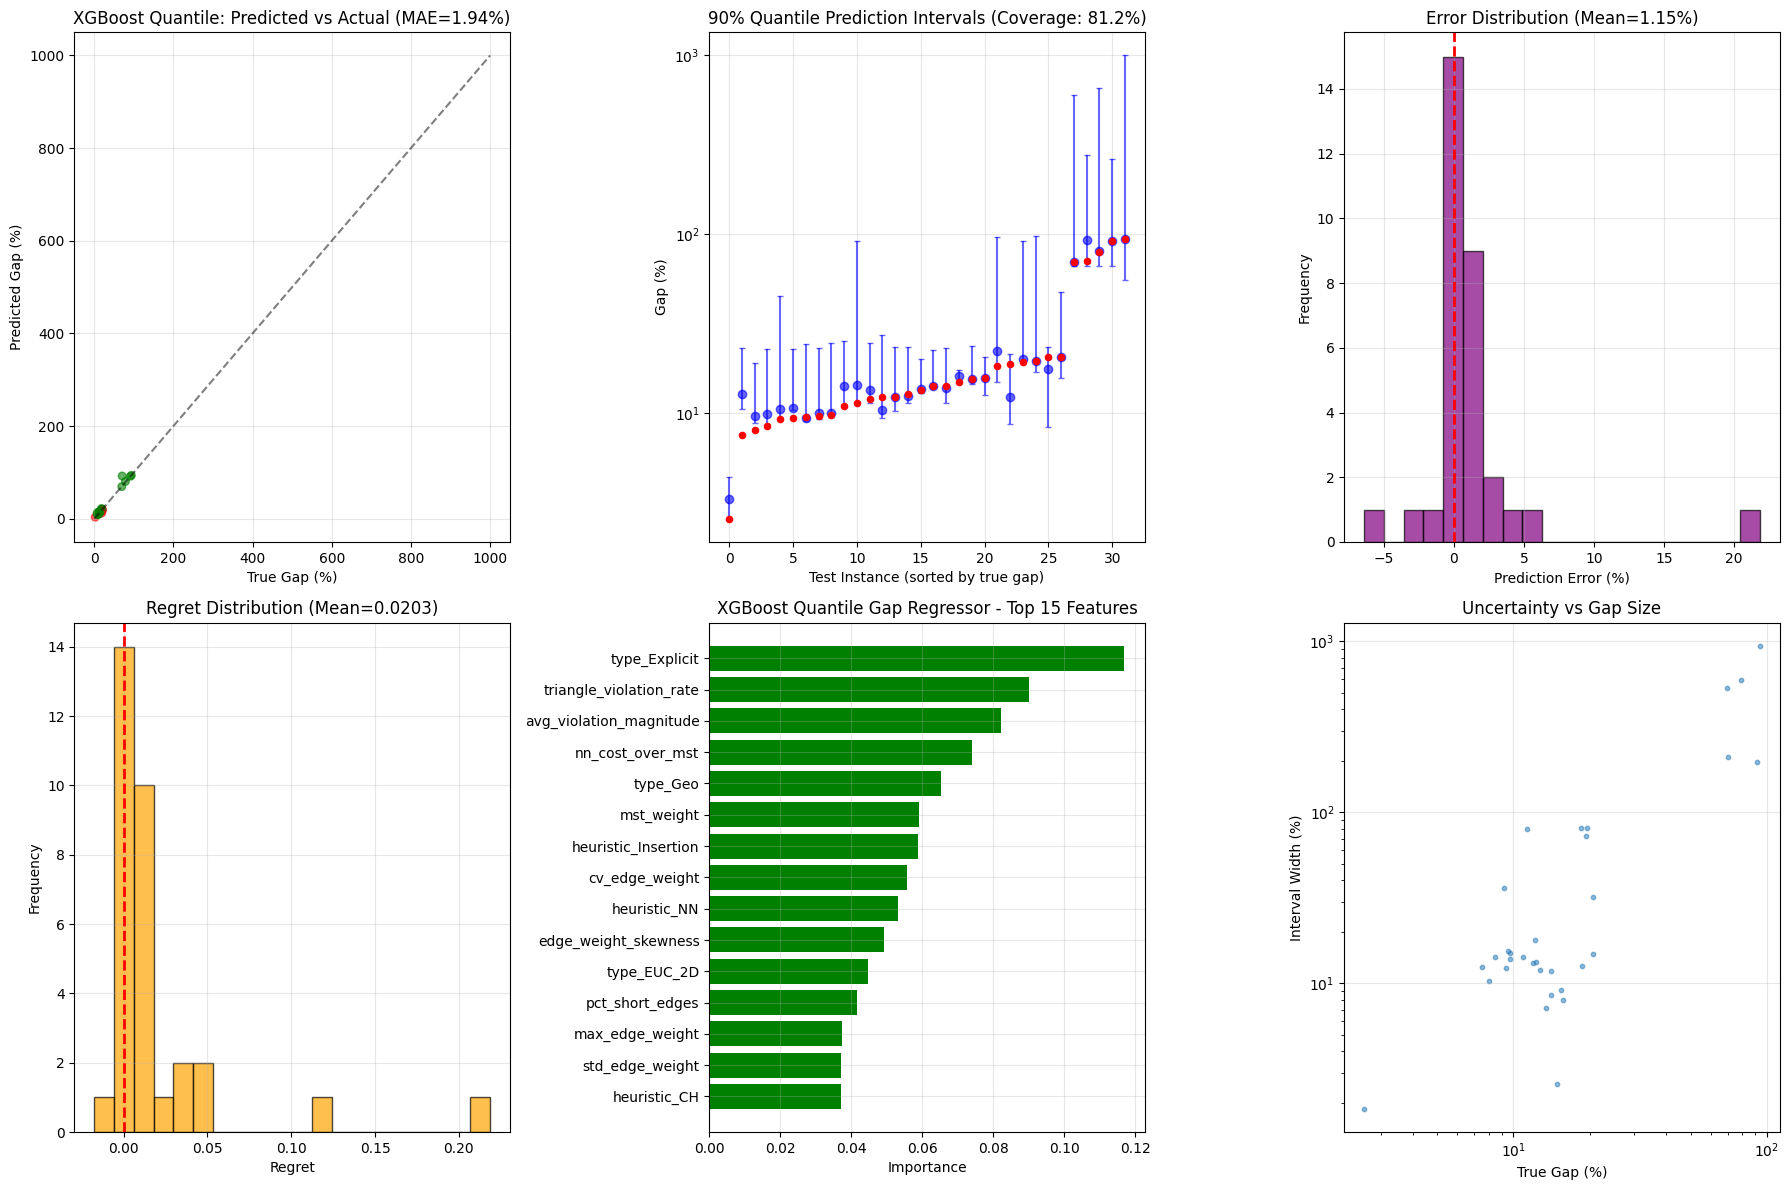


FINAL SUMMARY - XGBOOST QUANTILE REGRESSION

INTEGRATED XGBOOST TWO-STAGE PIPELINE WITH QUANTILE REGRESSION
Test Instances: 32/32 (with gap data)

STAGE 1: BEST HEURISTIC CLASSIFIER
  - XGBoost Classifier Accuracy: 87.50%
  - Correct: 28/32

STAGE 2: QUANTILE OPTIMALITY GAP REGRESSOR (XGBoost)
  - MAE: 1.94 percentage points
  - RMSE: 4.36
  - R² (log scale): 0.9573
  - Within ±10%: 96.88%
  - Within ±20%: 96.88%
  - Within ±30%: 100.00%
  - Within ±50%: 100.00%

QUANTILE PREDICTION (90% Intervals)
  - Quantiles: 0.05 (lower), 0.5 (median), 0.95 (upper)
  - Empirical coverage: 81.25%
  - Mean interval width: 96.72 percentage points
  - Median interval width: 14.27 percentage points

COMBINED PERFORMANCE
  - Average Regret if using predicted heuristic: 0.0203
  - Median Regret: 0.0071
  - Max Regret: 0.2186


✅ Results saved to:
   - xgboost_quantile_integrated_results.csv
   - xgboost_quantile_feature_importance.csv


In [ ]:
# ============================================
# INTEGRATED XGBOOST TWO-STAGE PIPELINE WITH QUANTILE REGRESSION
# Stage 1: Predict Best Heuristic (XGBoost Classifier)
# Stage 2: Predict Optimality Gap with 90% Prediction Intervals (XGBoost Quantile)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBClassifier, XGBRegressor
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("INTEGRATED XGBOOST TWO-STAGE PIPELINE WITH QUANTILE REGRESSION")
print("Stage 1: Best Heuristic Classifier (XGBoost)")
print("Stage 2: Quantile Optimality Gap Regressor (XGBoost)")
print("="*80)

# ============================================
# PART 1: LOAD AND PREPARE DATA
# ============================================
CSV_PATH = "/content/drive/MyDrive/Dataframe/Dataset.csv"
df = pd.read_csv(CSV_PATH)

RUNTIME_CAP = 600_000
EPS = 0.05

df["feasible"] = df["runtime_ms"] <= RUNTIME_CAP
df["best_feasible_cost"] = (
    df[df["feasible"]]
    .groupby("file")["cost"]
    .transform("min")
)
df["is_best"] = (
    df["feasible"] &
    (df["cost"] <= (1 + EPS) * df["best_feasible_cost"])
)

best_rows = (
    df[df["is_best"]]
    .sort_values(["file", "cost"])
    .groupby("file")
    .first()
    .reset_index(drop=False)
)

# Instance features (same for both models)
instance_features = [
    "n", "min_edge_weight", "max_edge_weight", "std_edge_weight",
    "cv_edge_weight", "edge_weight_skewness", "pct_short_edges",
    "triangle_violation_rate", "avg_violation_magnitude",
    "mst_weight", "nn_cost_over_mst", "type"
]

numeric_features = [f for f in instance_features if f != "type"]
categorical_features = ["type"]

print(f"Total instances: {len(best_rows)}")
print(f"Total rows in full dataset: {len(df)}")

# ============================================
# PART 2: STAGE 1 - XGBOOST BEST HEURISTIC CLASSIFIER
# ============================================
print("\n" + "="*60)
print("STAGE 1: Training XGBoost Best Heuristic Classifier")
print("="*60)

# Prepare data for classifier
X_class = best_rows[instance_features]
y_class = best_rows["heuristic"]

# Encode target
label_encoder = LabelEncoder()
y_class_encoded = label_encoder.fit_transform(y_class)

# Split data (same random_state=1 for reproducibility)
X_train_class, X_test_class, y_train_class, y_test_class, files_train, files_test = train_test_split(
    X_class, y_class_encoded, best_rows["file"],
    test_size=0.2,
    random_state=2,
    stratify=y_class_encoded
)

# Preprocessing for classifier
preprocess_class = ColumnTransformer([
    ("num", "passthrough", numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

# XGBoost Classifier
xgb_classifier = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=3,
    n_jobs=-1
)

pipeline_class = Pipeline([
    ("preprocess", preprocess_class),
    ("classifier", xgb_classifier)
])

# Train classifier
pipeline_class.fit(X_train_class, y_train_class)

# Predict on test set
y_pred_class_encoded = pipeline_class.predict(X_test_class)
y_pred_class = label_encoder.inverse_transform(y_pred_class_encoded)
y_true_class = label_encoder.inverse_transform(y_test_class)

# Classifier performance
class_accuracy = (y_pred_class == y_true_class).mean()
print(f"XGBoost Classifier Accuracy: {class_accuracy:.4f}")

# Store test instance info
test_instances = pd.DataFrame({
    'file': files_test.values,
    'true_heuristic': y_true_class,
    'predicted_heuristic': y_pred_class
})

# ============================================
# PART 3: PREPARE DATA FOR STAGE 2 (QUANTILE GAP REGRESSOR)
# ============================================
print("\n" + "="*60)
print("STAGE 2: Preparing XGBoost Quantile Optimality Gap Regressor")
print("="*60)

# Clean data for gap regression (remove rows with missing optimality_gap)
df_gap = df.dropna(subset=['optimality_gap']).copy()

# Apply log transformation to optimality_gap
df_gap['gap_log'] = np.log1p(df_gap['optimality_gap'])

print(f"\nOptimality gap statistics:")
print(f"  Min: {df_gap['optimality_gap'].min():.2f}%")
print(f"  Max: {df_gap['optimality_gap'].max():.2f}%")
print(f"  Mean: {df_gap['optimality_gap'].mean():.2f}%")
print(f"  Median: {df_gap['optimality_gap'].median():.2f}%")

# Features for gap model: instance features + heuristic
gap_feature_cols = instance_features + ['heuristic']
X_gap = df_gap[gap_feature_cols]
y_gap = df_gap['gap_log']

# Split gap data by file to prevent leakage
unique_files_gap = df_gap['file'].unique()
train_files_gap, test_files_gap = train_test_split(
    unique_files_gap, test_size=0.2, random_state=1
)

train_mask_gap = df_gap['file'].isin(train_files_gap)
test_mask_gap = df_gap['file'].isin(test_files_gap)

X_train_gap, X_test_gap = X_gap[train_mask_gap], X_gap[test_mask_gap]
y_train_gap, y_test_gap = y_gap[train_mask_gap], y_gap[test_mask_gap]

print(f"\nGap model training rows: {len(X_train_gap)}")
print(f"Gap model test rows: {len(X_test_gap)}")

# Preprocessing for gap model (includes heuristic!)
gap_numeric = [f for f in instance_features if f != "type"]
gap_categorical = ["type", "heuristic"]  # Includes heuristic!

preprocess_gap = ColumnTransformer([
    ("num", StandardScaler(), gap_numeric),  # Scale for regression
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), gap_categorical)
])

# Transform data for quantile models
X_train_gap_processed = preprocess_gap.fit_transform(X_train_gap)
X_test_gap_processed = preprocess_gap.transform(X_test_gap)

# Get feature names for later
cat_feat_names = preprocess_gap.named_transformers_["cat"].get_feature_names_out(["type", "heuristic"])
all_feature_names = np.concatenate([gap_numeric, cat_feat_names])

# ============================================
# PART 4: TRAIN THREE QUANTILE XGBOOST MODELS
# ============================================
print("\n" + "="*60)
print("Training XGBoost Quantile Models for 90% Prediction Intervals")
print("="*60)

# Define quantiles
quantiles = [0.05, 0.5, 0.95]
quantile_models = {}

# Common parameters
common_params = {
    'n_estimators': 300,
    'max_depth': 5,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_lambda': 1,
    'reg_alpha': 0.1,
    'random_state': 3,
    'n_jobs': -1
}

# Train each quantile model
for q in quantiles:
    print(f"Training quantile model for q={q}...")
    model = XGBRegressor(
        objective='reg:quantileerror',
        quantile_alpha=q,
        **common_params
    )
    model.fit(X_train_gap_processed, y_train_gap)
    quantile_models[q] = model

print("✓ All quantile models trained successfully")

# Evaluate quantile models on hold-out test set
y_pred_lower = quantile_models[0.05].predict(X_test_gap_processed)
y_pred_median = quantile_models[0.5].predict(X_test_gap_processed)
y_pred_upper = quantile_models[0.95].predict(X_test_gap_processed)

# Convert back to original scale
y_pred_median_orig = np.expm1(y_pred_median)
y_test_orig = np.expm1(y_test_gap)

# Evaluate point predictions
gap_mae_holdout = mean_absolute_error(y_test_orig, y_pred_median_orig)
gap_r2_holdout = r2_score(y_test_gap, y_pred_median)

print(f"\nQuantile Regressor Hold-out Performance:")
print(f"  MAE: {gap_mae_holdout:.2f}%")
print(f"  R² (log): {gap_r2_holdout:.4f}")

# Evaluate interval coverage
coverage_holdout = np.mean((y_test_orig >= np.expm1(y_pred_lower)) &
                            (y_test_orig <= np.expm1(y_pred_upper)))
print(f"  Interval coverage: {coverage_holdout*100:.2f}%")

# ============================================
# PART 5: INTEGRATED PREDICTION ON TEST INSTANCES
# ============================================
print("\n" + "="*60)
print("INTEGRATED PREDICTION ON TEST INSTANCES (WITH QUANTILE INTERVALS)")
print("="*60)

integrated_results = []

for idx, row in test_instances.iterrows():
    file = row['file']
    true_heuristic = row['true_heuristic']
    pred_heuristic = row['predicted_heuristic']

    # Get instance features for this file
    instance_row = best_rows[best_rows['file'] == file].iloc[0]

    # Create feature vector for gap prediction using PREDICTED heuristic
    gap_input = {}
    for feat in instance_features:
        gap_input[feat] = instance_row[feat]
    gap_input['heuristic'] = pred_heuristic  # Use PREDICTED heuristic!

    # Convert to DataFrame for prediction
    gap_df = pd.DataFrame([gap_input])

    # Transform
    X_proc = preprocess_gap.transform(gap_df)

    # Get predictions from all three quantile models
    pred_lower_log = quantile_models[0.05].predict(X_proc)[0]
    pred_median_log = quantile_models[0.5].predict(X_proc)[0]
    pred_upper_log = quantile_models[0.95].predict(X_proc)[0]

    # Convert back to original scale
    pred_gap = np.expm1(pred_median_log)
    lower_gap = np.expm1(pred_lower_log)
    upper_gap = np.expm1(pred_upper_log)

    # Get true gap for the predicted heuristic (if available)
    true_gap_row = df_gap[(df_gap['file'] == file) &
                          (df_gap['heuristic'] == pred_heuristic)]

    if len(true_gap_row) > 0:
        true_gap = true_gap_row['optimality_gap'].iloc[0]
        true_gap_log = true_gap_row['gap_log'].iloc[0]
    else:
        true_gap = np.nan
        true_gap_log = np.nan

    # Get true gap for the actual best heuristic
    true_best_row = df_gap[(df_gap['file'] == file) &
                           (df_gap['heuristic'] == true_heuristic)]
    true_best_gap = true_best_row['optimality_gap'].iloc[0] if len(true_best_row) > 0 else np.nan

    integrated_results.append({
        'file': file,
        'true_heuristic': true_heuristic,
        'predicted_heuristic': pred_heuristic,
        'classifier_correct': true_heuristic == pred_heuristic,
        'predicted_gap': pred_gap,
        'lower_gap': lower_gap,
        'upper_gap': upper_gap,
        'interval_width': upper_gap - lower_gap,
        'true_gap_pred_heuristic': true_gap,
        'true_best_gap': true_best_gap,
        'gap_error': pred_gap - true_gap if not np.isnan(true_gap) else np.nan,
        'in_interval': (true_gap >= lower_gap) & (true_gap <= upper_gap) if not np.isnan(true_gap) else False,
        'regret_if_use_pred': (pred_gap - true_best_gap) / 100 if not np.isnan(true_best_gap) else np.nan
    })

integrated_df = pd.DataFrame(integrated_results)

# ============================================
# PART 6: EVALUATE INTEGRATED PIPELINE
# ============================================
print("\n" + "="*60)
print("INTEGRATED PIPELINE PERFORMANCE")
print("="*60)

# Filter out rows with missing true gaps
valid_results = integrated_df.dropna(subset=['true_gap_pred_heuristic'])

if len(valid_results) > 0:
    # Gap prediction metrics
    gap_mae = mean_absolute_error(valid_results['true_gap_pred_heuristic'],
                                   valid_results['predicted_gap'])
    gap_rmse = np.sqrt(mean_squared_error(valid_results['true_gap_pred_heuristic'],
                                          valid_results['predicted_gap']))

    # Log-scale metrics
    true_log = np.log1p(valid_results['true_gap_pred_heuristic'])
    pred_log = np.log1p(valid_results['predicted_gap'])
    r2_log = r2_score(true_log, pred_log)

    print(f"\n📊 Gap Prediction Performance (for predicted heuristics):")
    print(f"   MAE:  {gap_mae:.2f} percentage points")
    print(f"   RMSE: {gap_rmse:.2f}")
    print(f"   R² (log scale): {r2_log:.4f}")

    # Classification accuracy
    class_acc = valid_results['classifier_correct'].mean()
    print(f"\n📊 XGBoost Classifier Accuracy: {class_acc:.4f}")

    # Interval coverage
    interval_coverage = valid_results['in_interval'].mean()
    print(f"\n📊 90% Quantile Prediction Interval Coverage: {interval_coverage*100:.2f}%")
    print(f"   Mean interval width: {valid_results['interval_width'].mean():.2f}%")
    print(f"   Median interval width: {valid_results['interval_width'].median():.2f}%")

    # Combined metric: How often is predicted gap within X% of true?
    print(f"\n📊 Prediction Accuracy:")
    for threshold in [10, 20, 30, 50]:
        within_threshold = (np.abs(valid_results['gap_error']) <= threshold).mean()
        print(f"   Within ±{threshold}%: {within_threshold:.2%}")

# ============================================
# PART 7: DETAILED RESULTS TABLE WITH QUANTILE INTERVALS
# ============================================
print("\n" + "="*80)
print("DETAILED INTEGRATED XGBOOST RESULTS (WITH 90% QUANTILE INTERVALS)")
print("="*80)

# Sort by classification correctness then gap error
display_df = valid_results.sort_values(['classifier_correct', 'gap_error'],
                                       ascending=[False, True])

print("\n📋 TEST INSTANCE RESULTS:")
print("-"*130)
print(f"{'File':<25} {'True Best':<12} {'Pred Best':<12} {'Correct':<8} "
      f"{'Pred Gap':<12} {'90% Interval':<20} {'True Gap':<12} {'In Int':<8}")
print("-"*130)

for _, row in display_df.iterrows():
    correct_marker = "✓" if row['classifier_correct'] else "✗"
    interval_str = f"[{row['lower_gap']:.1f}, {row['upper_gap']:.1f}]"
    in_interval = "✅" if row['in_interval'] else "❌"
    print(f"{row['file']:<25} {row['true_heuristic']:<12} "
          f"{row['predicted_heuristic']:<12} {correct_marker:<8} "
          f"{row['predicted_gap']:<12.2f} {interval_str:<20} "
          f"{row['true_gap_pred_heuristic']:<12.2f} {in_interval:<8}")

# ============================================
# PART 8: FEATURE IMPORTANCE FOR QUANTILE MODELS
# ============================================
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS (Median Model)")
print("="*60)

# Use the median model for feature importance
median_model = quantile_models[0.5]
reg_importance = median_model.feature_importances_

reg_imp_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': reg_importance
}).sort_values('importance', ascending=False)

print("\n📊 XGBoost Quantile Gap Regressor (Median) - Top 15 Features:")
print(reg_imp_df.head(15).to_string(index=False))

# Also show classifier feature importance
class_imp_df = pd.DataFrame({
    'feature': all_feat_names_class if 'all_feat_names_class' in locals() else [],
    'importance': classifier.feature_importances_
}).sort_values('importance', ascending=False) if 'classifier' in locals() else pd.DataFrame()

if not class_imp_df.empty:
    print("\n📊 XGBoost Classifier - Top 10 Features:")
    print(class_imp_df.head(10).to_string(index=False))

# ============================================
# PART 9: FIXED VISUALIZATIONS (with error handling)
# ============================================
print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Predicted vs Actual Gaps
ax = axes[0, 0]
colors = ['green' if x else 'red' for x in valid_results['classifier_correct']]
ax.scatter(valid_results['true_gap_pred_heuristic'],
           valid_results['predicted_gap'],
           alpha=0.6, s=30, c=colors)
ax.plot([0, 1000], [0, 1000], 'k--', alpha=0.5)
ax.set_xlabel('True Gap (%)')
ax.set_ylabel('Predicted Gap (%)')
ax.set_title(f'XGBoost Quantile: Predicted vs Actual (MAE={gap_mae:.2f}%)')
ax.grid(True, alpha=0.3)

# Plot 2: Prediction Intervals (FIXED)
ax = axes[0, 1]
sorted_idx = np.argsort(valid_results['true_gap_pred_heuristic'].values)
n_show = min(50, len(valid_results))
plot_idx = sorted_idx[:n_show]

for i, idx in enumerate(plot_idx):
    row = valid_results.iloc[idx]

    # Ensure lower and upper are valid
    lower_err = max(0, row['predicted_gap'] - row['lower_gap'])
    upper_err = max(0, row['upper_gap'] - row['predicted_gap'])

    # Only plot if errors are non-negative
    if lower_err >= 0 and upper_err >= 0 and not np.isnan(lower_err) and not np.isnan(upper_err):
        ax.errorbar(i, row['predicted_gap'],
                    yerr=[[lower_err], [upper_err]],
                    fmt='o', capsize=2, color='blue', alpha=0.6)
    else:
        # If errors are invalid, just plot the point
        ax.plot(i, row['predicted_gap'], 'o', color='blue', alpha=0.6)

    ax.scatter(i, row['true_gap_pred_heuristic'], color='red', s=20, zorder=5)

ax.set_xlabel('Test Instance (sorted by true gap)')
ax.set_ylabel('Gap (%)')
ax.set_title(f'90% Quantile Prediction Intervals (Coverage: {interval_coverage*100:.1f}%)')
ax.set_yscale('symlog')
ax.grid(True, alpha=0.3)

# Plot 3: Error Distribution
ax = axes[0, 2]
ax.hist(valid_results['gap_error'].dropna(), bins=20, edgecolor='black', alpha=0.7, color='purple')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Prediction Error (%)')
ax.set_ylabel('Frequency')
ax.set_title(f'Error Distribution (Mean={valid_results["gap_error"].mean():.2f}%)')
ax.grid(True, alpha=0.3)

# Plot 4: Regret Distribution
ax = axes[1, 0]
regret_data = valid_results['regret_if_use_pred'].dropna()
if len(regret_data) > 0:
    ax.hist(regret_data, bins=20, edgecolor='black', alpha=0.7, color='orange')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Regret')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Regret Distribution (Mean={regret_data.mean():.4f})')
    ax.grid(True, alpha=0.3)

# Plot 5: Feature Importance (Median Model)
ax = axes[1, 1]
top_reg = reg_imp_df.head(15)
ax.barh(range(len(top_reg)), top_reg['importance'].values, color='green')
ax.set_yticks(range(len(top_reg)))
ax.set_yticklabels(top_reg['feature'].values)
ax.set_xlabel('Importance')
ax.set_title('XGBoost Quantile Gap Regressor - Top 15 Features')
ax.invert_yaxis()
ax.grid(True, alpha=0.3)

# Plot 6: Interval Width vs True Gap
ax = axes[1, 2]
# Filter out invalid or zero widths
valid_widths = valid_results[(valid_results['interval_width'] > 0) &
                              (valid_results['true_gap_pred_heuristic'] > 0)]
if len(valid_widths) > 0:
    ax.scatter(valid_widths['true_gap_pred_heuristic'],
               valid_widths['interval_width'], alpha=0.5, s=10)
    ax.set_xscale('log')
    ax.set_yscale('log')
else:
    ax.scatter(valid_results['true_gap_pred_heuristic'],
               valid_results['interval_width'], alpha=0.5, s=10)
ax.set_xlabel('True Gap (%)')
ax.set_ylabel('Interval Width (%)')
ax.set_title('Uncertainty vs Gap Size')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# PART 10: SUMMARY STATISTICS
# ============================================
print("\n" + "="*60)
print("FINAL SUMMARY - XGBOOST QUANTILE REGRESSION")
print("="*60)

print(f"""
INTEGRATED XGBOOST TWO-STAGE PIPELINE WITH QUANTILE REGRESSION
===============================================================
Test Instances: {len(valid_results)}/{len(test_instances)} (with gap data)

STAGE 1: BEST HEURISTIC CLASSIFIER
  - XGBoost Classifier Accuracy: {class_acc:.2%}
  - Correct: {valid_results['classifier_correct'].sum()}/{len(valid_results)}

STAGE 2: QUANTILE OPTIMALITY GAP REGRESSOR (XGBoost)
  - MAE: {gap_mae:.2f} percentage points
  - RMSE: {gap_rmse:.2f}
  - R² (log scale): {r2_log:.4f}
  - Within ±10%: {(np.abs(valid_results['gap_error']) <= 10).mean():.2%}
  - Within ±20%: {(np.abs(valid_results['gap_error']) <= 20).mean():.2%}
  - Within ±30%: {(np.abs(valid_results['gap_error']) <= 30).mean():.2%}
  - Within ±50%: {(np.abs(valid_results['gap_error']) <= 50).mean():.2%}

QUANTILE PREDICTION (90% Intervals)
  - Quantiles: 0.05 (lower), 0.5 (median), 0.95 (upper)
  - Empirical coverage: {interval_coverage*100:.2f}%
  - Mean interval width: {valid_results['interval_width'].mean():.2f} percentage points
  - Median interval width: {valid_results['interval_width'].median():.2f} percentage points

COMBINED PERFORMANCE
  - Average Regret if using predicted heuristic: {valid_results['regret_if_use_pred'].mean():.4f}
  - Median Regret: {valid_results['regret_if_use_pred'].median():.4f}
  - Max Regret: {valid_results['regret_if_use_pred'].max():.4f}
""")

# ============================================
# PART 11: SAVE RESULTS
# ============================================
valid_results.to_csv('/content/drive/MyDrive/Results/RF/seed_3_XGB_integrated_results.csv', index=False)
reg_imp_df.to_csv('/content/drive/MyDrive/Results/RF/seed_3_XGB_feature_importance.csv', index=False)

print("\n✅ Results saved to:")
print("   - xgboost_quantile_integrated_results.csv")
print("   - xgboost_quantile_feature_importance.csv")

##Logistic Regression

INTEGRATED LOGISTIC REGRESSION TWO-STAGE PIPELINE
Stage 1: Best Heuristic Classifier (Logistic Regression)
Stage 2: Optimality Gap Regressor (Random Forest)
Total instances: 160
Total rows in full dataset: 640

STAGE 1: Training Logistic Regression Best Heuristic Classifier
Logistic Regression Classifier Accuracy: 0.7500

STAGE 2: Preparing Optimality Gap Regressor

Optimality gap statistics:
  Min: 1.81%
  Max: 5496.41%
  Mean: 284.36%
  Median: 20.72%

Gap model training rows: 496
Gap model test rows: 128

Training Random Forest gap regressor...
Gap Regressor Hold-out Performance:
  MAE: 44.52%
  R² (log): 0.9552

INTEGRATED PREDICTION ON TEST INSTANCES

INTEGRATED PIPELINE PERFORMANCE

📊 Gap Prediction Performance (for predicted heuristics):
   MAE:  45.36 percentage points
   RMSE: 192.19
   R² (log scale): 0.9272

📊 Logistic Regression Classifier Accuracy: 0.7500

📊 Prediction Accuracy:
   Within ±10%: 84.38%
   Within ±20%: 87.50%
   Within ±30%: 87.50%
   Within ±50%: 90.62%

DE

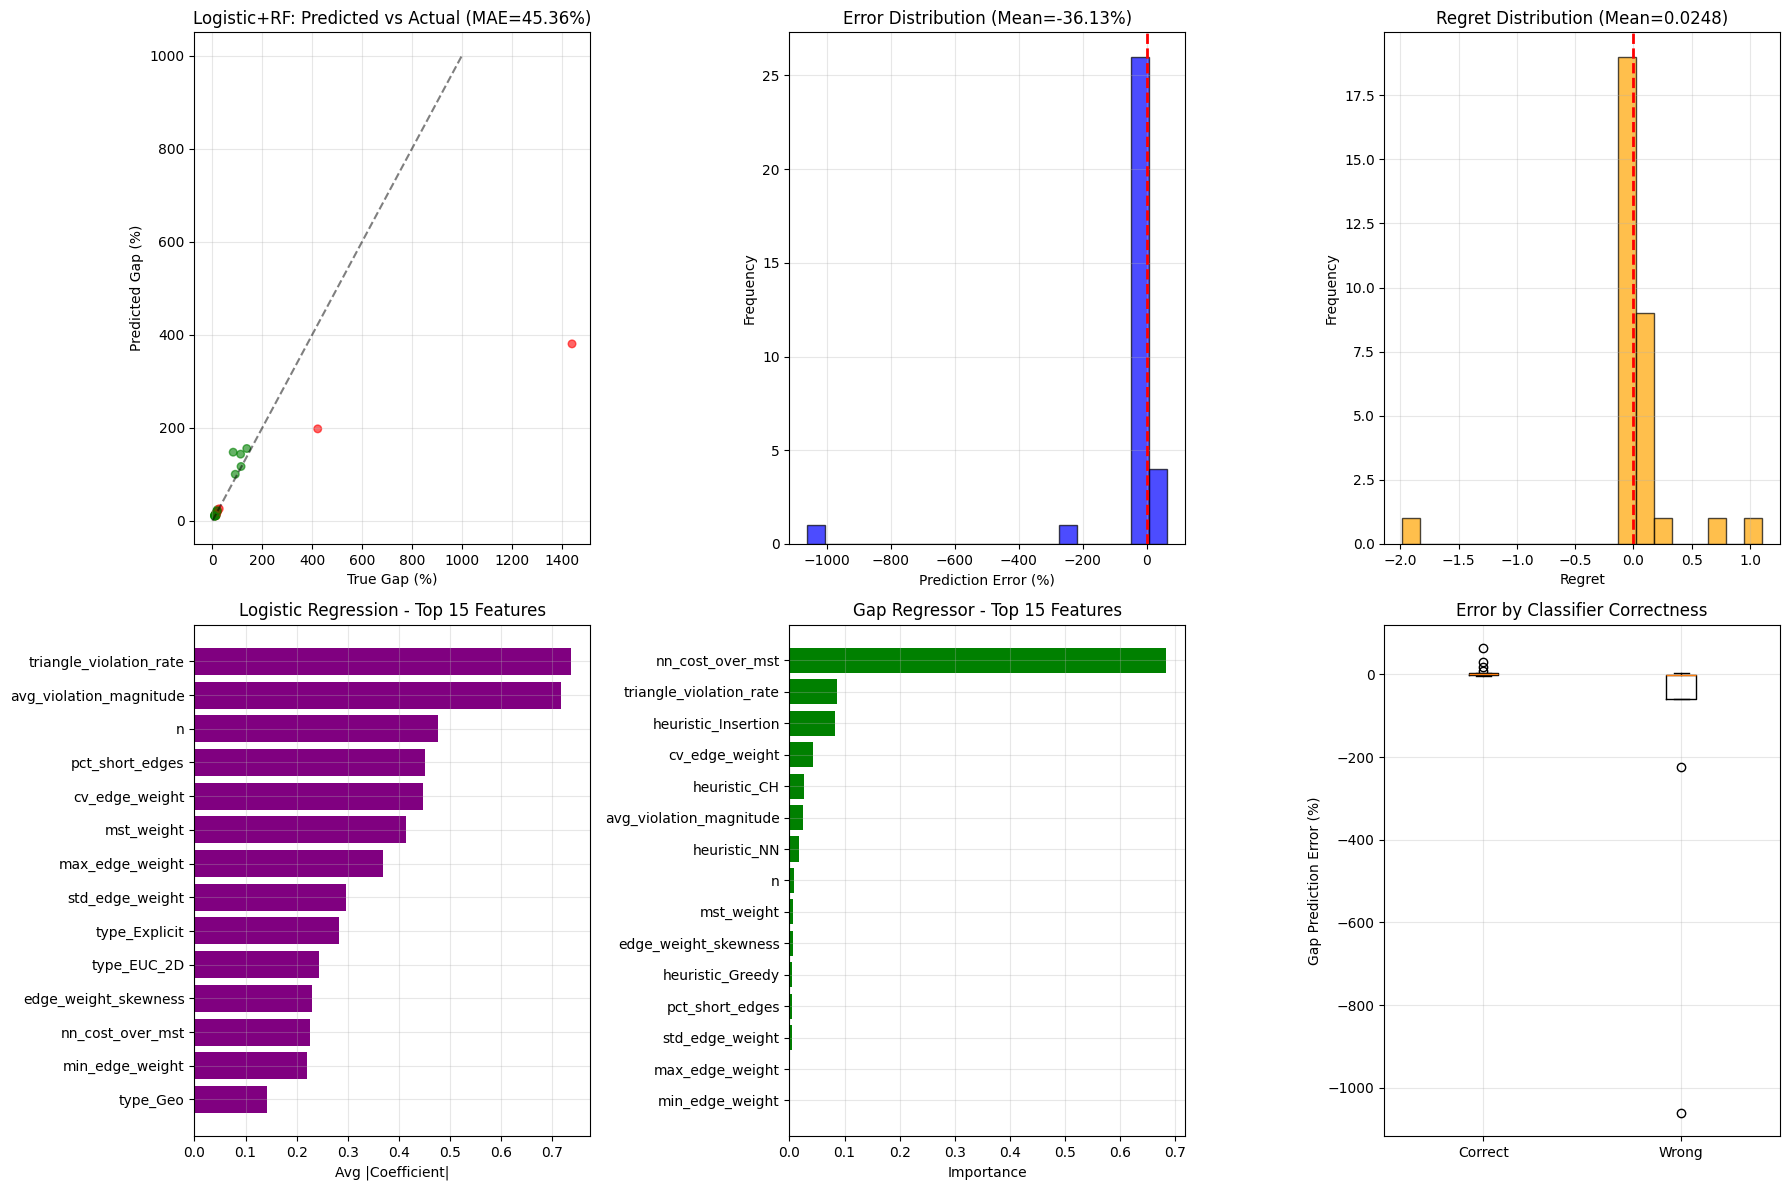


FINAL SUMMARY - LOGISTIC REGRESSION INTEGRATED PIPELINE

INTEGRATED LOGISTIC REGRESSION TWO-STAGE PIPELINE RESULTS
Test Instances: 32/32 (with gap data)

STAGE 1: BEST HEURISTIC CLASSIFIER
  - Logistic Regression Classifier Accuracy: 75.00%
  - Correct: 24/32

STAGE 2: OPTIMALITY GAP REGRESSOR (Random Forest)
  - MAE: 45.36 percentage points
  - RMSE: 192.19
  - R² (log scale): 0.9272

PREDICTION ACCURACY:
  - Within ±10%: 84.38%
  - Within ±20%: 87.50%
  - Within ±30%: 87.50%
  - Within ±50%: 90.62%

COMBINED PERFORMANCE
  - Average Regret if using predicted heuristic: 0.0248
  - Median Regret: 0.0196
  - Max Regret: 1.1035


✅ Results saved to:
   - logistic_integrated_pipeline_results.csv
   - logistic_coefficients.csv
   - gap_regressor_importance.csv


In [ ]:
# ============================================
# INTEGRATED LOGISTIC REGRESSION TWO-STAGE PIPELINE
# Stage 1: Predict Best Heuristic (Logistic Regression)
# Stage 2: Predict Optimality Gap for Predicted Heuristic
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("INTEGRATED LOGISTIC REGRESSION TWO-STAGE PIPELINE")
print("Stage 1: Best Heuristic Classifier (Logistic Regression)")
print("Stage 2: Optimality Gap Regressor (Random Forest)")
print("="*80)

# ============================================
# PART 1: LOAD AND PREPARE DATA
# ============================================
CSV_PATH = "/content/drive/MyDrive/Dataframe/Dataset.csv"
df = pd.read_csv(CSV_PATH)

RUNTIME_CAP = 600_000
EPS = 0.05

df["feasible"] = df["runtime_ms"] <= RUNTIME_CAP
df["best_feasible_cost"] = (
    df[df["feasible"]]
    .groupby("file")["cost"]
    .transform("min")
)
df["is_best"] = (
    df["feasible"] &
    (df["cost"] <= (1 + EPS) * df["best_feasible_cost"])
)

best_rows = (
    df[df["is_best"]]
    .sort_values(["file", "cost"])
    .groupby("file")
    .first()
    .reset_index()
)

# Instance features (same for both models)
instance_features = [
    "n", "min_edge_weight", "max_edge_weight", "std_edge_weight",
    "cv_edge_weight", "edge_weight_skewness", "pct_short_edges",
    "triangle_violation_rate", "avg_violation_magnitude",
    "mst_weight", "nn_cost_over_mst", "type"
]

numeric_features = [
    "n", "min_edge_weight", "max_edge_weight", "std_edge_weight",
    "cv_edge_weight", "edge_weight_skewness", "pct_short_edges",
    "triangle_violation_rate", "avg_violation_magnitude",
    "mst_weight", "nn_cost_over_mst"
]
categorical_features = ["type"]

print(f"Total instances: {len(best_rows)}")
print(f"Total rows in full dataset: {len(df)}")

# ============================================
# PART 2: STAGE 1 - LOGISTIC REGRESSION CLASSIFIER
# ============================================
print("\n" + "="*60)
print("STAGE 1: Training Logistic Regression Best Heuristic Classifier")
print("="*60)

# Prepare data for classifier
X_class = best_rows[instance_features]
y_class = best_rows["heuristic"]

# Encode target
label_encoder = LabelEncoder()
y_class_encoded = label_encoder.fit_transform(y_class)

# Split data (same random_state=1 for reproducibility)
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class_encoded,
    test_size=0.2,
    random_state=1,
    stratify=y_class_encoded
)

# Store test file indices for later
test_files = best_rows.loc[X_test_class.index, "file"].values

# Preprocessing for classifier (WITH scaling for logistic regression)
preprocess_class = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

# Logistic Regression Classifier
lr_classifier = LogisticRegression(
    max_iter=5000,
    solver="lbfgs",
    #class_weight='balanced',  # Handle class imbalance
    n_jobs=-1,
    random_state=1
)

pipeline_class = Pipeline([
    ("preprocess", preprocess_class),
    ("classifier", lr_classifier)
])

# Train classifier
pipeline_class.fit(X_train_class, y_train_class)

# Predict on test set
y_pred_class_encoded = pipeline_class.predict(X_test_class)
y_pred_class = label_encoder.inverse_transform(y_pred_class_encoded)
y_true_class = label_encoder.inverse_transform(y_test_class)

# Classifier performance
class_accuracy = (y_pred_class == y_true_class).mean()
print(f"Logistic Regression Classifier Accuracy: {class_accuracy:.4f}")

# Store test instance info
test_instances = pd.DataFrame({
    'file': test_files,
    'true_heuristic': y_true_class,
    'predicted_heuristic': y_pred_class
})

# ============================================
# PART 3: PREPARE DATA FOR STAGE 2 (GAP REGRESSOR)
# ============================================
print("\n" + "="*60)
print("STAGE 2: Preparing Optimality Gap Regressor")
print("="*60)

# Clean data for gap regression (remove rows with missing optimality_gap)
df_gap = df.dropna(subset=['optimality_gap']).copy()

# Apply log transformation to optimality_gap
df_gap['gap_log'] = np.log1p(df_gap['optimality_gap'])

print(f"\nOptimality gap statistics:")
print(f"  Min: {df_gap['optimality_gap'].min():.2f}%")
print(f"  Max: {df_gap['optimality_gap'].max():.2f}%")
print(f"  Mean: {df_gap['optimality_gap'].mean():.2f}%")
print(f"  Median: {df_gap['optimality_gap'].median():.2f}%")

# Features for gap model: instance features + heuristic
gap_feature_cols = instance_features + ['heuristic']
X_gap = df_gap[gap_feature_cols]
y_gap = df_gap['gap_log']

# Split gap data by file to prevent leakage
unique_files_gap = df_gap['file'].unique()
train_files_gap, test_files_gap = train_test_split(
    unique_files_gap, test_size=0.2, random_state=1
)

train_mask_gap = df_gap['file'].isin(train_files_gap)
test_mask_gap = df_gap['file'].isin(test_files_gap)

X_train_gap, X_test_gap = X_gap[train_mask_gap], X_gap[test_mask_gap]
y_train_gap, y_test_gap = y_gap[train_mask_gap], y_gap[test_mask_gap]

print(f"\nGap model training rows: {len(X_train_gap)}")
print(f"Gap model test rows: {len(X_test_gap)}")

# Preprocessing for gap model (includes heuristic!)
gap_numeric = [f for f in instance_features if f != "type"]
gap_categorical = ["type", "heuristic"]  # Includes heuristic!

preprocess_gap = ColumnTransformer([
    ("num", StandardScaler(), gap_numeric),  # Scale for regression
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), gap_categorical)
])

# Random Forest Regressor for gaps (good with non-linear relationships)
rf_regressor = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    random_state=1,
    n_jobs=-1
)

pipeline_gap = Pipeline([
    ("preprocess", preprocess_gap),
    ("regressor", rf_regressor)
])

# Train gap regressor
print("\nTraining Random Forest gap regressor...")
pipeline_gap.fit(X_train_gap, y_train_gap)

# Evaluate gap regressor on its own test set
y_pred_gap_log = pipeline_gap.predict(X_test_gap)
y_pred_gap = np.expm1(y_pred_gap_log)
y_test_gap_orig = np.expm1(y_test_gap)

gap_mae_holdout = mean_absolute_error(y_test_gap_orig, y_pred_gap)
gap_r2_holdout = r2_score(y_test_gap, y_pred_gap_log)

print(f"Gap Regressor Hold-out Performance:")
print(f"  MAE: {gap_mae_holdout:.2f}%")
print(f"  R² (log): {gap_r2_holdout:.4f}")

# ============================================
# PART 4: INTEGRATED PREDICTION ON TEST INSTANCES
# ============================================
print("\n" + "="*60)
print("INTEGRATED PREDICTION ON TEST INSTANCES")
print("="*60)

integrated_results = []

for idx, row in test_instances.iterrows():
    file = row['file']
    true_heuristic = row['true_heuristic']
    pred_heuristic = row['predicted_heuristic']

    # Get instance features for this file
    instance_row = best_rows[best_rows['file'] == file].iloc[0]

    # Create feature vector for gap prediction using PREDICTED heuristic
    gap_input = {}
    for feat in instance_features:
        gap_input[feat] = instance_row[feat]
    gap_input['heuristic'] = pred_heuristic  # Use PREDICTED heuristic!

    # Convert to DataFrame for prediction
    gap_df = pd.DataFrame([gap_input])

    # Predict gap (on log scale)
    pred_gap_log = pipeline_gap.predict(gap_df)[0]
    pred_gap = np.expm1(pred_gap_log)

    # Get true gap for the predicted heuristic (if available)
    true_gap_row = df_gap[(df_gap['file'] == file) &
                          (df_gap['heuristic'] == pred_heuristic)]

    if len(true_gap_row) > 0:
        true_gap = true_gap_row['optimality_gap'].iloc[0]
        true_gap_log = true_gap_row['gap_log'].iloc[0]
    else:
        true_gap = np.nan
        true_gap_log = np.nan

    # Get true gap for the actual best heuristic
    true_best_row = df_gap[(df_gap['file'] == file) &
                           (df_gap['heuristic'] == true_heuristic)]
    true_best_gap = true_best_row['optimality_gap'].iloc[0] if len(true_best_row) > 0 else np.nan

    integrated_results.append({
        'file': file,
        'true_heuristic': true_heuristic,
        'predicted_heuristic': pred_heuristic,
        'classifier_correct': true_heuristic == pred_heuristic,
        'predicted_gap': pred_gap,
        'true_gap_pred_heuristic': true_gap,
        'true_best_gap': true_best_gap,
        'gap_error': pred_gap - true_gap if not np.isnan(true_gap) else np.nan,
        'regret_if_use_pred': (pred_gap - true_best_gap) / 100 if not np.isnan(true_best_gap) else np.nan
    })

integrated_df = pd.DataFrame(integrated_results)

# ============================================
# PART 5: EVALUATE INTEGRATED PIPELINE
# ============================================
print("\n" + "="*60)
print("INTEGRATED PIPELINE PERFORMANCE")
print("="*60)

# Filter out rows with missing true gaps
valid_results = integrated_df.dropna(subset=['true_gap_pred_heuristic'])

if len(valid_results) > 0:
    # Gap prediction metrics
    gap_mae = mean_absolute_error(valid_results['true_gap_pred_heuristic'],
                                   valid_results['predicted_gap'])
    gap_rmse = np.sqrt(mean_squared_error(valid_results['true_gap_pred_heuristic'],
                                          valid_results['predicted_gap']))

    # Log-scale metrics
    true_log = np.log1p(valid_results['true_gap_pred_heuristic'])
    pred_log = np.log1p(valid_results['predicted_gap'])
    r2_log = r2_score(true_log, pred_log)

    print(f"\n📊 Gap Prediction Performance (for predicted heuristics):")
    print(f"   MAE:  {gap_mae:.2f} percentage points")
    print(f"   RMSE: {gap_rmse:.2f}")
    print(f"   R² (log scale): {r2_log:.4f}")

    # Classification accuracy
    class_acc = valid_results['classifier_correct'].mean()
    print(f"\n📊 Logistic Regression Classifier Accuracy: {class_acc:.4f}")

    # Combined metric: How often is predicted gap within X% of true?
    print(f"\n📊 Prediction Accuracy:")
    for threshold in [10, 20, 30, 50]:
        within_threshold = (np.abs(valid_results['gap_error']) <= threshold).mean()
        print(f"   Within ±{threshold}%: {within_threshold:.2%}")

# ============================================
# PART 6: DETAILED RESULTS TABLE
# ============================================
print("\n" + "="*80)
print("DETAILED INTEGRATED LOGISTIC REGRESSION RESULTS")
print("="*80)

# Sort by classification correctness then gap error
display_df = valid_results.sort_values(['classifier_correct', 'gap_error'],
                                       ascending=[False, True])

print("\n📋 TEST INSTANCE RESULTS:")
print("-"*110)
print(f"{'File':<25} {'True Best':<12} {'Pred Best':<12} {'Correct':<8} "
      f"{'Pred Gap':<10} {'True Gap':<10} {'Error':<10} {'Regret':<10}")
print("-"*110)

for _, row in display_df.iterrows():
    correct_marker = "✓" if row['classifier_correct'] else "✗"
    regret_val = row['regret_if_use_pred'] if not np.isnan(row['regret_if_use_pred']) else 0
    print(f"{row['file']:<25} {row['true_heuristic']:<12} "
          f"{row['predicted_heuristic']:<12} {correct_marker:<8} "
          f"{row['predicted_gap']:<10.2f} {row['true_gap_pred_heuristic']:<10.2f} "
          f"{row['gap_error']:<10.2f} {regret_val:<10.4f}")

# ============================================
# PART 7: FEATURE ANALYSIS FOR BOTH MODELS
# ============================================
print("\n" + "="*60)
print("FEATURE ANALYSIS")
print("="*60)

# Classifier coefficients
clf = pipeline_class.named_steps["classifier"]
pre_class = pipeline_class.named_steps["preprocess"]

feature_names_class = np.concatenate([
    numeric_features,
    pre_class.named_transformers_["cat"].get_feature_names_out(categorical_features)
])

coef_matrix = clf.coef_
coef_df = pd.DataFrame(
    coef_matrix.T,
    columns=label_encoder.classes_,
    index=feature_names_class
)

# Average absolute coefficient per feature (across all classes)
avg_abs_coef = np.abs(coef_df).mean(axis=1).sort_values(ascending=False)
coef_summary = avg_abs_coef.reset_index()
coef_summary.columns = ["feature", "avg_abs_coef"]

print("\n📊 Logistic Regression - Top 15 Features by Avg |Coefficient|:")
print(coef_summary.head(15).to_string(index=False))

# Regressor feature importance
reg = pipeline_gap.named_steps["regressor"]
pre_gap = pipeline_gap.named_steps["preprocess"]

cat_feat_names_gap = pre_gap.named_transformers_["cat"].get_feature_names_out(["type", "heuristic"])
all_feat_names_gap = np.concatenate([gap_numeric, cat_feat_names_gap])

reg_importance = reg.feature_importances_
reg_imp_df = pd.DataFrame({
    'feature': all_feat_names_gap,
    'importance': reg_importance
}).sort_values('importance', ascending=False)

print("\n📊 Gap Regressor (Random Forest) - Top 15 Features:")
print(reg_imp_df.head(15).to_string(index=False))

# ============================================
# PART 8: VISUALIZATIONS
# ============================================
print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Predicted vs Actual Gaps
ax = axes[0, 0]
colors = ['green' if x else 'red' for x in valid_results['classifier_correct']]
ax.scatter(valid_results['true_gap_pred_heuristic'],
           valid_results['predicted_gap'],
           alpha=0.6, s=30, c=colors)
ax.plot([0, 1000], [0, 1000], 'k--', alpha=0.5)
ax.set_xlabel('True Gap (%)')
ax.set_ylabel('Predicted Gap (%)')
ax.set_title(f'Logistic+RF: Predicted vs Actual (MAE={gap_mae:.2f}%)')
ax.grid(True, alpha=0.3)

# Plot 2: Error Distribution
ax = axes[0, 1]
ax.hist(valid_results['gap_error'].dropna(), bins=20, edgecolor='black', alpha=0.7, color='blue')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Prediction Error (%)')
ax.set_ylabel('Frequency')
ax.set_title(f'Error Distribution (Mean={valid_results["gap_error"].mean():.2f}%)')
ax.grid(True, alpha=0.3)

# Plot 3: Regret Distribution
ax = axes[0, 2]
regret_data = valid_results['regret_if_use_pred'].dropna()
if len(regret_data) > 0:
    ax.hist(regret_data, bins=20, edgecolor='black', alpha=0.7, color='orange')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Regret')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Regret Distribution (Mean={regret_data.mean():.4f})')
    ax.grid(True, alpha=0.3)

# Plot 4: Logistic Regression Coefficients
ax = axes[1, 0]
top_coef = coef_summary.head(15)
ax.barh(range(len(top_coef)), top_coef['avg_abs_coef'].values, color='purple')
ax.set_yticks(range(len(top_coef)))
ax.set_yticklabels(top_coef['feature'].values)
ax.set_xlabel('Avg |Coefficient|')
ax.set_title('Logistic Regression - Top 15 Features')
ax.invert_yaxis()
ax.grid(True, alpha=0.3)

# Plot 5: Gap Regressor Feature Importance
ax = axes[1, 1]
top_reg = reg_imp_df.head(15)
ax.barh(range(len(top_reg)), top_reg['importance'].values, color='green')
ax.set_yticks(range(len(top_reg)))
ax.set_yticklabels(top_reg['feature'].values)
ax.set_xlabel('Importance')
ax.set_title('Gap Regressor - Top 15 Features')
ax.invert_yaxis()
ax.grid(True, alpha=0.3)

# Plot 6: Classifier Correct vs Gap Error
ax = axes[1, 2]
correct_data = [valid_results[valid_results['classifier_correct']]['gap_error'].dropna(),
                valid_results[~valid_results['classifier_correct']]['gap_error'].dropna()]
if len(correct_data[0]) > 0 and len(correct_data[1]) > 0:
    ax.boxplot(correct_data, labels=['Correct', 'Wrong'])
    ax.set_ylabel('Gap Prediction Error (%)')
    ax.set_title('Error by Classifier Correctness')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# PART 9: SUMMARY STATISTICS
# ============================================
print("\n" + "="*60)
print("FINAL SUMMARY - LOGISTIC REGRESSION INTEGRATED PIPELINE")
print("="*60)

print(f"""
INTEGRATED LOGISTIC REGRESSION TWO-STAGE PIPELINE RESULTS
===========================================================
Test Instances: {len(valid_results)}/{len(test_instances)} (with gap data)

STAGE 1: BEST HEURISTIC CLASSIFIER
  - Logistic Regression Classifier Accuracy: {class_acc:.2%}
  - Correct: {valid_results['classifier_correct'].sum()}/{len(valid_results)}

STAGE 2: OPTIMALITY GAP REGRESSOR (Random Forest)
  - MAE: {gap_mae:.2f} percentage points
  - RMSE: {gap_rmse:.2f}
  - R² (log scale): {r2_log:.4f}

PREDICTION ACCURACY:
  - Within ±10%: {(np.abs(valid_results['gap_error']) <= 10).mean():.2%}
  - Within ±20%: {(np.abs(valid_results['gap_error']) <= 20).mean():.2%}
  - Within ±30%: {(np.abs(valid_results['gap_error']) <= 30).mean():.2%}
  - Within ±50%: {(np.abs(valid_results['gap_error']) <= 50).mean():.2%}

COMBINED PERFORMANCE
  - Average Regret if using predicted heuristic: {valid_results['regret_if_use_pred'].mean():.4f}
  - Median Regret: {valid_results['regret_if_use_pred'].median():.4f}
  - Max Regret: {valid_results['regret_if_use_pred'].max():.4f}
""")

# ============================================
# PART 10: SAVE RESULTS
# ============================================
valid_results.to_csv('logistic_integrated_pipeline_results.csv', index=False)
coef_summary.to_csv('logistic_coefficients.csv', index=False)
reg_imp_df.to_csv('gap_regressor_importance.csv', index=False)
print("\n✅ Results saved to:")
print("   - logistic_integrated_pipeline_results.csv")
print("   - logistic_coefficients.csv")
print("   - gap_regressor_importance.csv")

Testing Relation between nn_mst & Optimality Gap

INVESTIGATION: nn_cost_over_mst vs Optimality Gap
Total data points: 624
Unique files: 160

BASIC STATISTICS

📊 nn_cost_over_mst statistics:
count    624.000000
mean       3.573145
std        5.990407
min        1.054509
25%        1.410311
50%        1.503775
75%        1.757717
max       43.783133
Name: nn_cost_over_mst, dtype: float64

📊 Optimality Gap statistics:
count     624.000000
mean      284.360891
std       727.744378
min         1.807844
25%        14.214321
50%        20.720134
75%        50.724642
max      5496.410256
Name: optimality_gap, dtype: float64

📈 Pearson correlation: 0.6058
📈 Spearman correlation: 0.6348

VISUALIZATION 1: Scatter Plot with Regression

VISUALIZATION 2: By Heuristic


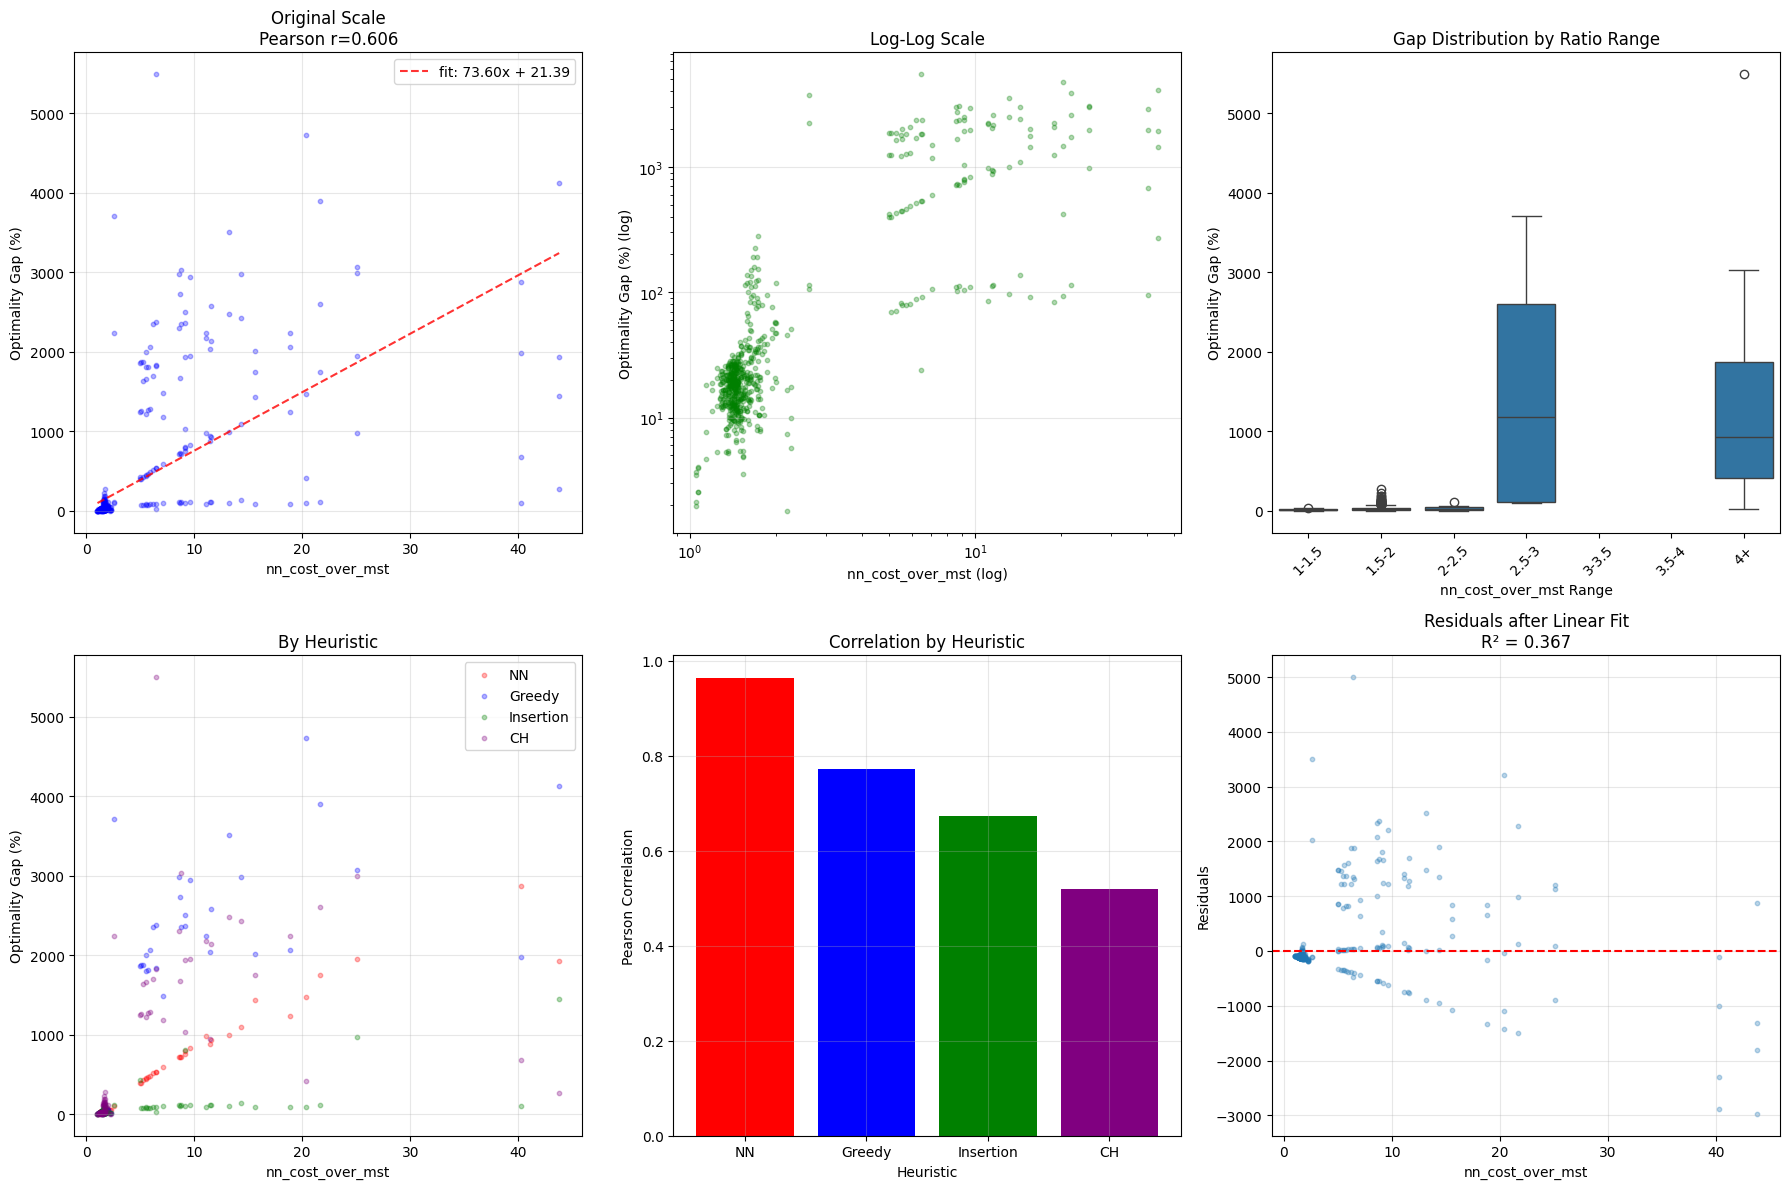


STATISTICAL ANALYSIS BY RATIO RANGE

📊 Gap Statistics by nn_cost_over_mst Range:
           count  mean_gap  median_gap  std_gap  min_gap  max_gap
ratio_bin                                                        
1-1.5        304     17.17       17.38     6.29     1.99    40.29
1.5-2        188     38.06       21.73    42.35     3.55   281.91
2-2.5         12     33.11       18.49    33.10     1.81   117.84
2.5-3          4   1542.75     1175.54  1761.62   105.19  3714.72
3-3.5          0       NaN         NaN      NaN      NaN      NaN
3.5-4          0       NaN         NaN      NaN      NaN      NaN
4+            68   1193.94      930.34  1032.36    24.10  5496.41

NON-LINEAR REGRESSION MODELS

Degree 1 polynomial:
  R² = 0.3670

Degree 2 polynomial:
  R² = 0.5109

Degree 3 polynomial:
  R² = 0.5323

Degree 4 polynomial:
  R² = 0.5346


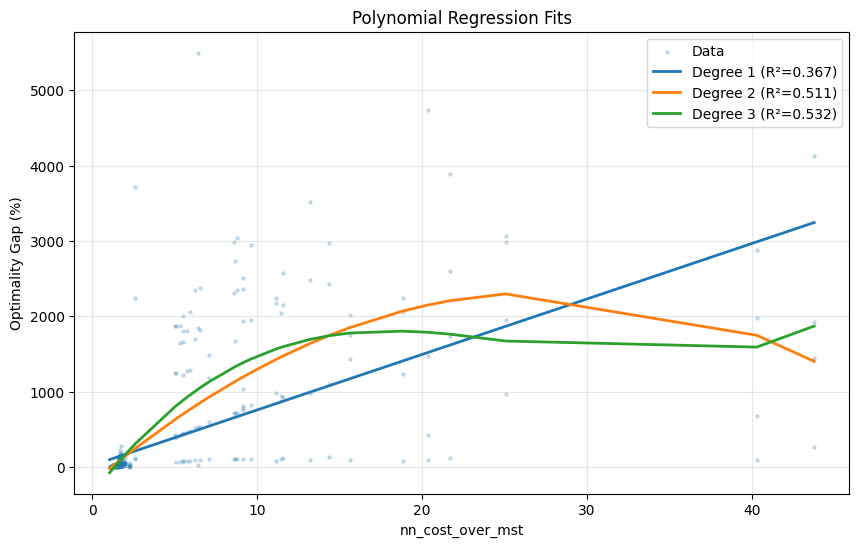


ANALYSIS BY INSTANCE SIZE (n)

📊 Statistics by Instance Size:
          nn_cost_over_mst        optimality_gap        
                      mean median           mean  median
size_bin                                                
<100                 3.688  1.514        154.501  17.281
100-500              4.097  1.586        368.581  22.700
500-1000             3.679  1.475        461.670  25.762
1000-2000            1.413  1.399         18.454  17.532
2000-5000            1.305  1.347         17.448  17.378
5000+                1.321  1.321         17.746  17.502


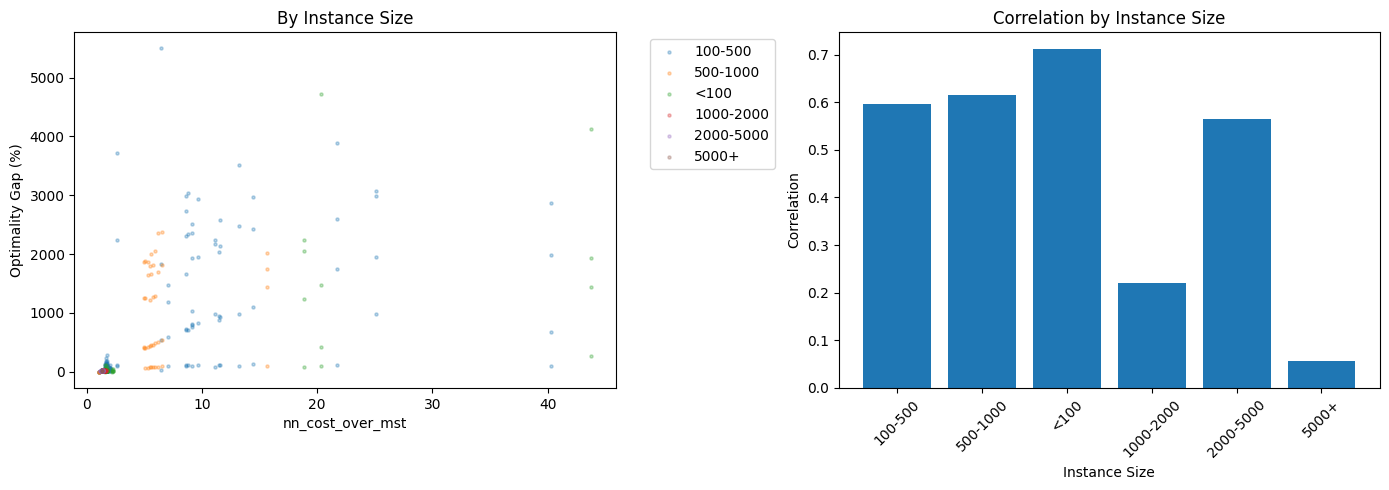


BOOTSTRAP CONFIDENCE INTERVALS

📊 Bootstrap 95% CI for Pearson correlation:
  Point estimate: 0.6058
  95% CI: [0.5058, 0.7073]


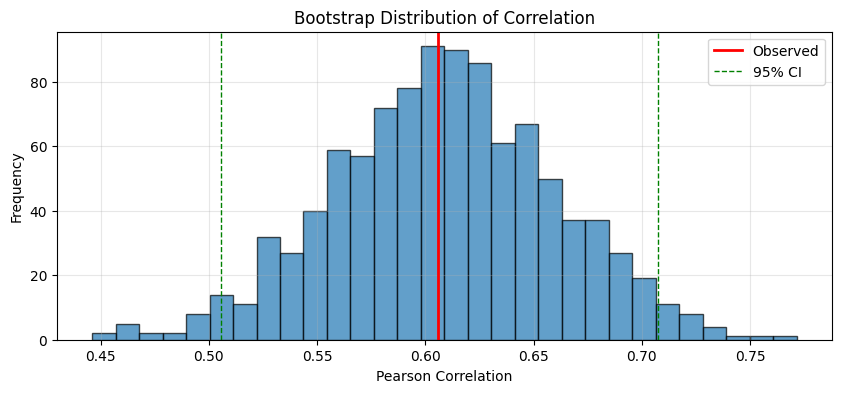


SUMMARY TABLE: nn_cost_over_mst vs Optimality Gap

               Metric   Value
  Pearson Correlation  0.6058
 Spearman Correlation  0.6348
            Linear R²  0.3670
         Quadratic R²  0.5109
             Cubic R²  0.5323
Mean nn_cost_over_mst   3.573
 Std nn_cost_over_mst   5.990
             Mean Gap  284.4%
              Std Gap  727.7%
           Median Gap   20.7%
              Min Gap    1.8%
              Max Gap 5496.4%
            N samples     624

KEY FINDINGS

1. CORRELATION STRENGTH:
   - Pearson r = 0.606 → Moderate positive correlation
   - Spearman ρ = 0.635 → Monotonic relationship is moderate

2. EXPLANATORY POWER:
   - Linear model explains 36.7% of variance in gap
   - Quadratic model explains 51.1% of variance
   - Cubic model explains 53.2% of variance

3. PRACTICAL INTERPRETATION:
   - When nn_cost_over_mst < 1.5: Typical gap = 17.2% (easy instances)
   - When nn_cost_over_mst > 3.0: Typical gap = nan% to 1193.9% (hard instances)
   - The relationship i

In [ ]:
# ============================================
# INVESTIGATION: nn_cost_over_mst vs Optimality Gap
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("INVESTIGATION: nn_cost_over_mst vs Optimality Gap")
print("="*80)

# ============================================
# 1. Load and Prepare Data
# ============================================
CSV_PATH = "/content/drive/MyDrive/Dataframe/Dataset.csv"
df = pd.read_csv(CSV_PATH)

# Clean data
df_clean = df.dropna(subset=['optimality_gap']).copy()
df_clean = df_clean[df_clean['optimality_gap'] > 0]  # Remove zeros if any

print(f"Total data points: {len(df_clean)}")
print(f"Unique files: {df_clean['file'].nunique()}")

# ============================================
# 2. Basic Statistics
# ============================================
print("\n" + "="*60)
print("BASIC STATISTICS")
print("="*60)

print("\n📊 nn_cost_over_mst statistics:")
print(df_clean['nn_cost_over_mst'].describe())

print("\n📊 Optimality Gap statistics:")
print(df_clean['optimality_gap'].describe())

# Correlation
corr_pearson = df_clean['nn_cost_over_mst'].corr(df_clean['optimality_gap'], method='pearson')
corr_spearman = df_clean['nn_cost_over_mst'].corr(df_clean['optimality_gap'], method='spearman')

print(f"\n📈 Pearson correlation: {corr_pearson:.4f}")
print(f"📈 Spearman correlation: {corr_spearman:.4f}")

# ============================================
# 3. Visualization 1: Scatter Plot with Regression
# ============================================
print("\n" + "="*60)
print("VISUALIZATION 1: Scatter Plot with Regression")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Original scale
ax = axes[0, 0]
ax.scatter(df_clean['nn_cost_over_mst'], df_clean['optimality_gap'],
           alpha=0.3, s=10, c='blue')
ax.set_xlabel('nn_cost_over_mst')
ax.set_ylabel('Optimality Gap (%)')
ax.set_title(f'Original Scale\nPearson r={corr_pearson:.3f}')
ax.grid(True, alpha=0.3)

# Add regression line
z = np.polyfit(df_clean['nn_cost_over_mst'], df_clean['optimality_gap'], 1)
p = np.poly1d(z)
ax.plot(df_clean['nn_cost_over_mst'].sort_values(),
        p(df_clean['nn_cost_over_mst'].sort_values()),
        "r--", alpha=0.8, label=f'fit: {z[0]:.2f}x + {z[1]:.2f}')
ax.legend()

# Plot 2: Log-log scale
ax = axes[0, 1]
ax.scatter(df_clean['nn_cost_over_mst'], df_clean['optimality_gap'],
           alpha=0.3, s=10, c='green')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('nn_cost_over_mst (log)')
ax.set_ylabel('Optimality Gap (%) (log)')
ax.set_title('Log-Log Scale')
ax.grid(True, alpha=0.3)

# Plot 3: Boxplot by ratio bins
ax = axes[0, 2]
df_clean['ratio_bin'] = pd.cut(df_clean['nn_cost_over_mst'],
                                bins=[1, 1.5, 2, 2.5, 3, 3.5, 4, 10],
                                labels=['1-1.5', '1.5-2', '2-2.5', '2.5-3', '3-3.5', '3.5-4', '4+'])
sns.boxplot(data=df_clean, x='ratio_bin', y='optimality_gap', ax=ax)
ax.set_xlabel('nn_cost_over_mst Range')
ax.set_ylabel('Optimality Gap (%)')
ax.set_title('Gap Distribution by Ratio Range')
ax.tick_params(axis='x', rotation=45)

# ============================================
# 4. Visualization 2: By Heuristic
# ============================================
print("\n" + "="*60)
print("VISUALIZATION 2: By Heuristic")
print("="*60)

# Plot 4: Scatter by heuristic
ax = axes[1, 0]
heuristics = df_clean['heuristic'].unique()
colors = {'NN': 'red', 'Greedy': 'blue', 'Insertion': 'green', 'CH': 'purple'}

for h in heuristics:
    mask = df_clean['heuristic'] == h
    ax.scatter(df_clean.loc[mask, 'nn_cost_over_mst'],
               df_clean.loc[mask, 'optimality_gap'],
               alpha=0.3, s=10, c=colors.get(h, 'gray'), label=h)
ax.set_xlabel('nn_cost_over_mst')
ax.set_ylabel('Optimality Gap (%)')
ax.set_title('By Heuristic')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 5: Correlation by heuristic
ax = axes[1, 1]
corr_data = []
for h in heuristics:
    mask = df_clean['heuristic'] == h
    corr = df_clean.loc[mask, 'nn_cost_over_mst'].corr(df_clean.loc[mask, 'optimality_gap'])
    corr_data.append({'heuristic': h, 'correlation': corr})

corr_df = pd.DataFrame(corr_data)
ax.bar(corr_df['heuristic'], corr_df['correlation'], color=[colors.get(h, 'gray') for h in corr_df['heuristic']])
ax.set_xlabel('Heuristic')
ax.set_ylabel('Pearson Correlation')
ax.set_title('Correlation by Heuristic')
ax.grid(True, alpha=0.3)

# Plot 6: Residuals after linear fit
ax = axes[1, 2]
# Fit linear model
from sklearn.linear_model import LinearRegression
X = df_clean[['nn_cost_over_mst']]
y = df_clean['optimality_gap']
lr = LinearRegression()
lr.fit(X, y)
y_pred = lr.predict(X)
residuals = y - y_pred

ax.scatter(df_clean['nn_cost_over_mst'], residuals, alpha=0.3, s=10)
ax.axhline(y=0, color='r', linestyle='--')
ax.set_xlabel('nn_cost_over_mst')
ax.set_ylabel('Residuals')
ax.set_title(f'Residuals after Linear Fit\nR² = {r2_score(y, y_pred):.3f}')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 5. Statistical Analysis by Ratio Range
# ============================================
print("\n" + "="*60)
print("STATISTICAL ANALYSIS BY RATIO RANGE")
print("="*60)

# Create ratio bins
df_clean['ratio_bin'] = pd.cut(df_clean['nn_cost_over_mst'],
                                bins=[1, 1.5, 2, 2.5, 3, 3.5, 4, 10],
                                labels=['1-1.5', '1.5-2', '2-2.5', '2.5-3', '3-3.5', '3.5-4', '4+'])

bin_stats = df_clean.groupby('ratio_bin').agg({
    'optimality_gap': ['count', 'mean', 'median', 'std', 'min', 'max']
}).round(2)

bin_stats.columns = ['count', 'mean_gap', 'median_gap', 'std_gap', 'min_gap', 'max_gap']
print("\n📊 Gap Statistics by nn_cost_over_mst Range:")
print(bin_stats)

# ============================================
# 6. Non-linear Regression Models
# ============================================
print("\n" + "="*60)
print("NON-LINEAR REGRESSION MODELS")
print("="*60)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Test different polynomial degrees
X = df_clean[['nn_cost_over_mst']].values
y = df_clean['optimality_gap'].values

results = []
for degree in [1, 2, 3, 4]:
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)

    lr = LinearRegression()
    lr.fit(X_poly, y)
    y_pred = lr.predict(X_poly)
    r2 = r2_score(y, y_pred)

    results.append({
        'degree': degree,
        'R²': r2,
        'coefficients': lr.coef_
    })

    print(f"\nDegree {degree} polynomial:")
    print(f"  R² = {r2:.4f}")

# Plot polynomial fits
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['nn_cost_over_mst'], df_clean['optimality_gap'],
            alpha=0.2, s=5, label='Data')

X_sorted = np.sort(X, axis=0)
for degree in [1, 2, 3]:
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X_sorted)
    lr = LinearRegression()
    lr.fit(poly.fit_transform(X), y)
    y_pred = lr.predict(X_poly)
    plt.plot(X_sorted, y_pred, linewidth=2, label=f'Degree {degree} (R²={r2_score(y, lr.predict(poly.fit_transform(X))):.3f})')

plt.xlabel('nn_cost_over_mst')
plt.ylabel('Optimality Gap (%)')
plt.title('Polynomial Regression Fits')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ============================================
# 7. Analysis by Instance Size (n)
# ============================================
print("\n" + "="*60)
print("ANALYSIS BY INSTANCE SIZE (n)")
print("="*60)

# Create size bins
df_clean['size_bin'] = pd.cut(df_clean['n'],
                               bins=[0, 100, 500, 1000, 2000, 5000, 10000],
                               labels=['<100', '100-500', '500-1000', '1000-2000', '2000-5000', '5000+'])

size_stats = df_clean.groupby('size_bin').agg({
    'nn_cost_over_mst': ['mean', 'median'],
    'optimality_gap': ['mean', 'median']
}).round(3)

print("\n📊 Statistics by Instance Size:")
print(size_stats)

# Plot correlation by size
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for size in df_clean['size_bin'].unique():
    mask = df_clean['size_bin'] == size
    ax.scatter(df_clean.loc[mask, 'nn_cost_over_mst'],
               df_clean.loc[mask, 'optimality_gap'],
               alpha=0.3, s=5, label=size)
ax.set_xlabel('nn_cost_over_mst')
ax.set_ylabel('Optimality Gap (%)')
ax.set_title('By Instance Size')
ax.legend(bbox_to_anchor=(1.05, 1))

ax = axes[1]
corr_by_size = []
for size in df_clean['size_bin'].unique():
    mask = df_clean['size_bin'] == size
    corr = df_clean.loc[mask, 'nn_cost_over_mst'].corr(df_clean.loc[mask, 'optimality_gap'])
    corr_by_size.append({'size': size, 'correlation': corr})

corr_size_df = pd.DataFrame(corr_by_size)
ax.bar(corr_size_df['size'], corr_size_df['correlation'])
ax.set_xlabel('Instance Size')
ax.set_ylabel('Correlation')
ax.set_title('Correlation by Instance Size')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ============================================
# 8. Confidence Intervals and Bootstrap
# ============================================
print("\n" + "="*60)
print("BOOTSTRAP CONFIDENCE INTERVALS")
print("="*60)

from sklearn.utils import resample

n_bootstrap = 1000
correlations = []

for i in range(n_bootstrap):
    boot_sample = resample(df_clean, replace=True, n_samples=len(df_clean))
    corr = boot_sample['nn_cost_over_mst'].corr(boot_sample['optimality_gap'])
    correlations.append(corr)

correlations = np.array(correlations)
ci_lower = np.percentile(correlations, 2.5)
ci_upper = np.percentile(correlations, 97.5)

print(f"\n📊 Bootstrap 95% CI for Pearson correlation:")
print(f"  Point estimate: {corr_pearson:.4f}")
print(f"  95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

plt.figure(figsize=(10, 4))
plt.hist(correlations, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(corr_pearson, color='red', linestyle='-', linewidth=2, label='Observed')
plt.axvline(ci_lower, color='green', linestyle='--', linewidth=1, label='95% CI')
plt.axvline(ci_upper, color='green', linestyle='--', linewidth=1)
plt.xlabel('Pearson Correlation')
plt.ylabel('Frequency')
plt.title('Bootstrap Distribution of Correlation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ============================================
# 9. Summary Statistics Table
# ============================================
print("\n" + "="*60)
print("SUMMARY TABLE: nn_cost_over_mst vs Optimality Gap")
print("="*60)

summary_table = pd.DataFrame({
    'Metric': ['Pearson Correlation', 'Spearman Correlation',
               'Linear R²', 'Quadratic R²', 'Cubic R²',
               'Mean nn_cost_over_mst', 'Std nn_cost_over_mst',
               'Mean Gap', 'Std Gap', 'Median Gap',
               'Min Gap', 'Max Gap', 'N samples'],
    'Value': [f"{corr_pearson:.4f}", f"{corr_spearman:.4f}",
              f"{results[0]['R²']:.4f}", f"{results[1]['R²']:.4f}", f"{results[2]['R²']:.4f}",
              f"{df_clean['nn_cost_over_mst'].mean():.3f}", f"{df_clean['nn_cost_over_mst'].std():.3f}",
              f"{df_clean['optimality_gap'].mean():.1f}%", f"{df_clean['optimality_gap'].std():.1f}%",
              f"{df_clean['optimality_gap'].median():.1f}%",
              f"{df_clean['optimality_gap'].min():.1f}%", f"{df_clean['optimality_gap'].max():.1f}%",
              f"{len(df_clean)}"]
})

print("\n" + summary_table.to_string(index=False))

# ============================================
# 10. Key Findings
# ============================================
print("\n" + "="*60)
print("KEY FINDINGS")
print("="*60)

print(f"""
1. CORRELATION STRENGTH:
   - Pearson r = {corr_pearson:.3f} → {'Strong' if abs(corr_pearson) > 0.7 else 'Moderate' if abs(corr_pearson) > 0.5 else 'Weak'} positive correlation
   - Spearman ρ = {corr_spearman:.3f} → Monotonic relationship is {'strong' if abs(corr_spearman) > 0.7 else 'moderate'}

2. EXPLANATORY POWER:
   - Linear model explains {results[0]['R²']*100:.1f}% of variance in gap
   - Quadratic model explains {results[1]['R²']*100:.1f}% of variance
   - Cubic model explains {results[2]['R²']*100:.1f}% of variance

3. PRACTICAL INTERPRETATION:
   - When nn_cost_over_mst < 1.5: Typical gap = {bin_stats.loc['1-1.5', 'mean_gap']:.1f}% (easy instances)
   - When nn_cost_over_mst > 3.0: Typical gap = {bin_stats.loc['3-3.5', 'mean_gap']:.1f}% to {bin_stats.loc['4+', 'mean_gap']:.1f}% (hard instances)
   - The relationship is {'linear' if results[0]['R²'] > results[1]['R²']-0.02 else 'non-linear'}

4. ROBUSTNESS:
   - 95% CI for correlation: [{ci_lower:.3f}, {ci_upper:.3f}]
   - Correlation is {'stable' if ci_upper - ci_lower < 0.1 else 'somewhat variable'} across bootstrap samples
""")

# ============================================
# 11. Save Analysis Results
# ============================================
# Create a results dictionary
analysis_results = {
    'pearson_correlation': corr_pearson,
    'spearman_correlation': corr_spearman,
    'linear_r2': results[0]['R²'],
    'quadratic_r2': results[1]['R²'],
    'cubic_r2': results[2]['R²'],
    'correlation_ci_lower': ci_lower,
    'correlation_ci_upper': ci_upper,
    'mean_ratio': df_clean['nn_cost_over_mst'].mean(),
    'std_ratio': df_clean['nn_cost_over_mst'].std(),
    'mean_gap': df_clean['optimality_gap'].mean(),
    'median_gap': df_clean['optimality_gap'].median(),
    'n_samples': len(df_clean)
}

# Save to CSV
bin_stats.to_csv('gap_by_ratio_bins.csv')
corr_size_df.to_csv('correlation_by_size.csv')
pd.DataFrame([analysis_results]).T.to_csv('correlation_analysis_summary.csv')

print("\n✅ Analysis results saved to CSV files")